# Imports


In [7]:
# ---------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mpl_toolkits
from mpl_toolkits.mplot3d import Axes3D  # noqa
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import re

import sys, os
from pathlib import Path

# 1) where we are right now
CWD = Path.cwd()  # /Users/.../Systematic_Energy_Trading/futures_strategies

# 2) project root = parent of current folder
PROJECT_ROOT = CWD.parent  # /Users/.../Systematic_Energy_Trading

# 3) put *project root* at the very front of sys.path
sys.path.insert(0, str(PROJECT_ROOT))

# 4) quick check
print("CWD:", CWD)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("rolling.py exists?:", (PROJECT_ROOT / "energy/strategies/rolling.py").exists())



from energy.strategies.rolling import (
    rolling_pnl,
    roll_EL,
    RollingStrategy,
    roll_EOM_NGL,
    roll_EOM_EOM_expiry,
    roll_EOM_midmonth_expiry,
    roll_EOM_dynamic_brent,
)
from energy.strategies.momentum import (
    momentum
)

from energy.strategies.value import (
    value,
    statistical_arbitrage,
    carry_value,
    momentum_with_value_filter
)

from energy.strategies.portfolios import (
    equal_weight_static, risk_parity_static, risk_parity_dynamic, mvo
)
from energy.strategies.carry import carry
from energy.analytics.metrics import metrics
from energy.preprocess.expiry_calendar import expiry_calendar
from energy.preprocess.read_data import read_data
from energy.preprocess.drop_dupes import drop_dupes

plt.style.use("seaborn-v0_8-whitegrid")

data_path = "../data/Commods.xlsx"
calendar_path = "../data/expiry_calendars.xlsx"



CWD: /Users/markbogorad/Desktop/Quant_Projects/Systematic_Energy_Trading/futures_strategies
PROJECT_ROOT: /Users/markbogorad/Desktop/Quant_Projects/Systematic_Energy_Trading
rolling.py exists?: True


# Set Commodities (6-pack+NGLs)
- Parameters for Scaling & T-cost

In [8]:
# roughly set to 0.01%-0.05%

# COMMODITIES = {
#     "Propane": ("BAP", 100, 1000, 0.001),
#     "Ethane":  ("CAP", 100, 1000, 0.001),
#     "Butane":  ("DAE", 100, 1000, 0.001),
#     "WTI":     ("CL", 100, 1000, 0.01),
#     "Brent":   ("CO", 100, 1000, 0.01),
#     "ULSD":    ("HO", 100, 1000, 0.05),
#     "RBOB":    ("XB", 100, 1000, 0.02),
#     "Gasoil":  ("QS", 100, 1000, 0.02), 
#     "Natgas":  ("NG", 100, 1000, 0.001), 
# }

# No t-cost

COMMODITIES = {
    "Propane": ("BAP", 100, 1000, 0),
    "Ethane":  ("CAP", 100, 1000, 0),
    "Butane":  ("DAE", 100, 1000, 0),
    "WTI":     ("CL", 100, 1000, 0),
    "Brent":   ("CO", 100, 1000, 0),
    "ULSD":    ("HO", 100, 1000, 0),
    "RBOB":    ("XB", 100, 1000, 0),
    "Gasoil":  ("QS", 100, 1000, 0), 
    "Natgas":  ("NG", 100, 1000, 0), 
}

NORMALIZATION = {
    # NGLs are quoted in ¢/gal  → $/bbl  = c/gal 100 * 0.42
    "Propane": 0.42*100,
    "Ethane":  0.42*100,
    "Butane":  0.42*100,

    # Refineds are quoted in $/gal → $/bbl = $/gal * 42, 
    # since already scaling by 100 per lot, the multiplier is 0.42
    "RBOB":   0.42,
    "ULSD":   0.42,

    # Crudes already in $/bbl
    "WTI":     1.0,
    "Brent":   1.0,

    # ICE Gasoil in $/metric ton → $/bbl ≈ $/ton / 7.45
    "Gasoil":  1.0 / 7.45,   # ≈ 0.134228

    # Natgas in $/MMBtu → $/bbl-equiv ≈ $/MMBtu * 5.8
    "Natgas":  5.8,
}

roll_window = 5

CLEAN_DATA = {}
all_ma_results = {}
all_carry_results = {}


# Rolling Futures + Drop Dupes on All

In [9]:
_FCOL_PATTERN = re.compile(r"^F\d+$")

def load_prices(commodity_name: str, ticker: str, *, normalize: bool = True) -> pd.DataFrame:
    sheet_name = f"{commodity_name} ({ticker})"
    df = read_data(data_path, sheet=sheet_name)
    df = drop_dupes(df).sort_index()

    if normalize:
        scale = NORMALIZATION.get(commodity_name, 1.0)
        if scale != 1.0:
            fcols = [c for c in df.columns if _FCOL_PATTERN.match(str(c))]
            if fcols:
                df.loc[:, fcols] = df[fcols] * scale
        # remember what we did
        df.attrs["norm_scale"] = scale
    else:
        df.attrs["norm_scale"] = 1.0

    return df


def load_expiry(ticker: str) -> pd.DatetimeIndex:
    return expiry_calendar(ticker, calendar_path)


def load_prices_panel(
    universe,
    *,
    normalize: bool = True,
) -> tuple[dict[str, pd.DataFrame], pd.DatetimeIndex]:
    
    # 1) Normalize universe format
    from collections.abc import Iterable

    pairs: list[tuple[str, str]] = []
    for item in universe:
        if isinstance(item, str):
            # assume we have COMMODITIES dict: {name: (ticker, contracts, units, t_cost)}
            ticker = COMMODITIES[item][0]
            pairs.append((item, ticker))
        elif isinstance(item, Iterable) and len(item) >= 2:
            name, ticker = item[0], item[1]
            pairs.append((name, ticker))
        else:
            raise ValueError(f"Cannot interpret universe entry: {item!r}")

    # 2) Load raw prices for each commodity (still using your existing load_prices)
    raw_prices: dict[str, pd.DataFrame] = {}
    for name, ticker in pairs:
        df = load_prices(name, ticker, normalize=normalize)  # your existing fn
        raw_prices[name] = df

    # 3) Build union calendar
    master_idx = None
    for df in raw_prices.values():
        if master_idx is None:
            master_idx = df.index
        else:
            master_idx = master_idx.union(df.index)
    master_idx = master_idx.sort_values()

    # 4) Reindex + ffill each series onto union calendar
    aligned: dict[str, pd.DataFrame] = {}
    for name, df in raw_prices.items():
        aligned[name] = df.reindex(master_idx).ffill()

    return aligned, master_idx


# Rolling PnL Normalization
- Cut sample to start 2015
- All rolling nearest M EOM
- Get log returns
    - Normalize to USD/BBL
    - Allocate 20M to each long rolling PnL (removes negatives)
    - Take log

- Constant strategies chosen
    - MA: average of 20-120-250 corresponding to 1-month, 6 month, 1 year
    - EWMA: 20-60-120-180-250
    - Carry: F4-15 so we never use pre-roll data and benefit from deviating from early carry

,style,AnnReturn,AnnVol,Sharpe,Start,End,N
commodity,,,,,,,
Propane,eom_ngl,0.002780,0.255000,0.010901,2010-01-01,2025-12-01,4001
Ethane,eom_ngl,-0.020093,0.220929,-0.090947,2010-01-01,2025-12-01,4001
Butane,eom_ngl,0.026640,0.210777,0.126392,2010-01-01,2025-12-01,4001
WTI,eom_mid,-0.306354,2.321629,-0.131957,2010-01-01,2025-12-01,4001
Brent,eom_dynamic,0.020687,0.295729,0.069953,2010-01-01,2025-12-01,4001
ULSD,eom_eom,0.032022,0.459874,0.069632,2010-01-01,2025-12-01,4001
RBOB,eom_eom,0.052407,0.253421,0.206799,2010-01-01,2025-12-01,4001
Gasoil,eom_mid,0.047513,0.338296,0.140449,2010-01-01,2025-12-01,4001
Natgas,eom_mid,1.071955,4.809978,0.222861,2010-01-01,2025-12-01,4001


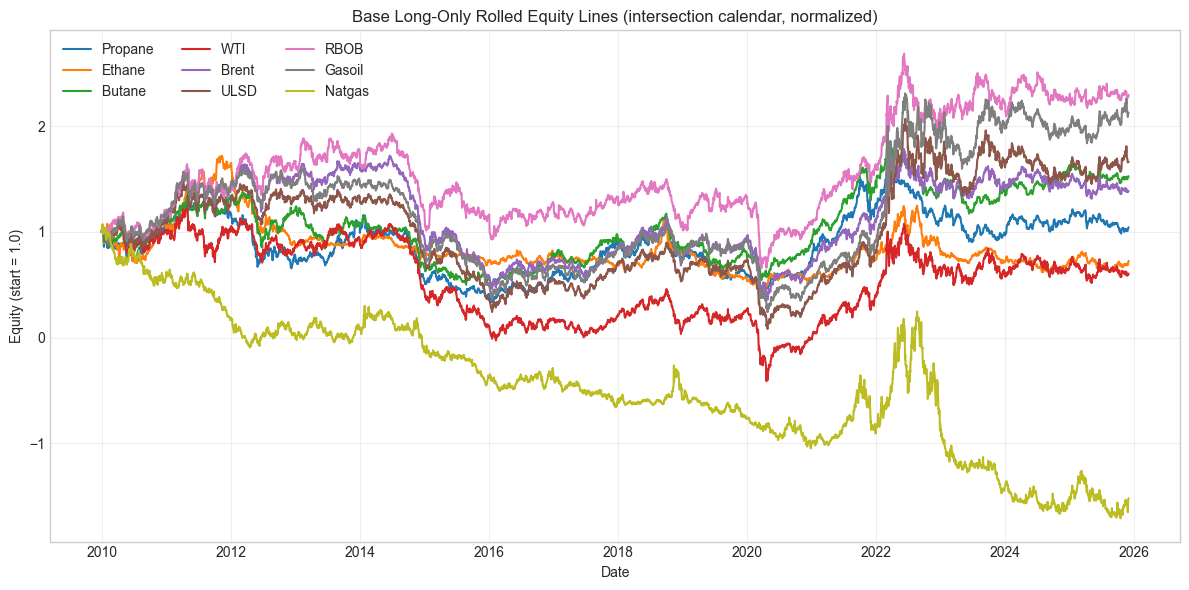

In [30]:
# ==============================================================
# Base long-only rolls (net t-cost) on INTERSECTION calendar
# - build per-commodity rolled equity_line
# - intersect all calendars (common trading days)
# - compute log returns from equity_line (safe for -1.0 floor)
# - build equity_index by compounding (not log-space)
# - compute simple, transparent metrics (no external metrics())
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

START_DATE = "2010-01-01"
TRADING_DAYS = 252

BASE_ROLL_STYLES = {
    "Propane": {"style": "eom_ngl",     "mid_col": "F3", "far_col": "F4"},
    "Ethane":  {"style": "eom_ngl",     "mid_col": "F3", "far_col": "F4"},
    "Butane":  {"style": "eom_ngl",     "mid_col": "F3", "far_col": "F4"},
    "WTI":     {"style": "eom_mid",     "front_col": "F1", "next_col": "F2"},
    "Brent":   {"style": "eom_dynamic", "front_col": "F1", "next_col": "F2", "third_col": "F3"},
    "ULSD":    {"style": "eom_eom",     "next_col": "F2", "third_col": "F3"},
    "RBOB":    {"style": "eom_eom",     "next_col": "F2", "third_col": "F3"},
    "Gasoil":  {"style": "eom_mid",     "front_col": "F1", "next_col": "F2"},
    "Natgas":  {"style": "eom_mid",     "front_col": "F1", "next_col": "F2"},
}

def _safe_log_returns_from_equity_line(equity_line: pd.Series) -> pd.Series:
    """
    equity_line is cumulative PnL-like (can be negative).
    Convert to *log returns* via simple-return compounding:
      r_t = (E_t - E_{t-1}) / |E_{t-1}|
      logret_t = log(1 + r_t)
    This is well-defined as long as r_t > -1 and E_{t-1} != 0.
    """
    e = equity_line.astype(float)
    prev = e.shift(1)

    # simple return on absolute prior level
    r = (e - prev) / prev.abs()

    # avoid division by 0 and log of non-positive
    r = r.where(prev.abs() > 0)
    logret = np.log1p(r.where(r > -1))
    return logret.fillna(0.0)

def simple_metrics(logret: pd.Series, trading_days: int = TRADING_DAYS) -> dict:
    """
    Annualized metrics from daily log returns (arithmetic mean of log returns).
      AnnReturn = 252 * mean(logret)
      AnnVol    = sqrt(252) * std(logret)
      Sharpe    = AnnReturn / AnnVol
    """
    x = logret.dropna()
    if x.empty:
        return {"AnnReturn": np.nan, "AnnVol": np.nan, "Sharpe": np.nan}

    ann_ret = x.mean() * trading_days
    ann_vol = x.std(ddof=0) * np.sqrt(trading_days)
    sharpe = np.nan if ann_vol == 0 else ann_ret / ann_vol

    return {"AnnReturn": ann_ret, "AnnVol": ann_vol, "Sharpe": sharpe}

ALL_LONG_ROLL = {}

# ---------- 1) Build rolled equity_line per commodity ----------
for commodity, cfg in BASE_ROLL_STYLES.items():
    if commodity not in COMMODITIES:
        raise KeyError(f"{commodity} missing in COMMODITIES.")

    ticker, contracts, units, t_cost = COMMODITIES[commodity]

    prices = load_prices(commodity, ticker).loc[START_DATE:].sort_index()
    expiry_cal = load_expiry(ticker)

    rs = RollingStrategy(
        prices=prices,
        expiry_calendar=expiry_cal,
        front_col=cfg.get("front_col", "F1"),
        next_col=cfg.get("next_col", "F2"),
    )

    style = cfg["style"]
    if style == "eom_ngl":
        eq_df = rs.equity(
            style="eom_ngl",
            t_cost=t_cost,
            mid_col=cfg.get("mid_col", "F3"),
            far_col=cfg.get("far_col", "F4"),
        )
    elif style == "eom_mid":
        eq_df = rs.equity(style="eom_mid", t_cost=t_cost)
    elif style == "eom_dynamic":
        eq_df = rs.equity(style="eom_dynamic", t_cost=t_cost, third_col=cfg.get("third_col", "F3"))
    elif style == "eom_eom":
        eq_df = rs.equity(style="eom_eom", t_cost=t_cost, third_col=cfg.get("third_col", "F3"))
    else:
        raise ValueError(f"Unknown style '{style}' for {commodity}")

    eq_df = eq_df.loc[START_DATE:].sort_index().copy()
    if "equity_line" not in eq_df.columns:
        raise ValueError(f"'equity_line' missing for {commodity}")

    eq_df["commodity"] = commodity
    eq_df["ticker"] = ticker
    eq_df["contracts"] = contracts
    eq_df["units"] = units
    eq_df["t_cost_param"] = t_cost
    eq_df["style"] = style

    ALL_LONG_ROLL[commodity] = eq_df

# ---------- 2) Force INTERSECTION calendar ----------
common_idx = None
for df in ALL_LONG_ROLL.values():
    common_idx = df.index if common_idx is None else common_idx.intersection(df.index)
common_idx = common_idx.sort_values()

for c in list(ALL_LONG_ROLL.keys()):
    ALL_LONG_ROLL[c] = ALL_LONG_ROLL[c].loc[common_idx].copy()

# ---------- 3) Returns + equity index (no start capital) ----------
for c, df in ALL_LONG_ROLL.items():
    df["log_ret"] = _safe_log_returns_from_equity_line(df["equity_line"])

    # equity_index via compounding log returns (always positive by construction)
    df["equity_index"] = np.exp(df["log_ret"].cumsum())

# ---------- 4) Metrics (transparent, comparable) ----------
rows = []
for c, df in ALL_LONG_ROLL.items():
    m = simple_metrics(df["log_ret"])
    rows.append({
        "commodity": c,
        "style": df["style"].iloc[0],
        "AnnReturn": m["AnnReturn"],
        "AnnVol": m["AnnVol"],
        "Sharpe": m["Sharpe"],
        "Start": df.index.min(),
        "End": df.index.max(),
        "N": int(df["log_ret"].notna().sum()),
    })

LONG_ROLL_METRICS = pd.DataFrame(rows).set_index("commodity")
display(LONG_ROLL_METRICS)

# ---------- 5) Plots ----------
plt.figure(figsize=(12, 6))
for c, df in ALL_LONG_ROLL.items():
    base = df["equity_line"].iloc[0]
    denom = base if base != 0 else 1.0  # avoid divide-by-zero
    plt.plot(df.index, df["equity_line"] / denom, label=c)
plt.title("Base Long-Only Rolled Equity Lines (intersection calendar, normalized)")
plt.xlabel("Date")
plt.ylabel("Equity (start = 1.0)")
plt.grid(alpha=0.3)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()


In [31]:
# ============================================================
# Export to Excel: log_ret (0-filled) + equity_index + metrics
# ============================================================

OUTPUT_XLSX = "base_long_roll_log_returns.xlsx"

logret_df = (
    pd.concat({c: df["log_ret"].astype(float) for c, df in ALL_LONG_ROLL.items()}, axis=1)
    .sort_index()
    .fillna(0.0)
)
logret_df.index.name = "Date"

eqidx_df = (
    pd.concat({c: df["equity_index"].astype(float) for c, df in ALL_LONG_ROLL.items()}, axis=1)
    .sort_index()
)
eqidx_df.index.name = "Date"

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    logret_df.to_excel(writer, sheet_name="Log_Returns")
    eqidx_df.to_excel(writer, sheet_name="Equity_Index")
    LONG_ROLL_METRICS.to_excel(writer, sheet_name="Metrics")

print(f"Wrote: {OUTPUT_XLSX}")


Wrote: base_long_roll_log_returns.xlsx


## Momentum

### MA Average

In [ ]:
# =====================================================================
# MOMENTUM (MA-Mix) — FULL-HISTORY WARMUP + TRADE START 2015-01-01
# STRICT intersection calendar + GLOBAL K + NO fillna(0)
# Outputs:
#   - ALL_MOM_LEGS: per-commodity df with ['equity_line','log_ret','equity_index'] on strict calendar
#   - NGL / SixPack / EW-All9 portfolio returns + time-split stats
# =====================================================================

import numpy as np
import pandas as pd

HIST_START  = pd.Timestamp("2010-01-01")   # warmup start (signals form here)
TRADE_START = pd.Timestamp("2015-01-01")   # trading / evaluation start
TRADING_DAYS = 252

MA_PAIRS   = [(1, 5), (5, 20), (10, 60)]
MA_WEIGHTS = None

NGL_NAMES = ["Propane", "Ethane", "Butane"]
SIX_PACK  = ["WTI", "Brent", "ULSD", "RBOB", "Natgas", "Gasoil"]
ALL_NAMES = sorted(set(NGL_NAMES + SIX_PACK))

SUB_PERIODS = {
    "Full Sample": (None, None),
    "2015-2022":   (pd.Timestamp("2015-01-01"), pd.Timestamp("2021-12-31")),
    "2022-2025":   (pd.Timestamp("2022-01-01"), None),
}

corr_order = [
    "WTI",
    "Brent",
    "ULSD",
    "RBOB",
    "Gasoil",
    "Natgas",
    "Propane",
    "Ethane",
    "Butane",
]


# ---------- helpers ----------
def ann_stats_from_logret(lr: pd.Series):
    lr = lr.replace([np.inf, -np.inf], np.nan).dropna()
    if len(lr) < 2:
        return np.nan, np.nan, np.nan
    ann_ret = lr.mean() * TRADING_DAYS
    ann_vol = lr.std(ddof=0) * np.sqrt(TRADING_DAYS)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    return ann_ret, ann_vol, sharpe

def time_split_metrics_from_ports(ports, sub_periods, trading_days=252):
    """
    ports: list of dicts with keys: ['name','log_ret'] where log_ret is a pd.Series of daily log returns
    Returns a DataFrame with MultiIndex columns: (Sample, Metric)
    """
    metric_labels = ["Ann_Return", "Ann_Vol", "Sharpe", "Max_DD"]
    cols = pd.MultiIndex.from_product([list(sub_periods.keys()), metric_labels],
                                      names=["Sample", "Metric"])
    out = pd.DataFrame(index=[p["name"] for p in ports], columns=cols, dtype=float)

    for p in ports:
        lr = p["log_ret"].astype(float).replace([np.inf, -np.inf], np.nan)

        for per_label, (start, end) in sub_periods.items():
            sub = lr.copy()
            if start is not None:
                sub = sub.loc[sub.index >= start]
            if end is not None:
                sub = sub.loc[sub.index <= end]
            sub = sub.dropna()

            if len(sub) < 2:
                ann_ret = ann_vol = sharpe = max_dd = np.nan
            else:
                ann_ret = sub.mean() * trading_days
                ann_vol = sub.std(ddof=0) * np.sqrt(trading_days)
                sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan

                eq = np.exp(sub.cumsum())
                eq = eq / eq.iloc[0]
                dd = eq / eq.cummax() - 1.0
                max_dd = float(dd.min()) if len(dd) else np.nan

            out.loc[p["name"], (per_label, "Ann_Return")] = ann_ret
            out.loc[p["name"], (per_label, "Ann_Vol")]    = ann_vol
            out.loc[p["name"], (per_label, "Sharpe")]     = sharpe

    return out


def slice_period(s: pd.Series, start=None, end=None):
    if start is not None:
        s = s.loc[s.index >= start]
    if end is not None:
        s = s.loc[s.index <= end]
    return s


def _extract_equity_line(df: pd.DataFrame) -> pd.Series:
    if df is None or df.empty:
        return pd.Series(dtype=float)
    if "equity_line" in df.columns:
        return df["equity_line"].astype(float)
    if "net_pnl" in df.columns:
        return df["net_pnl"].astype(float).cumsum()
    return pd.Series(dtype=float)


def apply_global_K_and_logret_strict(leg_dict: dict, tag: str):
    """
    leg_dict: {name: DataFrame with 'equity_line'} (already trade-windowed)
    Enforces: strict intersection calendar across ALL legs.
    Computes: global K on that intersection, then log_ret + equity_index.
    STRICT: drop first NaN from diff() AND re-intersect again.
    """
    if not leg_dict:
        raise ValueError(f"[{tag}] empty dict.")

    common_idx = None
    for df in leg_dict.values():
        idx = df.index.dropna()
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    common_idx = common_idx.sort_values()

    if len(common_idx) < 2:
        raise ValueError(f"[{tag}] common_idx too short after intersection.")

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx].copy()

    global_min = min(float(df["equity_line"].min()) for df in leg_dict.values())
    K = 1.10 * (-global_min) if global_min < 0 else 1.0

    print(f"[{tag}] intersection: {common_idx.min().date()} → {common_idx.max().date()} (n={len(common_idx):,})")
    print(f"[{tag}] global min equity_line: {global_min:,.6f}")
    print(f"[{tag}] shift K: {K:,.6f}")

    for name, df in leg_dict.items():
        w = df["equity_line"].astype(float) + K
        if (w <= 0).any():
            raise ValueError(f"[{tag}] {name}: wealth proxy <= 0 even after K")
        df["log_ret"] = np.log(w).diff()                 # <-- no fillna(0)
        df["equity_index"] = np.exp(df["log_ret"].cumsum())

    # strict: drop first diff NaN everywhere
    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].dropna(subset=["log_ret"])

    # strict: re-intersect after dropping first NaN
    common_idx2 = None
    for df in leg_dict.values():
        common_idx2 = df.index if common_idx2 is None else common_idx2.intersection(df.index)
    common_idx2 = common_idx2.sort_values()

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx2].copy()

    return leg_dict, K, common_idx2


def build_portfolio_strict(name: str, commodities: list[str], leg_dict: dict):
    cols = [c for c in commodities if c in leg_dict]
    if not cols:
        return None

    lr_df = pd.concat(
        {c: leg_dict[c]["log_ret"].astype(float) for c in cols},
        axis=1,
        join="inner",
    ).dropna(how="any").sort_index()

    if lr_df.shape[0] < 2:
        return None

    port_lr = lr_df.mean(axis=1)
    port_lr.name = name

    port_eq = np.exp(port_lr.cumsum())
    port_eq.name = name

    ann_ret, ann_vol, sharpe = ann_stats_from_logret(port_lr)

    eq_curve = port_eq / port_eq.iloc[0]
    dd = eq_curve / eq_curve.cummax() - 1.0
    max_dd = float(dd.min()) if len(dd) else np.nan

    return {
        "name": name,
        "log_ret": port_lr,
        "equity": port_eq,
        "Ann_Return": ann_ret,
        "Ann_Vol": ann_vol,
        "Ann_Sharpe": sharpe,
        "Max_DD": max_dd,
    }


# =====================================================================
# 1) Build momentum per commodity using FULL history (warmup)
#    then slice to TRADE_START for evaluation
# =====================================================================
ALL_MOM_LEGS = {}

for commodity, cfg in BASE_ROLL_STYLES.items():
    if commodity not in COMMODITIES:
        continue

    ticker, contracts, units, t_cost = COMMODITIES[commodity]

    prices_full = load_prices(commodity, ticker, normalize=True).loc[HIST_START:].sort_index()
    if prices_full.empty:
        continue

    expiry_cal = load_expiry(ticker)

    style     = cfg["style"]
    front_col = cfg.get("front_col", "F1")
    next_col  = cfg.get("next_col", "F2")

    rs = RollingStrategy(prices=prices_full, expiry_calendar=expiry_cal, front_col=front_col, next_col=next_col)

    if style == "eom_ngl":
        rolled_full = rs.equity(style="eom_ngl", t_cost=t_cost,
                                mid_col=cfg.get("mid_col", "F3"),
                                far_col=cfg.get("far_col", "F4"))
    elif style == "eom_mid":
        rolled_full = rs.equity(style="eom_mid", t_cost=t_cost)
    elif style == "eom_dynamic":
        rolled_full = rs.equity(style="eom_dynamic", t_cost=t_cost,
                                third_col=cfg.get("third_col", "F3"))
    elif style == "eom_eom":
        rolled_full = rs.equity(style="eom_eom", t_cost=t_cost,
                                third_col=cfg.get("third_col", "F3"))
    else:
        continue

    rolled_full = rolled_full.sort_index()

    mom_full = momentum(
        prices=prices_full,
        rolled_df=rolled_full,
        front_col=front_col,
        short_ma=1,
        long_ma=20,
        t_cost=t_cost,
        epsilon=0.0,
        ma_pairs=MA_PAIRS,
        weights=MA_WEIGHTS,
    )

    if mom_full is None or mom_full.empty:
        continue

    eq_full = _extract_equity_line(mom_full.sort_index())
    if eq_full.empty:
        continue

    # IMPORTANT: only after signal warmup do we slice to trade start
    eq_trade = eq_full.loc[eq_full.index >= TRADE_START].dropna()
    if len(eq_trade) < 3:
        continue

    ALL_MOM_LEGS[commodity] = pd.DataFrame({"equity_line": eq_trade.astype(float)})

if not ALL_MOM_LEGS:
    raise RuntimeError("ALL_MOM_LEGS is empty. No momentum series were built.")


# =====================================================================
# 2) STRICT intersection calendar + GLOBAL K + STRICT log_ret
# =====================================================================
ALL_MOM_LEGS, K, common_idx = apply_global_K_and_logret_strict(ALL_MOM_LEGS, tag="MOM_MAMIX")


# =====================================================================
# 3) Portfolios (NGL, SixPack, EW-All9)
# =====================================================================
ngl_port = build_portfolio_strict("NGL_Mom", NGL_NAMES, ALL_MOM_LEGS)
six_port = build_portfolio_strict("SixPack_Mom", SIX_PACK, ALL_MOM_LEGS)
all_port = build_portfolio_strict("EW_All9_Mom", ALL_NAMES, ALL_MOM_LEGS)

ports = [p for p in [ngl_port, six_port, all_port] if p is not None]
if len(ports) != 3:
    raise RuntimeError("One of the three momentum portfolios could not be built (overlap too small).")


# =====================================================================
# 4) Time-split stats (same format as your VAL/CARRY blocks)
# =====================================================================
mom_time_stats = time_split_metrics_from_ports(ports, sub_periods=SUB_PERIODS)
display(mom_time_stats.round(4))


# =====================================================================
# 5) Correlation matrix (strict overlap, strict order)
# =====================================================================
corr_names = [c for c in corr_order if c in ALL_MOM_LEGS]

logret_corr = pd.concat(
    {c: ALL_MOM_LEGS[c]["log_ret"].astype(float) for c in corr_names},
    axis=1,
    join="inner",
).dropna(how="any").sort_index()

corr_mat = logret_corr.corr().reindex(index=corr_names, columns=corr_names)
display(corr_mat.round(3))


[MOM_MAMIX] intersection: 2015-01-02 → 2025-12-01 (n=2,746)
[MOM_MAMIX] global min equity_line: -82.756800
[MOM_MAMIX] shift K: 91.032480


Sample      Full Sample                         2015-2022                  \
Metric       Ann_Return Ann_Vol  Sharpe Max_DD Ann_Return Ann_Vol  Sharpe   
NGL_Mom          0.0456  0.0463  0.9856    NaN     0.0607  0.0493  1.2305   
SixPack_Mom     -0.0160  0.1901 -0.0839    NaN    -0.0003  0.1847 -0.0019   
EW_All9_Mom      0.0046  0.1330  0.0343    NaN     0.0200  0.1295  0.1544   

Sample              2022-2025                         
Metric      Max_DD Ann_Return Ann_Vol  Sharpe Max_DD  
NGL_Mom        NaN     0.0186  0.0402  0.4624    NaN  
SixPack_Mom    NaN    -0.0439  0.1993 -0.2205    NaN  
EW_All9_Mom    NaN    -0.0231  0.1390 -0.1662    NaN

,WTI,Brent,ULSD,RBOB,Gasoil,Natgas,Propane,Ethane,Butane
WTI,1.000,0.770,0.507,0.446,0.412,0.044,0.270,0.051,0.248
Brent,0.770,1.000,0.522,0.417,0.435,0.073,0.281,0.064,0.231
ULSD,0.507,0.522,1.000,0.354,0.559,0.035,0.291,0.089,0.274
RBOB,0.446,0.417,0.354,1.000,0.312,0.020,0.211,0.056,0.186
Gasoil,0.412,0.435,0.559,0.312,1.000,0.039,0.209,0.089,0.211
Natgas,0.044,0.073,0.035,0.020,0.039,1.000,0.043,0.288,0.043
Propane,0.270,0.281,0.291,0.211,0.209,0.043,1.000,0.147,0.704
Ethane,0.051,0.064,0.089,0.056,0.089,0.288,0.147,1.000,0.119
Butane,0.248,0.231,0.274,0.186,0.211,0.043,0.704,0.119,1.000


## Carry

Built carry strategies for 9 commodities.
[CAR] global min equity_line on common calendar: -67.090800
[CAR] using shift K: 73.799880


,Asset,Period,Strategy,Return,Vol,Sharpe
0,Propane,Full Sample,CAR,0.020915,0.067252,0.310990
1,Propane,2015-2022,CAR,0.051753,0.068763,0.752641
2,Propane,2022-2025,CAR,-0.034394,0.064307,-0.534843
3,Ethane,Full Sample,CAR,0.009212,0.057973,0.158904
4,Ethane,2015-2022,CAR,0.015258,0.051859,0.294212


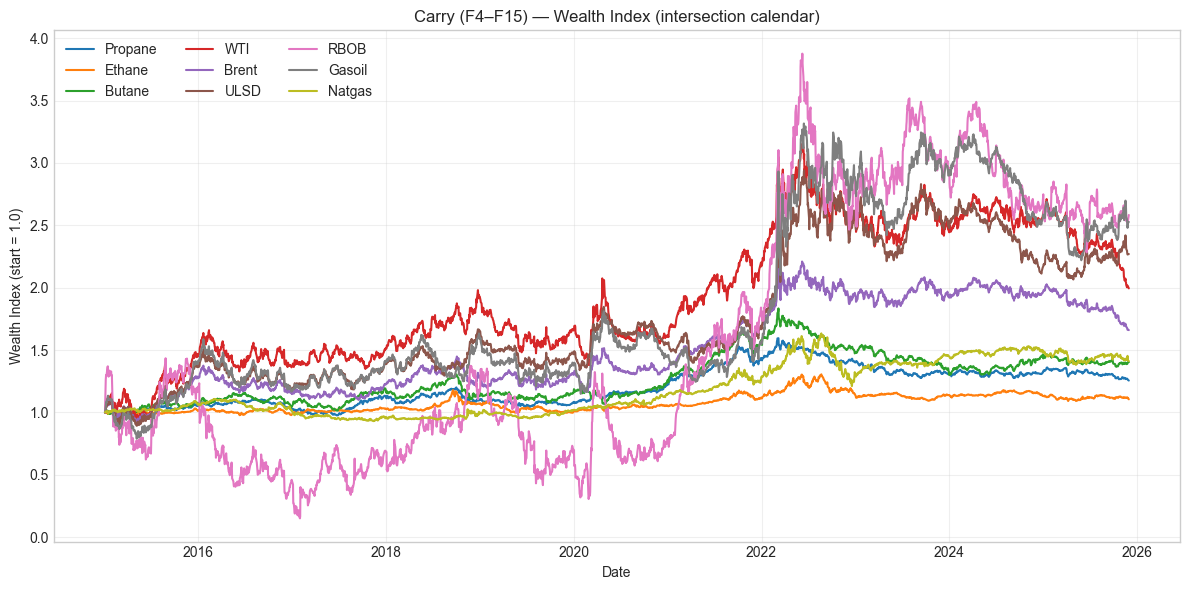

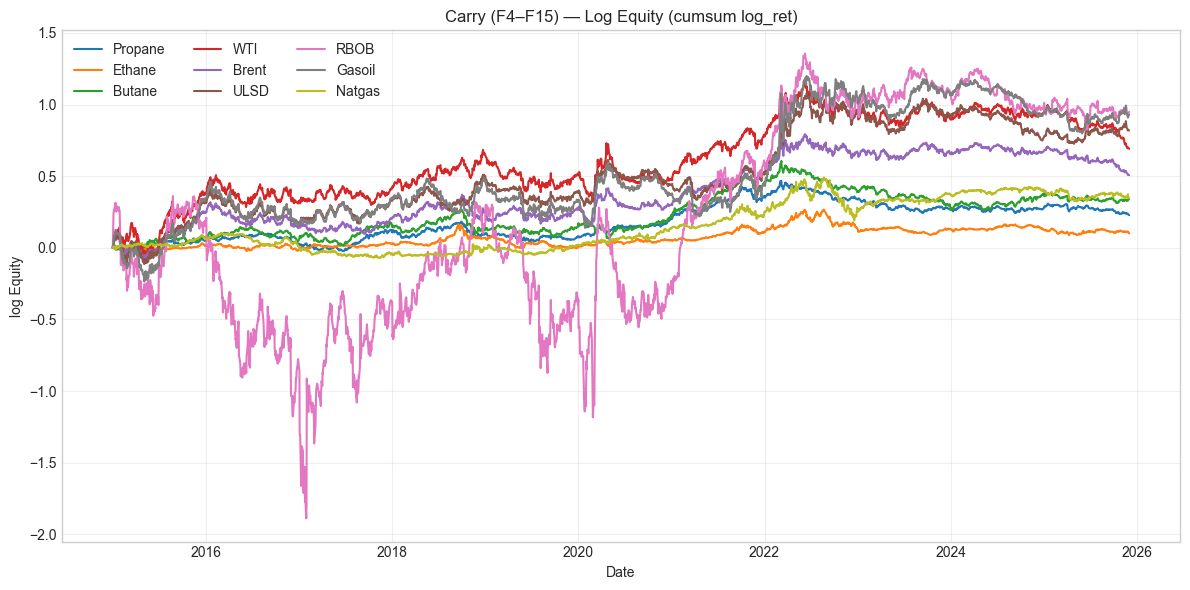

In [ ]:
# =====================================================================
# CARRY (CAR) — F4 vs F15 (warmup + intersection + wealth-proxy log_ret)
# Produces:
#   - ALL_CARRY  (per-commodity dfs, TRADE window only, common calendar)
#   - stats_carry (Asset, Period, Strategy, Return, Vol, Sharpe) with Return=CAGR
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CARRY_FRONT_COL = "F4"
CARRY_END_COL   = "F15"

HIST_START  = "2010-01-01"
TRADE_START = START_DATE  # e.g. "2015-01-01"
TRADING_DAYS = 252

SUB_PERIODS = {
    "Full Sample": (None, None),
    "2015-2022":  (pd.Timestamp("2015-01-01"), pd.Timestamp("2021-12-31")),
    "2022-2025":  (pd.Timestamp("2022-01-01"), None),
}

def slice_period(s: pd.Series, start, end):
    if start is not None:
        s = s.loc[s.index >= start]
    if end is not None:
        s = s.loc[s.index <= end]
    return s

def basic_stats_log(logret: pd.Series):
    logret = logret.dropna()
    if logret.empty:
        return np.nan, np.nan, np.nan

    ann_log_mean = logret.mean() * TRADING_DAYS
    ann_vol      = logret.std(ddof=0) * np.sqrt(TRADING_DAYS)
    sharpe       = np.nan if ann_vol == 0 else ann_log_mean / ann_vol

    return ann_log_mean, ann_vol, sharpe

ALL_CARRY = {}

# -------------------------
# 1) Build carry per commodity on FULL history (warmup)
# -------------------------
for commodity, cfg in BASE_ROLL_STYLES.items():
    if commodity not in COMMODITIES:
        raise KeyError(f"{commodity} missing in COMMODITIES.")

    ticker, contracts, units, t_cost = COMMODITIES[commodity]

    prices_full = load_prices(commodity, ticker, normalize=True).loc[HIST_START:].sort_index()
    expiry_cal  = load_expiry(ticker)

    # require F4/F15 for carry signal
    missing = [col for col in (CARRY_FRONT_COL, CARRY_END_COL) if col not in prices_full.columns]
    if missing:
        print(f"[SKIP] {commodity}: missing {missing}")
        continue

    style     = cfg["style"]
    front_col = cfg.get("front_col", "F1")
    next_col  = cfg.get("next_col", "F2")

    # base long-roll df (for costs / roll flags / etc. as your carry() expects)
    rs = RollingStrategy(
        prices=prices_full,
        expiry_calendar=expiry_cal,
        front_col=front_col,
        next_col=next_col,
    )

    if style == "eom_ngl":
        rolled_full = rs.equity(style="eom_ngl", t_cost=t_cost,
                                mid_col=cfg.get("mid_col", "F3"),
                                far_col=cfg.get("far_col", "F4"))
    elif style == "eom_mid":
        rolled_full = rs.equity(style="eom_mid", t_cost=t_cost)
    elif style == "eom_dynamic":
        rolled_full = rs.equity(style="eom_dynamic", t_cost=t_cost,
                                third_col=cfg.get("third_col", "F3"))
    elif style == "eom_eom":
        rolled_full = rs.equity(style="eom_eom", t_cost=t_cost,
                                third_col=cfg.get("third_col", "F3"))
    else:
        raise ValueError(f"Unknown style '{style}' for {commodity}")

    rolled_full = rolled_full.sort_index()

    # run carry on FULL history (warmup included)
    carry_full = carry(
        prices=prices_full,
        rolled_df=rolled_full,
        front_col=CARRY_FRONT_COL,
        end_col=CARRY_END_COL,
        t_cost=t_cost,
        epsilon=0.0,
    )

    if carry_full is None or carry_full.empty:
        print(f"[SKIP] {commodity}: carry_full empty")
        continue

    carry_full = carry_full.sort_index()

    # ensure equity_line exists (cum net_pnl)
    if "equity_line" not in carry_full.columns:
        if "net_pnl" not in carry_full.columns:
            raise ValueError(f"{commodity}: carry() missing 'equity_line' and 'net_pnl'")
        carry_full["equity_line"] = carry_full["net_pnl"].cumsum()

    # trade window slice
    carry_df = carry_full.loc[TRADE_START:].copy()
    if carry_df.empty:
        print(f"[SKIP] {commodity}: no carry data after TRADE_START")
        continue

    # tag
    carry_df["commodity"] = commodity
    carry_df["ticker"]    = ticker
    carry_df["style"]     = f"carry_{CARRY_FRONT_COL}_{CARRY_END_COL}"

    ALL_CARRY[commodity] = carry_df

print(f"Built carry strategies for {len(ALL_CARRY)} commodities.")

# -------------------------
# 2) Intersection calendar (trade window only)
# -------------------------
common_idx = None
for df in ALL_CARRY.values():
    common_idx = df.index if common_idx is None else common_idx.intersection(df.index)
common_idx = common_idx.sort_values()

for c in list(ALL_CARRY.keys()):
    ALL_CARRY[c] = ALL_CARRY[c].loc[common_idx].copy()

# -------------------------
# 3) Wealth-proxy log returns (global shift K)
# -------------------------
global_min = min(df["equity_line"].min() for df in ALL_CARRY.values())
K = 1.10 * (-global_min) if global_min < 0 else 1.0

print(f"[CAR] global min equity_line on common calendar: {global_min:,.6f}")
print(f"[CAR] using shift K: {K:,.6f}")

for c, df in ALL_CARRY.items():
    e = df["equity_line"].astype(float)
    w = e + K
    if (w <= 0).any():
        raise ValueError(f"{c}: wealth proxy <= 0 even after K; increase buffer")

    df["log_ret"] = np.log(w / w.shift(1)).fillna(0.0)
    df["equity_index"] = np.exp(df["log_ret"].cumsum())
    df["log_equity_norm"] = df["log_ret"].cumsum()

# -------------------------
# 4) CAR stats by sub-periods (LOG; Return=CAGR)
# -------------------------
rows_carry = []

for commodity, df in ALL_CARRY.items():
    logret = df["log_ret"]

    for period_name, (start, end) in SUB_PERIODS.items():
        sub = slice_period(logret, start, end)
        ann_ret, ann_vol, sharpe = basic_stats_log(sub)

        rows_carry.append({
            "Asset":    commodity,
            "Period":   period_name,
            "Strategy": "CAR",
            "Return":   ann_ret,
            "Vol":      ann_vol,
            "Sharpe":   sharpe,
        })

# EW CAR portfolio (LOG)
logret_matrix_carry = pd.concat({c: df["log_ret"] for c, df in ALL_CARRY.items()}, axis=1).sort_index()
ew_carry_logret = logret_matrix_carry.mean(axis=1)

for period_name, (start, end) in SUB_PERIODS.items():
    sub = slice_period(ew_carry_logret, start, end)
    ann_ret, ann_vol, sharpe = basic_stats_log(sub)

    rows_carry.append({
        "Asset":    "EW PORT",
        "Period":   period_name,
        "Strategy": "CAR",
        "Return":   ann_ret,
        "Vol":      ann_vol,
        "Sharpe":   sharpe,
    })

stats_carry = pd.DataFrame(rows_carry)
display(stats_carry.head())

# -------------------------
# 5) Plots (optional, VAL-style)
# -------------------------
plt.figure(figsize=(12, 6))
for c, df in ALL_CARRY.items():
    plt.plot(df.index, df["equity_index"], label=c)
plt.title(f"Carry ({CARRY_FRONT_COL}–{CARRY_END_COL}) — Wealth Index (intersection calendar)")
plt.xlabel("Date")
plt.ylabel("Wealth Index (start = 1.0)")
plt.grid(alpha=0.3)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for c, df in ALL_CARRY.items():
    plt.plot(df.index, df["log_equity_norm"], label=c)
plt.title(f"Carry ({CARRY_FRONT_COL}–{CARRY_END_COL}) — Log Equity (cumsum log_ret)")
plt.xlabel("Date")
plt.ylabel("log Equity")
plt.grid(alpha=0.3)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()


## Value
- 5 year MA
- 2% threshold

Built value strategies for 9 commodities.
[VAL] global min equity_line on common calendar: -65.268456
[VAL] using shift K: 71.795302


,Asset,Period,Strategy,Return,Vol,Sharpe
0,Propane,Full Sample,VAL,0.035504,0.124654,0.284819
1,Propane,2015-2022,VAL,0.044276,0.121671,0.363902
2,Propane,2022-2025,VAL,0.019771,0.129827,0.152284
3,Ethane,Full Sample,VAL,0.002888,0.047563,0.060729
4,Ethane,2015-2022,VAL,0.008218,0.038310,0.214514


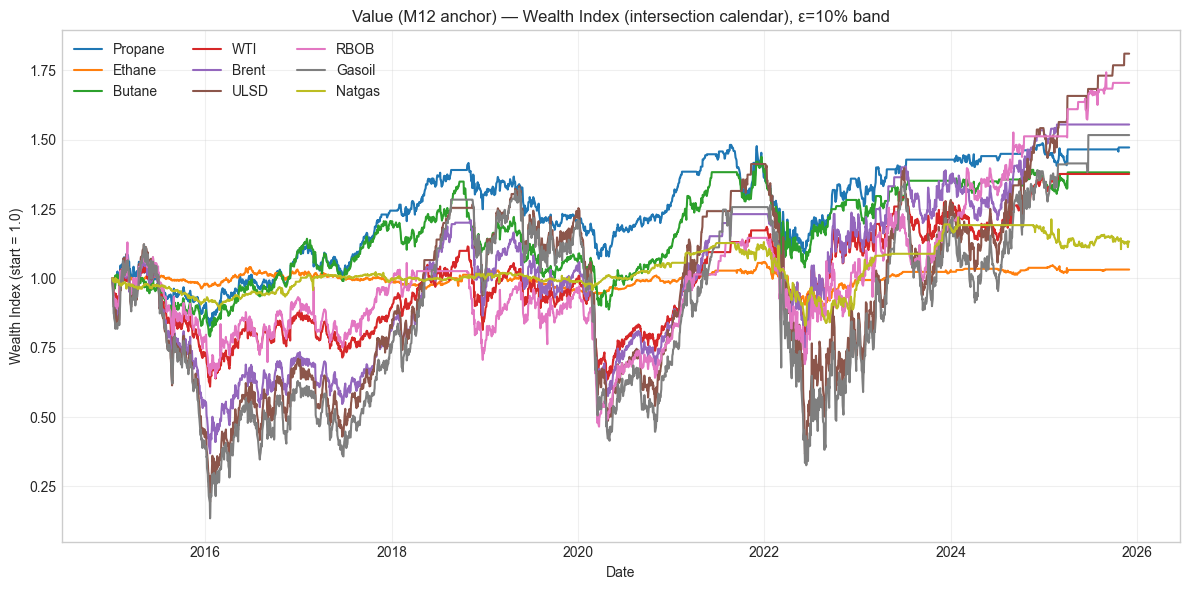

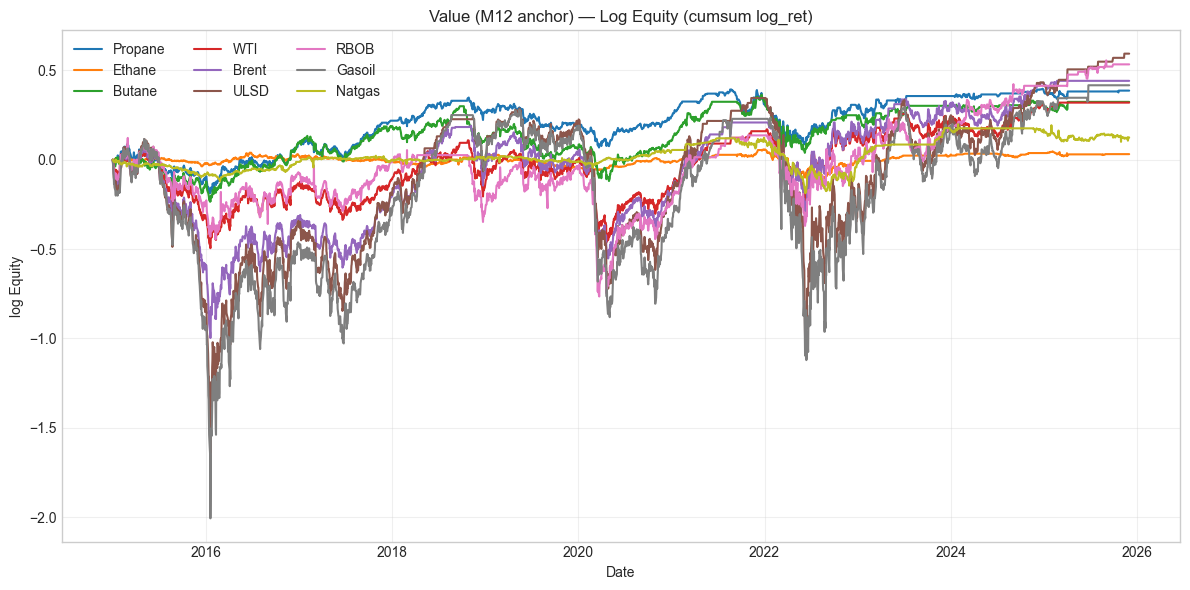

In [ ]:


VALUE_MA_WINDOW   = 252 * 10     # ~10y mean
VALUE_VOL_WINDOW  = 252          # kept for signature compat
VALUE_EPS_BAND    = 0.10         # 10% deviation band

HIST_START  = "2010-01-01"
TRADE_START = START_DATE         # e.g. "2015-01-01"
TRADING_DAYS = 252

SUB_PERIODS = {
    "Full Sample": (None, None),
    "2015-2022":  (pd.Timestamp("2015-01-01"), pd.Timestamp("2021-12-31")),
    "2022-2025":  (pd.Timestamp("2022-01-01"), None),
}

def slice_period(s: pd.Series, start, end):
    if start is not None:
        s = s.loc[s.index >= start]
    if end is not None:
        s = s.loc[s.index <= end]
    return s

def basic_stats_log(logret: pd.Series):
    logret = logret.dropna()
    if logret.empty:
        return np.nan, np.nan, np.nan

    ann_log_mean = logret.mean() * TRADING_DAYS
    ann_vol      = logret.std(ddof=0) * np.sqrt(TRADING_DAYS)
    sharpe       = np.nan if ann_vol == 0 else ann_log_mean / ann_vol

    return ann_log_mean, ann_vol, sharpe


ALL_VALUE = {}

# -------------------------
# 1) Build VALUE per commodity on FULL history (warmup)
# -------------------------
for commodity, cfg in BASE_ROLL_STYLES.items():
    if commodity not in COMMODITIES:
        raise KeyError(f"{commodity} missing in COMMODITIES.")

    ticker, contracts, units, t_cost = COMMODITIES[commodity]

    prices_full = load_prices(commodity, ticker, normalize=True).loc[HIST_START:].sort_index()
    expiry_cal  = load_expiry(ticker)
    cols = prices_full.columns

    # strict M12 anchor required
    if "F12" not in cols:
        print(f"[SKIP] {commodity}: missing F12 anchor.")
        continue

    # ------------------------------------------------------
    # FORCE long roll attempt (prefer F12/F13, fall back safe)
    # ------------------------------------------------------
    if ("F12" in cols) and ("F13" in cols):
        roll_front, roll_next = "F12", "F13"
        style_tag = "M12-M13_EOM"
    else:
        roll_front, roll_next = "F12", "F12"
        style_tag = "F12_only_EOM"

    rs = RollingStrategy(
        prices=prices_full,
        expiry_calendar=expiry_cal,
        front_col=roll_front,
        next_col=roll_next,
    )

    # uniform EOM-mid logic on forced long tenors
    rolled_full = rs.equity(style="eom_mid", t_cost=t_cost).sort_index()

    # build anchor series in prices_full
    prices_full = prices_full.copy()
    prices_full["VAL_ANCHOR"] = prices_full["F12"].astype(float)

    # run VALUE on FULL history (warmup included)
    val_full = value(
        prices=prices_full,
        rolled_df=rolled_full,
        front_col="VAL_ANCHOR",
        long_ma=VALUE_MA_WINDOW,
        vol_window=VALUE_VOL_WINDOW,
        epsilon_factor=VALUE_EPS_BAND,
        t_cost=t_cost,
    )

    if val_full is None or val_full.empty:
        print(f"[SKIP] {commodity}: val_full empty.")
        continue

    val_full = val_full.sort_index()

    # need net_pnl from value()
    if "net_pnl" not in val_full.columns:
        raise ValueError(f"{commodity}: value() output missing 'net_pnl'")

    # ensure equity_line exists (cum net_pnl)
    if "equity_line" not in val_full.columns:
        val_full["equity_line"] = val_full["net_pnl"].cumsum()

    # trade window slice
    val_df = val_full.loc[TRADE_START:].copy()
    if val_df.empty:
        print(f"[SKIP] {commodity}: no value data after TRADE_START.")
        continue

    # tag
    val_df["commodity"]  = commodity
    val_df["ticker"]     = ticker
    val_df["style"]      = style_tag
    val_df["ma_window"]  = VALUE_MA_WINDOW
    val_df["vol_window"] = VALUE_VOL_WINDOW
    val_df["eps_band"]   = VALUE_EPS_BAND

    ALL_VALUE[commodity] = val_df

print(f"Built value strategies for {len(ALL_VALUE)} commodities.")

# -------------------------
# 2) Intersection calendar (trade window only)
# -------------------------
common_idx = None
for df in ALL_VALUE.values():
    common_idx = df.index if common_idx is None else common_idx.intersection(df.index)
common_idx = common_idx.sort_values()

for c in list(ALL_VALUE.keys()):
    ALL_VALUE[c] = ALL_VALUE[c].loc[common_idx].copy()

# -------------------------
# 3) Wealth-proxy log returns (global shift K)
# -------------------------
global_min = min(df["equity_line"].min() for df in ALL_VALUE.values())
K = 1.10 * (-global_min) if global_min < 0 else 1.0

print(f"[VAL] global min equity_line on common calendar: {global_min:,.6f}")
print(f"[VAL] using shift K: {K:,.6f}")

for c, df in ALL_VALUE.items():
    e = df["equity_line"].astype(float)
    w = e + K
    if (w <= 0).any():
        raise ValueError(f"{c}: wealth proxy <= 0 even after K; increase buffer")

    df["log_ret"] = np.log(w / w.shift(1)).fillna(0.0)
    df["equity_index"] = np.exp(df["log_ret"].cumsum())
    df["log_equity_norm"] = df["log_ret"].cumsum()

# -------------------------
# 4) VAL stats by sub-periods (LOG; Return=CAGR) + EW portfolio
# -------------------------
rows_val = []

for commodity, df in ALL_VALUE.items():
    logret = df["log_ret"]

    for period_name, (start, end) in SUB_PERIODS.items():
        sub = slice_period(logret, start, end)
        ann_ret, ann_vol, sharpe = basic_stats_log(sub)

        rows_val.append({
            "Asset":    commodity,
            "Period":   period_name,
            "Strategy": "VAL",
            "Return":   ann_ret,
            "Vol":      ann_vol,
            "Sharpe":   sharpe,
        })

# EW VAL portfolio
logret_matrix_val = pd.concat({c: df["log_ret"] for c, df in ALL_VALUE.items()}, axis=1).sort_index()
ew_val_logret = logret_matrix_val.mean(axis=1)

for period_name, (start, end) in SUB_PERIODS.items():
    sub = slice_period(ew_val_logret, start, end)
    ann_ret, ann_vol, sharpe = basic_stats_log(sub)

    rows_val.append({
        "Asset":    "EW PORT",
        "Period":   period_name,
        "Strategy": "VAL",
        "Return":   ann_ret,
        "Vol":      ann_vol,
        "Sharpe":   sharpe,
    })

stats_val = pd.DataFrame(rows_val)
display(stats_val.head())

# -------------------------
# 5) Plots (VAL-style)
# -------------------------
plt.figure(figsize=(12, 6))
for c, df in ALL_VALUE.items():
    plt.plot(df.index, df["equity_index"], label=c)
plt.title(f"Value (M12 anchor) — Wealth Index (intersection calendar), ε={VALUE_EPS_BAND*100:.0f}% band")
plt.xlabel("Date")
plt.ylabel("Wealth Index (start = 1.0)")
plt.grid(alpha=0.3)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for c, df in ALL_VALUE.items():
    plt.plot(df.index, df["log_equity_norm"], label=c)
plt.title("Value (M12 anchor) — Log Equity (cumsum log_ret)")
plt.xlabel("Date")
plt.ylabel("log Equity")
plt.grid(alpha=0.3)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()


### Write Excel

In [ ]:
# =====================================================================
# VALUE STRATEGY (VAL) — M12 anchor (M12-M13 long roll attempt)
# + LOG-RETURN stats (CAGR / Vol / Sharpe) by sub-periods
# + Write combined MOM + CAR + VAL table to Excel
#
# Assumes you already built:
#   - stats_long   (MOM)  with columns: Asset, Period, Strategy, Return, Vol, Sharpe
#   - stats_carry  (CAR)  with columns: Asset, Period, Strategy, Return, Vol, Sharpe
#     (both in LOG-return conventions: Return=CAGR from log mean)
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from energy.strategies.value import value
from energy.analytics.metrics import metrics

# -------------------------
# Params
# -------------------------
VALUE_MA_WINDOW   = 252 * 10       # ~10y mean
VALUE_VOL_WINDOW  = 252            # kept for signature compat (ignored in band)
VALUE_EPS_BAND    = 0.10           # 10% deviation band
INIT_CAPITAL      = 10_000_000

HIST_START        = "2010-01-01"
TRADE_START       = START_DATE     # e.g. "2015-01-01"

TRADING_DAYS = 252
SUB_PERIODS = {
    "Full Sample": (None, None),
    "2015-2022":  (pd.Timestamp("2015-01-01"), pd.Timestamp("2021-12-31")),
    "2022-2025":  (pd.Timestamp("2022-01-01"), None),
}

def slice_period(s: pd.Series, start, end):
    if start is not None:
        s = s.loc[s.index >= start]
    if end is not None:
        s = s.loc[s.index <= end]
    return s

def basic_stats_log(logret: pd.Series):
    logret = logret.dropna()
    if logret.empty:
        return np.nan, np.nan, np.nan

    ann_log_mean = logret.mean() * TRADING_DAYS
    ann_vol      = logret.std(ddof=0) * np.sqrt(TRADING_DAYS)
    sharpe       = np.nan if ann_vol == 0 else ann_log_mean / ann_vol

    return ann_log_mean, ann_vol, sharpe


# -------------------------
# Build VALUE per commodity
# -------------------------
ALL_VALUE         = {}
ALL_VALUE_METRICS = []

for commodity, cfg in BASE_ROLL_STYLES.items():
    if commodity not in COMMODITIES:
        raise KeyError(f"{commodity} missing in COMMODITIES.")

    ticker, contracts, units, t_cost = COMMODITIES[commodity]

    # --- load FULL history ---
    prices_full = load_prices(commodity, ticker, normalize=True)
    prices_full = prices_full.loc[HIST_START:].sort_index()
    expiry_cal  = load_expiry(ticker)
    cols = prices_full.columns

    # ======================================================
    # Try long roll on F12/F13 where possible (fallback safe)
    # ======================================================
    if ("F12" in cols) and ("F13" in cols):
        roll_front = "F12"
        roll_next  = "F13"
        style_tag  = "M12-M13_EOM"
    elif "F12" in cols:
        roll_front = "F12"
        roll_next  = "F12"
        style_tag  = "F12_only_EOM"
    elif "F13" in cols:
        roll_front = "F13"
        roll_next  = "F13"
        style_tag  = "F13_only_EOM"
    else:
        roll_front = cfg.get("front_col", "F1")
        roll_next  = cfg.get("next_col", "F2")
        style_tag  = f"FALLBACK_{roll_front}_{roll_next}_EOM"

    rs = RollingStrategy(
        prices=prices_full,
        expiry_calendar=expiry_cal,
        front_col=roll_front,
        next_col=roll_next,
    )

    # Use uniform EOM-mid logic on forced long tenors
    rolled_full = rs.equity(style="eom_mid", t_cost=t_cost).sort_index()

    # safety
    for col in ["daily_pnl", "t_cost", "roll_day_flag"]:
        if col not in rolled_full.columns:
            raise ValueError(f"'{col}' missing in rolled_df for {commodity}")

    # STRICT M12 anchor required
    if "F12" not in cols:
        print(f"[SKIP] {commodity}: missing F12 (value anchor).")
        continue

    # Anchor series = M12 level
    prices_full = prices_full.copy()
    prices_full["VAL_ANCHOR"] = prices_full["F12"].astype(float)

    # run VALUE on FULL history using VAL_ANCHOR
    val_full = value(
        prices=prices_full,
        rolled_df=rolled_full,
        front_col="VAL_ANCHOR",
        long_ma=VALUE_MA_WINDOW,
        vol_window=VALUE_VOL_WINDOW,
        epsilon_factor=VALUE_EPS_BAND,
        t_cost=t_cost,
    )

    if val_full is None or val_full.empty:
        print(f"[SKIP] {commodity}: val_full empty")
        continue

    # restrict to trading window
    val_df = val_full.loc[TRADE_START:].sort_index().copy()
    if val_df.empty:
        print(f"[SKIP] {commodity}: no value data after TRADE_START")
        continue

    # must have net_pnl
    if "net_pnl" not in val_df.columns:
        raise ValueError(f"value() output missing 'net_pnl' for {commodity}: {val_df.columns}")

    # ---------- Wrap into trading account ----------
    exposure = contracts * units

    val_df["pnl_usd"]         = val_df["net_pnl"] * exposure
    val_df["cum_pnl_usd"]     = val_df["pnl_usd"].cumsum()
    val_df["equity_account"]  = INIT_CAPITAL + val_df["cum_pnl_usd"]

    start_eq = val_df["equity_account"].iloc[0]
    val_df["equity_norm"] = val_df["equity_account"] / start_eq

    # log equity and daily log returns (fill first as 0 for convenience)
    val_df["log_equity_norm"] = np.log(val_df["equity_norm"].where(val_df["equity_norm"] > 0))
    val_df["log_ret"]         = val_df["log_equity_norm"].diff().fillna(0.0)

    # ---------- Tag + store ----------
    val_df["commodity"]  = commodity
    val_df["ticker"]     = ticker
    val_df["style"]      = style_tag
    val_df["ma_window"]  = VALUE_MA_WINDOW
    val_df["vol_window"] = VALUE_VOL_WINDOW
    val_df["eps_band"]   = VALUE_EPS_BAND

    ALL_VALUE[commodity] = val_df

    # ---------- Metrics (your existing function; keep for per-asset diagnostics) ----------
    m = metrics(val_df, contracts=contracts, units=units)
    if isinstance(m, pd.Series):
        m = m.to_dict()
    m["commodity"]  = commodity
    m["style"]      = style_tag
    m["ma_window"]  = VALUE_MA_WINDOW
    m["vol_window"] = VALUE_VOL_WINDOW
    m["eps_band"]   = VALUE_EPS_BAND
    ALL_VALUE_METRICS.append(m)

VALUE_METRICS = pd.DataFrame(ALL_VALUE_METRICS).set_index("commodity")
display(VALUE_METRICS)

# -------------------------
# VAL stats by sub-periods (LOG)
# -------------------------
rows_val = []

for commodity, df in ALL_VALUE.items():
    logret = df["log_equity_norm"].diff()  # daily log returns

    for period_name, (start, end) in SUB_PERIODS.items():
        sub = slice_period(logret, start, end)
        ann_ret, ann_vol, sharpe = basic_stats_log(sub)

        rows_val.append({
            "Asset":    commodity,
            "Period":   period_name,
            "Strategy": "VAL",
            "Return":   ann_ret,
            "Vol":      ann_vol,
            "Sharpe":   sharpe,
        })

# EW VAL portfolio (LOG)
logret_matrix_val = pd.concat(
    {c: df["log_equity_norm"].diff() for c, df in ALL_VALUE.items()},
    axis=1
).sort_index()

ew_val_logret = logret_matrix_val.mean(axis=1)

for period_name, (start, end) in SUB_PERIODS.items():
    sub = slice_period(ew_val_logret, start, end)
    ann_ret, ann_vol, sharpe = basic_stats_log(sub)

    rows_val.append({
        "Asset":    "EW PORT",
        "Period":   period_name,
        "Strategy": "VAL",
        "Return":   ann_ret,
        "Vol":      ann_vol,
        "Sharpe":   sharpe,
    })

stats_val = pd.DataFrame(rows_val)
display(stats_val.head())

# =====================================================================
# Combine MOM + CAR + VAL and write wide table to Excel
# =====================================================================

# Expect these to already exist:
#   stats_long  (MOM)
#   stats_carry (CAR)
# Now add:
stats_all = pd.concat([stats_long, stats_carry, stats_val], ignore_index=True)

assets      = sorted(stats_all["Asset"].unique())
METRIC_ROWS = ["Return", "Vol", "Sharpe"]
periods     = ["Full Sample", "2015-2022", "2022-2025"]
strategies  = ["MOM", "CAR", "VAL"]

idx  = pd.MultiIndex.from_product([assets, METRIC_ROWS], names=["Asset", "Metric"])
cols = pd.MultiIndex.from_product([periods, strategies], names=["Sample", "Strategy"])

table = pd.DataFrame(index=idx, columns=cols, dtype=float)

for _, r in stats_all.iterrows():
    asset    = r["Asset"]
    period   = r["Period"]
    strat    = r["Strategy"]

    table.loc[(asset, "Return"), (period, strat)] = r["Return"]
    table.loc[(asset, "Vol"),    (period, strat)] = r["Vol"]
    table.loc[(asset, "Sharpe"), (period, strat)] = r["Sharpe"]

out_path = "signal_stats_MOM_CAR_VAL.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    table.to_excel(writer, sheet_name="MOM_CAR_VAL")

print(f"Saved combined MOM + CAR + VAL stats to {out_path}")
display(table)

# =====================================================================
# Plots (VAL)
# =====================================================================

plt.figure(figsize=(12, 6))
for c, df in ALL_VALUE.items():
    plt.plot(df.index, df["equity_norm"], label=c)
plt.title(f"Value (M12 anchor) — Equity (net t-cost, normalized), ε={VALUE_EPS_BAND*100:.0f}% band")
plt.xlabel("Date")
plt.ylabel("Equity (start = 1.0)")
plt.grid(alpha=0.3)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for c, df in ALL_VALUE.items():
    plt.plot(df.index, df["log_equity_norm"], label=c)
plt.title("Value (M12 anchor) — Log Equity Curves (ln(E_t / E_0))")
plt.xlabel("Date")
plt.ylabel("log Equity")
plt.grid(alpha=0.3)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()


,Total PnL,Total Cost,APL/unit (ann.),CAGR,Std Dev (ann.),Sharpe,Drawdown,RoD,Years,style,ma_window,vol_window,eps_band
commodity,,,,,,,,,,,,,
Propane,"2,557,884.0000",-0.0000,2.3423,0.0213,8.0300,0.2917,-0.1708,13.7144,10.9205,M12-M13_EOM,2520,252,0.1000
Ethane,"217,938.0000",-0.0000,0.1996,0.0019,2.9912,0.0667,-0.0983,2.0292,10.9205,M12-M13_EOM,2520,252,0.1000
Butane,"2,254,896.0000",-0.0000,2.0648,0.0189,9.5260,0.2168,-0.2266,9.1111,10.9205,M12-M13_EOM,2520,252,0.1000
WTI,"2,682,000.0000",-0.0000,2.4559,0.0224,15.8277,0.1552,-0.3249,7.5596,10.9205,M12-M13_EOM,2520,252,0.1000
Brent,"3,061,000.0000",-0.0000,2.8030,0.0256,16.2487,0.1725,-0.3900,7.1869,10.9205,M12-M13_EOM,2520,252,0.1000
ULSD,"4,032,420.0000",-0.0000,3.6925,0.0318,19.3300,0.1910,-0.4407,8.3794,10.9205,M12-M13_EOM,2520,252,0.1000
RBOB,"5,405,400.0000",-0.0000,4.9498,0.0404,22.4580,0.2204,-0.4640,10.6686,10.9205,M12-M13_EOM,2520,252,0.1000
Gasoil,"2,637,583.8926",-0.0000,2.4152,0.0205,18.6813,0.1293,-0.4474,5.3980,10.9205,M12-M13_EOM,2520,252,0.1000
Natgas,"976,720.0000",-0.0000,0.8944,0.0084,6.6234,0.1350,-0.1991,4.4917,10.9205,M12-M13_EOM,2520,252,0.1000


,Asset,Period,Strategy,Return,Vol,Sharpe
0,Propane,Full Sample,VAL,0.0211,0.0728,0.2904
1,Propane,2015-2022,VAL,0.0260,0.0699,0.3715
2,Propane,2022-2025,VAL,0.0125,0.0778,0.1607
3,Ethane,Full Sample,VAL,0.0019,0.0302,0.0615
4,Ethane,2015-2022,VAL,0.0053,0.0245,0.2167


NameError: name 'stats_long' is not defined

# Portfolios

## Momentum (1/20, 10/100, 20/250)

In [ ]:
# ==============================================================
# MA-Mix Momentum — STRICT INTERSECTION CALENDAR (REDO)
# Exports ONLY:
#   - NGL_3 portfolio log returns
#   - SixPack_6 portfolio log returns
#   - All_9 EW portfolio log returns
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

WARMUP_START = "2010-01-01"
START_DATE   = pd.Timestamp("2015-01-01")
TRADING_DAYS = 252

MA_PAIRS   = [(1, 5), (5, 20), (10, 60)]
MA_WEIGHTS = None

NGL_NAMES = ["Propane", "Ethane", "Butane"]
SIX_PACK  = ["WTI", "Brent", "ULSD", "RBOB", "Natgas", "Gasoil"]
ALL_NAMES = sorted(set(NGL_NAMES + SIX_PACK))

corr_order = [
    "WTI",
    "Brent",
    "ULSD",
    "RBOB",
    "Gasoil",
    "Natgas",
    "Propane",
    "Ethane",
    "Butane",
]

ALL_MA_MIX = {}   # commodity -> DataFrame with ['equity_line','log_ret','equity_index']


# ---------------- Helpers ----------------
def ann_stats_from_logret(lr: pd.Series):
    lr = lr.replace([np.inf, -np.inf], np.nan).dropna()
    if len(lr) < 2:
        return np.nan, np.nan, np.nan
    ann_ret = lr.mean() * TRADING_DAYS
    ann_vol = lr.std(ddof=0) * np.sqrt(TRADING_DAYS)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    return ann_ret, ann_vol, sharpe


def _extract_equity_line(df: pd.DataFrame) -> pd.Series:
    if df is None or df.empty:
        return pd.Series(dtype=float)
    if "equity_line" in df.columns:
        return df["equity_line"].astype(float)
    if "net_pnl" in df.columns:
        return df["net_pnl"].astype(float).cumsum()
    return pd.Series(dtype=float)


def apply_global_K_and_logret_strict(leg_dict: dict, tag: str):
    if not leg_dict:
        raise ValueError(f"[{tag}] empty dict.")

    # strict intersection
    common_idx = None
    for df in leg_dict.values():
        idx = df.index.dropna()
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    common_idx = common_idx.sort_values()

    if len(common_idx) < 2:
        raise ValueError(f"[{tag}] common_idx too short after intersection.")

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx].copy()

    global_min = min(float(df["equity_line"].min()) for df in leg_dict.values())
    K = 1.10 * (-global_min) if global_min < 0 else 1.0

    print(f"[{tag}] intersection: {common_idx.min().date()} → {common_idx.max().date()} (n={len(common_idx):,})")
    print(f"[{tag}] global min equity_line: {global_min:,.6f}")
    print(f"[{tag}] shift K: {K:,.6f}")

    for name, df in leg_dict.items():
        w = df["equity_line"].astype(float) + K
        if (w <= 0).any():
            raise ValueError(f"[{tag}] {name}: wealth proxy <= 0 even after K; increase buffer")
        df["log_ret"] = np.log(w).diff()
        df["equity_index"] = np.exp(df["log_ret"].cumsum())

    # strict: drop first NaN everywhere
    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].dropna(subset=["log_ret"])

    # strict: re-intersect after diff drop
    common_idx2 = None
    for df in leg_dict.values():
        common_idx2 = df.index if common_idx2 is None else common_idx2.intersection(df.index)
    common_idx2 = common_idx2.sort_values()

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx2].copy()

    return leg_dict, K, common_idx2


def build_portfolio_strict(name: str, commodities: list[str], leg_dict: dict):
    cols = [c for c in commodities if c in leg_dict]
    if not cols:
        return None

    lr_df = pd.concat(
        {c: leg_dict[c]["log_ret"].astype(float) for c in cols},
        axis=1,
        join="inner",
    ).dropna(how="any").sort_index()

    if lr_df.shape[0] < 2:
        return None

    port_lr = lr_df.mean(axis=1)
    port_lr.name = name

    port_eq = np.exp(port_lr.cumsum())
    port_eq.name = name

    ann_ret, ann_vol, sharpe = ann_stats_from_logret(port_lr)

    eq_curve = port_eq / port_eq.iloc[0]
    dd = eq_curve / eq_curve.cummax() - 1.0
    max_dd = float(dd.min()) if len(dd) else np.nan

    return {
        "name": name,
        "equity": port_eq,
        "log_ret": port_lr,
        "Ann_Return": ann_ret,
        "Ann_Vol": ann_vol,
        "Ann_Sharpe": sharpe,
        "Max_DD": max_dd,
    }


# ==============================================================
# 1) Build per-commodity MA-Mix momentum equity_line
# ==============================================================
for commodity, cfg in BASE_ROLL_STYLES.items():
    if commodity not in COMMODITIES:
        continue

    ticker, contracts, units, t_cost = COMMODITIES[commodity]

    prices = load_prices(commodity, ticker, normalize=True).loc[WARMUP_START:].sort_index()
    if prices.empty:
        continue

    expiry_cal = load_expiry(ticker)
    style      = cfg["style"]
    front_col  = cfg.get("front_col", "F1")
    next_col   = cfg.get("next_col", "F2")

    rs = RollingStrategy(prices=prices, expiry_calendar=expiry_cal, front_col=front_col, next_col=next_col)

    if style == "eom_ngl":
        rolled_df = rs.equity(style="eom_ngl", t_cost=t_cost,
                              mid_col=cfg.get("mid_col", "F3"),
                              far_col=cfg.get("far_col", "F4"))
    elif style == "eom_mid":
        rolled_df = rs.equity(style="eom_mid", t_cost=t_cost)
    elif style == "eom_dynamic":
        rolled_df = rs.equity(style="eom_dynamic", t_cost=t_cost,
                              third_col=cfg.get("third_col", "F3"))
    elif style == "eom_eom":
        rolled_df = rs.equity(style="eom_eom", t_cost=t_cost,
                              third_col=cfg.get("third_col", "F3"))
    else:
        continue

    rolled_df = rolled_df.sort_index()
    if not all(col in rolled_df.columns for col in ["daily_pnl", "t_cost", "roll_day_flag"]):
        continue

    mom_df = momentum(
        prices=prices,
        rolled_df=rolled_df,
        front_col=front_col,
        short_ma=1,
        long_ma=20,
        t_cost=t_cost,
        epsilon=0.0,
        ma_pairs=MA_PAIRS,
        weights=MA_WEIGHTS,
    )
    if mom_df is None or mom_df.empty:
        continue

    eq = _extract_equity_line(mom_df.sort_index()).loc[START_DATE:].dropna()
    if len(eq) < 3:
        continue

    ALL_MA_MIX[commodity] = pd.DataFrame({"equity_line": eq})

if not ALL_MA_MIX:
    raise ValueError("ALL_MA_MIX is empty. No momentum series were built.")


# ==============================================================
# 2) STRICT intersection + global K + log returns
# ==============================================================
ALL_MA_MIX, K, common_idx = apply_global_K_and_logret_strict(ALL_MA_MIX, tag="MOM_MAMIX")


# ==============================================================
# 3) Portfolios you care about (log_ret + equity)
# ==============================================================
ngl_port = build_portfolio_strict("NGL_Mom", NGL_NAMES, ALL_MA_MIX)
six_port = build_portfolio_strict("SixPack_Mom", SIX_PACK, ALL_MA_MIX)
all_port = build_portfolio_strict("EW_All9_Mom", ALL_NAMES, ALL_MA_MIX)

ports = [p for p in [ngl_port, six_port, all_port] if p is not None]
if len(ports) != 3:
    raise RuntimeError("One of the three requested portfolios could not be built (overlap too small).")


# ==============================================================
# 4) Metrics table (optional)
# ==============================================================
metrics_df = pd.DataFrame(
    {
        p["name"]: {
            "Ann_Sharpe": p["Ann_Sharpe"],
            "Ann_Return": p["Ann_Return"],
            "Ann_Vol":    p["Ann_Vol"],
            "Max_DD":     p["Max_DD"],
        }
        for p in ports
    }
).T
display(metrics_df.round(4))


# ==============================================================
# 5) Correlation matrix (strict overlap, strict order)
# ==============================================================
corr_names = [c for c in corr_order if c in ALL_MA_MIX]

logret_all = pd.concat(
    {c: ALL_MA_MIX[c]["log_ret"].astype(float) for c in corr_names},
    axis=1,
    join="inner",
).dropna(how="any").sort_index()

corr_mat = logret_all.corr()
corr_mat = corr_mat.reindex(index=corr_names, columns=corr_names)

SUB_PERIODS = {
    "Full Sample": (None, None),
    "2015-2022":   (pd.Timestamp("2015-01-01"), pd.Timestamp("2021-12-31")),
    "2022-2025":   (pd.Timestamp("2022-01-01"), None),
}

def time_split_metrics_from_ports(ports, sub_periods=SUB_PERIODS):
    metric_labels = ["Ann_Return", "Ann_Vol", "Sharpe", "Max_DD"]
    cols = pd.MultiIndex.from_product([list(sub_periods.keys()), metric_labels],
                                      names=["Sample", "Metric"])
    out = pd.DataFrame(index=[p["name"] for p in ports], columns=cols, dtype=float)

    for p in ports:
        lr = p["log_ret"].astype(float).replace([np.inf, -np.inf], np.nan)

        for per_label, (start, end) in sub_periods.items():
            sub = lr
            if start is not None:
                sub = sub.loc[sub.index >= start]
            if end is not None:
                sub = sub.loc[sub.index <= end]
            sub = sub.dropna()

            ann_ret, ann_vol, sharpe = ann_stats_from_logret(sub)

            if len(sub) < 2:
                max_dd = np.nan
            else:
                eq = np.exp(sub.cumsum())
                eq = eq / eq.iloc[0]
                dd = eq / eq.cummax() - 1.0
                max_dd = float(dd.min()) if len(dd) else np.nan

            out.loc[p["name"], (per_label, "Ann_Return")] = ann_ret
            out.loc[p["name"], (per_label, "Ann_Vol")]    = ann_vol
            out.loc[p["name"], (per_label, "Sharpe")]     = sharpe
            out.loc[p["name"], (per_label, "Max_DD")]     = max_dd

    return out

split_stats_df = time_split_metrics_from_ports(ports, SUB_PERIODS)
display(split_stats_df.round(4))


# ==============================================================
# 6) Export ONLY the 3 portfolio returns + equity + corr + metrics
# ==============================================================
ret_df = pd.concat({p["name"]: p["log_ret"].astype(float) for p in ports}, axis=1).sort_index()
ret_df.index.name = "Date"

equity_df = pd.concat({p["name"]: p["equity"].astype(float) for p in ports}, axis=1).sort_index()
equity_df.index.name = "Date"

out_path = "momentum_MA_mix_STRICT_portfolio_returns.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    ret_df.to_excel(writer, sheet_name="Portfolio_LogRet")
    equity_df.to_excel(writer, sheet_name="Portfolio_Equity")
    metrics_df.to_excel(writer, sheet_name="Portfolio_Metrics")
    split_stats_df.to_excel(writer, sheet_name="TimeSplit_Stats")
    corr_mat.to_excel(writer, sheet_name="Corr_Matrix")

print(f"Saved to {out_path}")



[MOM_MAMIX] intersection: 2015-01-02 → 2025-12-01 (n=2,746)
[MOM_MAMIX] global min equity_line: -82.756800
[MOM_MAMIX] shift K: 91.032480


,Ann_Sharpe,Ann_Return,Ann_Vol,Max_DD
NGL_Mom,0.9856,0.0456,0.0463,-0.0675
SixPack_Mom,-0.0839,-0.0160,0.1901,-0.5305
EW_All9_Mom,0.0343,0.0046,0.1330,-0.3502


Sample      Full Sample                          2015-2022                  \
Metric       Ann_Return Ann_Vol  Sharpe  Max_DD Ann_Return Ann_Vol  Sharpe   
NGL_Mom          0.0456  0.0463  0.9856 -0.0675     0.0607  0.0493  1.2305   
SixPack_Mom     -0.0160  0.1901 -0.0839 -0.5305    -0.0003  0.1847 -0.0019   
EW_All9_Mom      0.0046  0.1330  0.0343 -0.3502     0.0200  0.1295  0.1544   

Sample               2022-2025                          
Metric       Max_DD Ann_Return Ann_Vol  Sharpe  Max_DD  
NGL_Mom     -0.0675     0.0186  0.0402  0.4624 -0.0646  
SixPack_Mom -0.5305    -0.0439  0.1993 -0.2205 -0.4366  
EW_All9_Mom -0.3502    -0.0231  0.1390 -0.1662 -0.3155

Saved to momentum_MA_mix_STRICT_portfolio_returns.xlsx


### MA Instability


Running crossover: MA1_5
[MOM_MA1_5] intersection: 2015-01-02 → 2025-12-01 (n=2,746)
[MOM_MA1_5] global min equity_line: -149.410000
[MOM_MA1_5] shift K: 164.351000

Running crossover: MA5_20
[MOM_MA5_20] intersection: 2015-01-02 → 2025-12-01 (n=2,746)
[MOM_MA5_20] global min equity_line: -16.438800
[MOM_MA5_20] shift K: 18.082680

Running crossover: MA10_60
[MOM_MA10_60] intersection: 2015-01-02 → 2025-12-01 (n=2,746)
[MOM_MA10_60] global min equity_line: -45.805369
[MOM_MA10_60] shift K: 50.385906


,Start,End,N_Obs,Ann_Return,Ann_Vol,Ann_Sharpe,Max_DD
MA_Spec,,,,,,,
MA10_60,2015-01-05,2025-12-01,2745,0.0346,0.1841,0.1882,-0.4346
MA1_5,2015-01-05,2025-12-01,2745,0.0196,0.1303,0.1508,-0.2391
MA5_20,2015-01-05,2025-12-01,2745,0.0523,0.2424,0.2155,-0.5681


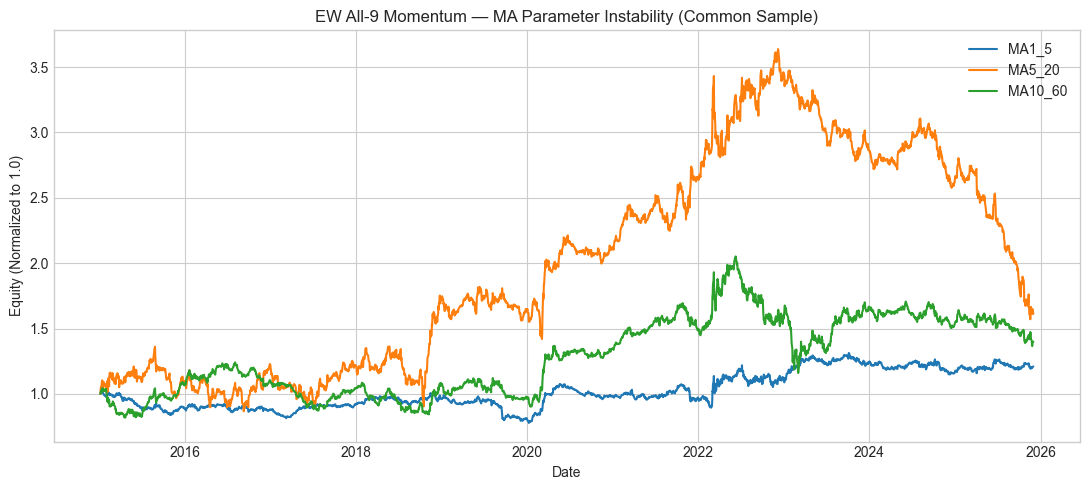

Saved to momentum_MA_crossover_instability_All9.xlsx


In [16]:
# ==============================================================
# Momentum Crossovers SEPARATELY (1,5) (5,20) (10,60)
# - Build All-9 EW portfolio for each MA pair
# - Strict intersection calendar per MA pair (per-commodity level)
# - Then strict intersection across the 3 portfolio return series (for fair comparison)
# - Plot all 3 equity curves + compute Sharpe
# - Export to Excel
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WARMUP_START = "2010-01-01"
START_DATE   = pd.Timestamp("2015-01-01")
TRADING_DAYS = 252

MA_PAIRS_LIST = [(1, 5), (5, 20), (10, 60)]
MA_WEIGHTS = None  # keep None for single-pair runs

NGL_NAMES = ["Propane", "Ethane", "Butane"]
SIX_PACK  = ["WTI", "Brent", "ULSD", "RBOB", "Natgas", "Gasoil"]
ALL_NAMES = sorted(set(NGL_NAMES + SIX_PACK))

corr_order = [
    "WTI","Brent","ULSD","RBOB","Gasoil","Natgas","Propane","Ethane","Butane",
]

# ---------------- Helpers ----------------
def ann_stats_from_logret(lr: pd.Series):
    lr = lr.replace([np.inf, -np.inf], np.nan).dropna()
    if len(lr) < 2:
        return np.nan, np.nan, np.nan
    ann_ret = lr.mean() * TRADING_DAYS
    ann_vol = lr.std(ddof=0) * np.sqrt(TRADING_DAYS)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    return ann_ret, ann_vol, sharpe

def _extract_equity_line(df: pd.DataFrame) -> pd.Series:
    if df is None or df.empty:
        return pd.Series(dtype=float)
    if "equity_line" in df.columns:
        return df["equity_line"].astype(float)
    if "net_pnl" in df.columns:
        return df["net_pnl"].astype(float).cumsum()
    return pd.Series(dtype=float)

def apply_global_K_and_logret_strict(leg_dict: dict, tag: str):
    if not leg_dict:
        raise ValueError(f"[{tag}] empty dict.")

    # strict intersection
    common_idx = None
    for df in leg_dict.values():
        idx = df.index.dropna()
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    common_idx = common_idx.sort_values()

    if len(common_idx) < 2:
        raise ValueError(f"[{tag}] common_idx too short after intersection.")

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx].copy()

    global_min = min(float(df["equity_line"].min()) for df in leg_dict.values())
    K = 1.10 * (-global_min) if global_min < 0 else 1.0

    print(f"[{tag}] intersection: {common_idx.min().date()} → {common_idx.max().date()} (n={len(common_idx):,})")
    print(f"[{tag}] global min equity_line: {global_min:,.6f}")
    print(f"[{tag}] shift K: {K:,.6f}")

    for name, df in leg_dict.items():
        w = df["equity_line"].astype(float) + K
        if (w <= 0).any():
            raise ValueError(f"[{tag}] {name}: wealth proxy <= 0 even after K; increase buffer")
        df["log_ret"] = np.log(w).diff()
        df["equity_index"] = np.exp(df["log_ret"].cumsum())

    # strict: drop first NaN everywhere
    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].dropna(subset=["log_ret"])

    # strict: re-intersect after diff drop
    common_idx2 = None
    for df in leg_dict.values():
        common_idx2 = df.index if common_idx2 is None else common_idx2.intersection(df.index)
    common_idx2 = common_idx2.sort_values()

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx2].copy()

    return leg_dict, K, common_idx2

def build_portfolio_strict(name: str, commodities: list[str], leg_dict: dict):
    cols = [c for c in commodities if c in leg_dict]
    if not cols:
        return None

    lr_df = pd.concat(
        {c: leg_dict[c]["log_ret"].astype(float) for c in cols},
        axis=1,
        join="inner",
    ).dropna(how="any").sort_index()

    if lr_df.shape[0] < 2:
        return None

    port_lr = lr_df.mean(axis=1)
    port_lr.name = name

    port_eq = np.exp(port_lr.cumsum())
    port_eq.name = name

    ann_ret, ann_vol, sharpe = ann_stats_from_logret(port_lr)

    eq_curve = port_eq / port_eq.iloc[0]
    dd = eq_curve / eq_curve.cummax() - 1.0
    max_dd = float(dd.min()) if len(dd) else np.nan

    return {
        "name": name,
        "equity": port_eq,
        "log_ret": port_lr,
        "Ann_Return": ann_ret,
        "Ann_Vol": ann_vol,
        "Ann_Sharpe": sharpe,
        "Max_DD": max_dd,
        "n_obs": int(port_lr.dropna().shape[0]),
        "start": port_lr.index.min(),
        "end": port_lr.index.max(),
    }

def _ma_label(pair: tuple[int,int]) -> str:
    return f"MA{pair[0]}_{pair[1]}"

# ==============================================================
# Run each MA crossover separately, build ALL-9 portfolio each time
# ==============================================================
PORTS_BY_MA = {}          # label -> portfolio dict
COMMOD_LEGS_BY_MA = {}    # label -> per-commodity leg dict (post log_ret)
K_BY_MA = {}              # label -> K

for (sma, lma) in MA_PAIRS_LIST:
    label = _ma_label((sma, lma))
    print("\n" + "="*70)
    print(f"Running crossover: {label}")
    print("="*70)

    legs = {}  # commodity -> DataFrame({"equity_line": ...})

    for commodity, cfg in BASE_ROLL_STYLES.items():
        if commodity not in COMMODITIES:
            continue

        ticker, contracts, units, t_cost = COMMODITIES[commodity]

        prices = load_prices(commodity, ticker, normalize=True).loc[WARMUP_START:].sort_index()
        if prices.empty:
            continue

        expiry_cal = load_expiry(ticker)
        style      = cfg["style"]
        front_col  = cfg.get("front_col", "F1")
        next_col   = cfg.get("next_col", "F2")

        rs = RollingStrategy(prices=prices, expiry_calendar=expiry_cal,
                             front_col=front_col, next_col=next_col)

        if style == "eom_ngl":
            rolled_df = rs.equity(style="eom_ngl", t_cost=t_cost,
                                  mid_col=cfg.get("mid_col", "F3"),
                                  far_col=cfg.get("far_col", "F4"))
        elif style == "eom_mid":
            rolled_df = rs.equity(style="eom_mid", t_cost=t_cost)
        elif style == "eom_dynamic":
            rolled_df = rs.equity(style="eom_dynamic", t_cost=t_cost,
                                  third_col=cfg.get("third_col", "F3"))
        elif style == "eom_eom":
            rolled_df = rs.equity(style="eom_eom", t_cost=t_cost,
                                  third_col=cfg.get("third_col", "F3"))
        else:
            continue

        rolled_df = rolled_df.sort_index()
        if not all(col in rolled_df.columns for col in ["daily_pnl", "t_cost", "roll_day_flag"]):
            continue

        # IMPORTANT: run ONLY this crossover
        mom_df = momentum(
            prices=prices,
            rolled_df=rolled_df,
            front_col=front_col,
            short_ma=sma,         # keep consistent with the pair
            long_ma=lma,
            t_cost=t_cost,
            epsilon=0.0,
            ma_pairs=[(sma, lma)], # single-pair run
            weights=MA_WEIGHTS,
        )
        if mom_df is None or mom_df.empty:
            continue

        eq = _extract_equity_line(mom_df.sort_index()).loc[START_DATE:].dropna()
        if len(eq) < 3:
            continue

        legs[commodity] = pd.DataFrame({"equity_line": eq})

    if not legs:
        raise ValueError(f"{label}: no commodity legs built.")

    # strict intersection + global K (within this MA pair’s leg set)
    legs, K, _ = apply_global_K_and_logret_strict(legs, tag=f"MOM_{label}")
    COMMOD_LEGS_BY_MA[label] = legs
    K_BY_MA[label] = K

    # All-9 EW portfolio
    port = build_portfolio_strict(f"EW_All9_Mom_{label}", ALL_NAMES, legs)
    if port is None:
        raise RuntimeError(f"{label}: could not build All-9 portfolio (overlap too small).")

    PORTS_BY_MA[label] = port

# ==============================================================
# Fair comparison: strict intersection across the 3 portfolio return series
# ==============================================================
port_lr_raw = pd.concat(
    {label: p["log_ret"].astype(float) for label, p in PORTS_BY_MA.items()},
    axis=1,
    join="inner",
).dropna(how="any").sort_index()

if port_lr_raw.shape[0] < 2:
    raise RuntimeError("Portfolio return intersection across MA pairs is too small.")

# rebuild equity from the common sample so plot + Sharpe are apples-to-apples
port_eq_common = np.exp(port_lr_raw.cumsum())
port_eq_common = port_eq_common.div(port_eq_common.iloc[0])

metrics_rows = []
for label in port_lr_raw.columns:
    lr = port_lr_raw[label]
    ann_ret, ann_vol, sharpe = ann_stats_from_logret(lr)

    eq = np.exp(lr.cumsum())
    eq = eq / eq.iloc[0]
    dd = eq / eq.cummax() - 1.0
    max_dd = float(dd.min()) if len(dd) else np.nan

    metrics_rows.append({
        "MA_Spec": label,
        "Start": lr.index.min(),
        "End": lr.index.max(),
        "N_Obs": int(lr.dropna().shape[0]),
        "Ann_Return": ann_ret,
        "Ann_Vol": ann_vol,
        "Ann_Sharpe": sharpe,
        "Max_DD": max_dd,
    })

metrics_common_df = pd.DataFrame(metrics_rows).set_index("MA_Spec").sort_index()
display(metrics_common_df.round(4))

# ==============================================================
# Plot: all three equity curves (common sample)
# ==============================================================
plt.figure(figsize=(11, 5))
for col in port_eq_common.columns:
    plt.plot(port_eq_common.index, port_eq_common[col], label=col)
plt.title("EW All-9 Momentum — MA Parameter Instability (Common Sample)")
plt.ylabel("Equity (Normalized to 1.0)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================
# Optional: correlations per MA spec (common sample, strict order)
# ==============================================================
corr_names = [c for c in corr_order if c in ALL_NAMES]

corr_mats = {}
for label, legs in COMMOD_LEGS_BY_MA.items():
    # strict overlap inside this label (already strict), then compute corr
    lr_all = pd.concat(
        {c: legs[c]["log_ret"].astype(float) for c in corr_names if c in legs},
        axis=1,
        join="inner",
    ).dropna(how="any").sort_index()

    cm = lr_all.corr().reindex(index=corr_names, columns=corr_names)
    corr_mats[label] = cm

# ==============================================================
# Export to Excel
# ==============================================================
out_path = "momentum_MA_crossover_instability_All9.xlsx"

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    port_lr_raw.index.name = "Date"
    port_eq_common.index.name = "Date"

    port_lr_raw.to_excel(writer, sheet_name="All9_LogRet_Common")
    port_eq_common.to_excel(writer, sheet_name="All9_Equity_Common")
    metrics_common_df.to_excel(writer, sheet_name="All9_Metrics_Common")

    # also dump each MA’s per-commodity log returns (useful appendix evidence)
    for label, legs in COMMOD_LEGS_BY_MA.items():
        lr_df = pd.concat(
            {c: legs[c]["log_ret"].astype(float) for c in corr_names if c in legs},
            axis=1,
            join="inner",
        ).dropna(how="any").sort_index()
        lr_df.index.name = "Date"
        lr_df.to_excel(writer, sheet_name=f"Legs_LogRet_{label}"[:31])  # Excel sheet limit

        corr_mats[label].to_excel(writer, sheet_name=f"Corr_{label}"[:31])

print(f"Saved to {out_path}")


## Carry

[CARRY_F4_F15] intersection: 2015-01-02 → 2025-12-01 (n=2,746)
[CARRY_F4_F15] global min equity_line: -55.070400
[CARRY_F4_F15] shift K: 60.577440


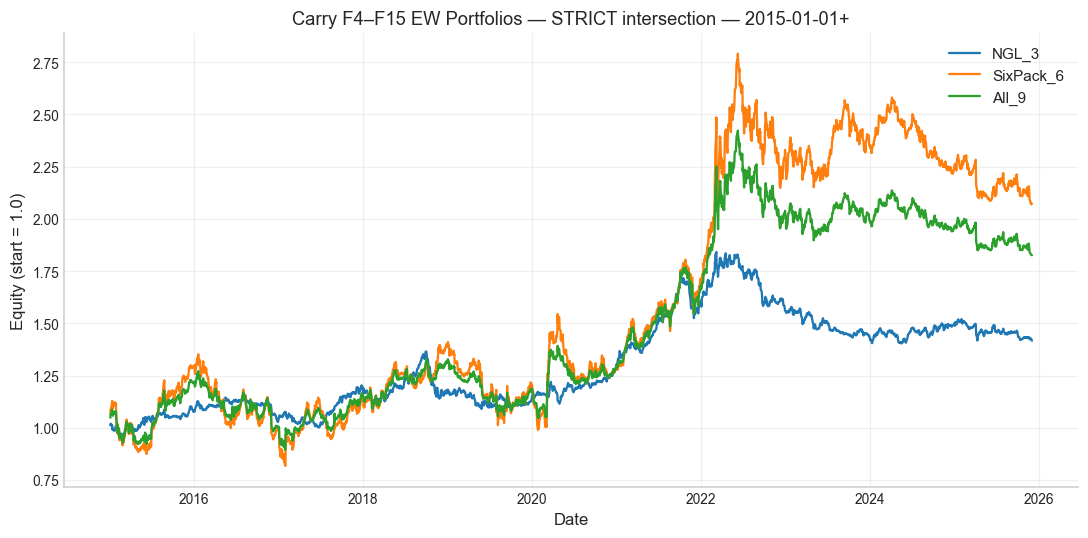

,Ann_Sharpe,Ann_Return,Ann_Vol,Max_DD
NGL_3,0.3866,0.0320,0.0827,-0.2379
SixPack_6,0.3052,0.0669,0.2192,-0.3952
All_9,0.3564,0.0553,0.1550,-0.2961


Sample    Full Sample                         2015-2022                 \
Metric     Ann_Return Ann_Vol Sharpe  Max_DD Ann_Return Ann_Vol Sharpe   
NGL_3          0.0320  0.0827 0.3866 -0.2379     0.0678  0.0860 0.7884   
SixPack_6      0.0669  0.2192 0.3052 -0.3952     0.0752  0.2418 0.3111   
All_9          0.0553  0.1550 0.3564 -0.2961     0.0728  0.1673 0.4349   

Sample             2022-2025                          
Metric     Max_DD Ann_Return Ann_Vol  Sharpe  Max_DD  
NGL_3     -0.2016    -0.0323  0.0761 -0.4248 -0.2379  
SixPack_6 -0.3952     0.0519  0.1713  0.3032 -0.2582  
All_9     -0.2961     0.0239  0.1301  0.1833 -0.2462

Saved to carry_F4_F15_STRICT_portfolio_returns.xlsx


In [ ]:
# ==============================================================
# CARRY F4–F15 — STRICT INTERSECTION CALENDAR (FIXED)
# - No synthetic business-day calendars (NO freq="B")
# - No fillna(0) anywhere for returns
# - If a date is missing for any leg -> DROP the date
# - After diff(): drop first NaN for ALL legs and re-intersect
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

WARMUP_START    = "2014-12-01"
START_DATE      = pd.Timestamp("2015-01-01")
TRADING_DAYS    = 252

CARRY_FRONT_COL = "F4"
CARRY_END_COL   = "F15"

NGL_NAMES = ["Propane", "Ethane", "Butane"]
SIX_PACK  = ["WTI", "Brent", "ULSD", "RBOB", "Natgas", "Gasoil"]
ALL_NAMES = sorted(set(NGL_NAMES + SIX_PACK))

ALL_CARRY = {}   # commodity -> DataFrame with ['equity_line','log_ret','equity_index']


def _slice(s: pd.Series, start=None, end=None):
    if start is not None:
        s = s.loc[s.index >= start]
    if end is not None:
        s = s.loc[s.index <= end]
    return s


def ann_stats_from_logret(lr: pd.Series):
    lr = lr.replace([np.inf, -np.inf], np.nan).dropna()
    if len(lr) < 2:
        return np.nan, np.nan, np.nan
    ann_ret = lr.mean() * TRADING_DAYS
    ann_vol = lr.std(ddof=0) * np.sqrt(TRADING_DAYS)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    return ann_ret, ann_vol, sharpe


def apply_global_K_and_logret_strict(leg_dict: dict, tag: str):
    """
    leg_dict: {name: DataFrame with 'equity_line'} (already trade-windowed)
    Enforces strict intersection calendar across ALL legs in leg_dict.
    Computes global K on that intersection, then log_ret + equity_index.
    Returns: (leg_dict_aligned, K, common_idx)
    """
    if not leg_dict:
        raise ValueError(f"[{tag}] empty dict.")

    # strict intersection calendar across legs
    common_idx = None
    for df in leg_dict.values():
        idx = df.index.dropna()
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    common_idx = common_idx.sort_values()

    if len(common_idx) < 2:
        raise ValueError(f"[{tag}] common_idx too short after intersection.")

    # align all legs to common_idx
    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx].copy()

    global_min = min(float(df["equity_line"].min()) for df in leg_dict.values())
    K = 1.10 * (-global_min) if global_min < 0 else 1.0

    print(f"[{tag}] intersection: {common_idx.min().date()} → {common_idx.max().date()} (n={len(common_idx):,})")
    print(f"[{tag}] global min equity_line: {global_min:,.6f}")
    print(f"[{tag}] shift K: {K:,.6f}")

    # log returns + equity index
    for name, df in leg_dict.items():
        w = df["equity_line"].astype(float) + K
        if (w <= 0).any():
            raise ValueError(f"[{tag}] {name}: wealth proxy <= 0 even after K; increase buffer")
        df["log_ret"] = np.log(w).diff()
        df["equity_index"] = np.exp(df["log_ret"].cumsum())

    # STRICT: drop first diff NaN everywhere (no fillna(0))
    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].dropna(subset=["log_ret"])

    # re-intersect after dropping first NaN so everything stays perfectly aligned
    common_idx2 = None
    for df in leg_dict.values():
        common_idx2 = df.index if common_idx2 is None else common_idx2.intersection(df.index)
    common_idx2 = common_idx2.sort_values()

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx2].copy()

    return leg_dict, K, common_idx2


def build_portfolio_strict(name: str, commodities: list[str], leg_dict: dict):
    cols = [c for c in commodities if c in leg_dict]
    if not cols:
        return None

    # strict overlap calendar for this subset (no fill, no union)
    lr_df = pd.concat(
        {c: leg_dict[c]["log_ret"].astype(float) for c in cols},
        axis=1,
        join="inner",
    ).dropna(how="any").sort_index()

    if lr_df.shape[0] < 2:
        return None

    port_lr = lr_df.mean(axis=1)
    port_lr.name = name

    port_eq = np.exp(port_lr.cumsum())
    port_eq.name = name

    ann_ret, ann_vol, sharpe = ann_stats_from_logret(port_lr)

    eq_curve = port_eq / port_eq.iloc[0]
    dd = eq_curve / eq_curve.cummax() - 1.0
    max_dd = float(dd.min()) if len(dd) else np.nan

    return {
        "name": name,
        "equity": port_eq,
        "log_ret": port_lr,
        "Ann_Return": ann_ret,
        "Ann_Vol": ann_vol,
        "Ann_Sharpe": sharpe,
        "Max_DD": max_dd,
    }


# ==============================================================
# 1) Per-commodity carry equity_line (trade window only)
# ==============================================================
for commodity, cfg in BASE_ROLL_STYLES.items():
    if commodity not in COMMODITIES:
        continue

    ticker, contracts, units, t_cost = COMMODITIES[commodity]

    prices = load_prices(commodity, ticker, normalize=True).loc[WARMUP_START:].sort_index()
    if prices.empty:
        continue

    expiry_cal = load_expiry(ticker)
    style      = cfg["style"]
    front_col  = cfg.get("front_col", "F1")
    next_col   = cfg.get("next_col", "F2")

    rs = RollingStrategy(prices=prices, expiry_calendar=expiry_cal, front_col=front_col, next_col=next_col)

    if style == "eom_ngl":
        rolled_df = rs.equity(style="eom_ngl", t_cost=t_cost,
                              mid_col=cfg.get("mid_col", "F3"),
                              far_col=cfg.get("far_col", "F4"))
    elif style == "eom_mid":
        rolled_df = rs.equity(style="eom_mid", t_cost=t_cost)
    elif style == "eom_dynamic":
        rolled_df = rs.equity(style="eom_dynamic", t_cost=t_cost,
                              third_col=cfg.get("third_col", "F3"))
    elif style == "eom_eom":
        rolled_df = rs.equity(style="eom_eom", t_cost=t_cost,
                              third_col=cfg.get("third_col", "F3"))
    else:
        continue

    rolled_df = rolled_df.sort_index()
    if not all(c in rolled_df.columns for c in ["daily_pnl", "t_cost", "roll_day_flag"]):
        continue

    carry_df = carry(
        prices=prices,
        rolled_df=rolled_df,
        front_col=CARRY_FRONT_COL,
        end_col=CARRY_END_COL,
        t_cost=t_cost,
        epsilon=0.0,
    )

    if carry_df is None or carry_df.empty:
        continue

    carry_df = carry_df.sort_index()

    if "equity_line" in carry_df.columns:
        eq = carry_df["equity_line"].astype(float)
    elif "net_pnl" in carry_df.columns:
        eq = carry_df["net_pnl"].astype(float).cumsum()
    else:
        continue

    eq = eq.loc[START_DATE:].dropna()
    if len(eq) < 3:
        continue

    ALL_CARRY[commodity] = pd.DataFrame({"equity_line": eq})

if not ALL_CARRY:
    raise RuntimeError("ALL_CARRY is empty. No carry series were built.")


# ==============================================================
# 2) STRICT intersection calendar + global K + log returns (FIXED)
# ==============================================================
ALL_CARRY, K, common_idx = apply_global_K_and_logret_strict(ALL_CARRY, tag="CARRY_F4_F15")


# ==============================================================
# 3) STRICT portfolios (subset intersection only)
# ==============================================================
ngl_port = build_portfolio_strict("NGL_3", NGL_NAMES, ALL_CARRY)
six_port = build_portfolio_strict("SixPack_6", SIX_PACK, ALL_CARRY)
all_port = build_portfolio_strict("All_9", ALL_NAMES, ALL_CARRY)

ports = [p for p in [ngl_port, six_port, all_port] if p is not None]
if not ports:
    raise RuntimeError("No carry portfolios could be built (too few overlapping dates).")


# ==============================================================
# 4) Plot
# ==============================================================
plt.figure(figsize=(10, 5))
for p in ports:
    plt.plot(p["equity"].index, p["equity"], label=p["name"])
plt.title(f"Carry F4–F15 EW Portfolios — STRICT intersection — {START_DATE.date()}+")
plt.xlabel("Date")
plt.ylabel("Equity (start = 1.0)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ==============================================================
# 5) Metrics table
# ==============================================================
metrics_df = pd.DataFrame(
    {
        p["name"]: {
            "Ann_Sharpe": p["Ann_Sharpe"],
            "Ann_Return": p["Ann_Return"],
            "Ann_Vol":    p["Ann_Vol"],
            "Max_DD":     p["Max_DD"],
        }
        for p in ports
    }
).T
display(metrics_df.round(4))


# ==============================================================
# 6) Correlation matrix (STRICT overlap, no fillna)
# ==============================================================

corr_order = [
    "WTI",
    "Brent",
    "ULSD",
    "RBOB",
    "Gasoil",
    "Natgas",
    "Propane",
    "Ethane",
    "Butane",
]
corr_names = [c for c in corr_order if c in ALL_CARRY]

logret_all = pd.concat(
    {c: ALL_CARRY[c]["log_ret"].astype(float) for c in corr_names},
    axis=1,
    join="inner",
).dropna(how="any").sort_index()

corr_mat = logret_all.corr()
corr_mat = corr_mat.reindex(index=corr_names, columns=corr_names)

# ==============================================================
# 7) Multi-period portfolio stats (LOG-space, strict)
# ==============================================================
SUB_PERIODS = {
    "Full Sample": (None, None),
    "2015-2022":   (pd.Timestamp("2015-01-01"), pd.Timestamp("2021-12-31")),
    "2022-2025":   (pd.Timestamp("2022-01-01"), None),
}

def stats_for_period_from_lr(lr: pd.Series, start, end):
    sub = _slice(lr, start, end).replace([np.inf, -np.inf], np.nan).dropna()
    ann_ret, ann_vol, sharpe = ann_stats_from_logret(sub)
    if len(sub) < 2:
        return np.nan, np.nan, np.nan, np.nan
    eq = np.exp(sub.cumsum())
    eq = eq / eq.iloc[0]
    dd = eq / eq.cummax() - 1.0
    max_dd = float(dd.min()) if len(dd) else np.nan
    return ann_ret, ann_vol, sharpe, max_dd

cols = pd.MultiIndex.from_product(
    [list(SUB_PERIODS.keys()), ["Ann_Return","Ann_Vol","Sharpe","Max_DD"]],
    names=["Sample","Metric"]
)
portfolio_stats = pd.DataFrame(index=[p["name"] for p in ports], columns=cols, dtype=float)

for p in ports:
    lr = p["log_ret"].astype(float)
    for per_label, (start, end) in SUB_PERIODS.items():
        ann_ret, ann_vol, sharpe, max_dd = stats_for_period_from_lr(lr, start, end)
        portfolio_stats.loc[p["name"], (per_label, "Ann_Return")] = ann_ret
        portfolio_stats.loc[p["name"], (per_label, "Ann_Vol")]    = ann_vol
        portfolio_stats.loc[p["name"], (per_label, "Sharpe")]     = sharpe
        portfolio_stats.loc[p["name"], (per_label, "Max_DD")]     = max_dd

display(portfolio_stats.round(4))


# ==============================================================
# 8) Excel export
# ==============================================================

ret_df = pd.concat({p["name"]: p["log_ret"].astype(float) for p in ports}, axis=1).sort_index()
ret_df.index.name = "Date"

# portfolio equity curves (what you plot)
equity_df = pd.concat({p["name"]: p["equity"].astype(float) for p in ports}, axis=1).sort_index()
equity_df.index.name = "Date"

out_path = "carry_F4_F15_STRICT_portfolio_returns.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    ret_df.to_excel(writer, sheet_name="Portfolio_LogRet")
    equity_df.to_excel(writer, sheet_name="Portfolio_Equity")
    metrics_df.to_excel(writer, sheet_name="Portfolio_Metrics")
    portfolio_stats.to_excel(writer, sheet_name="Portfolio_Stats")
    corr_mat.to_excel(writer, sheet_name="Corr_Matrix")

print(f"Saved to {out_path}")


## Value

[VALUE_M12_13] intersection: 2015-01-02 → 2025-12-01 (n=2,746)
[VALUE_M12_13] global min equity_line: -72.516779
[VALUE_M12_13] shift K: 79.768456


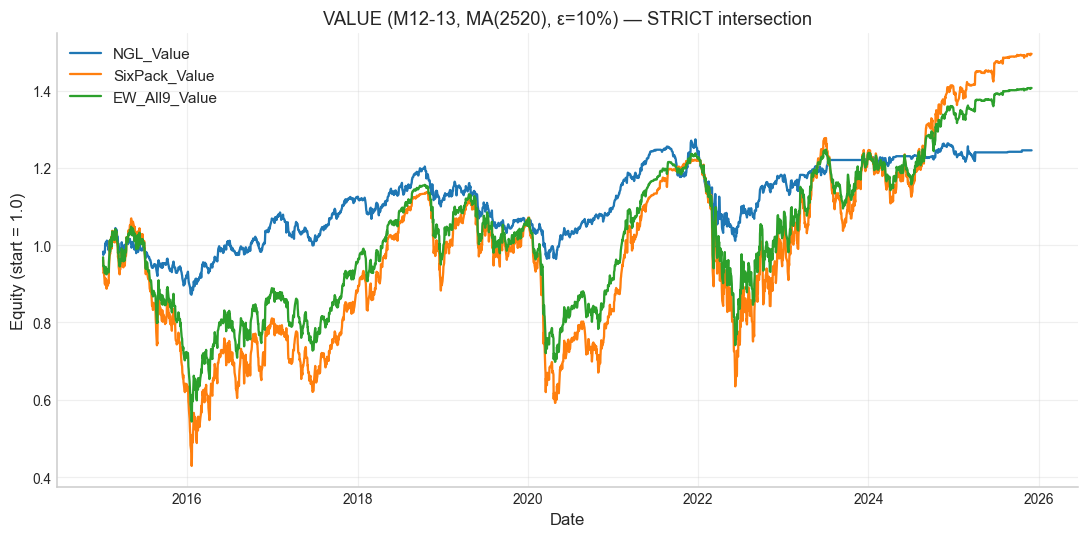

,Ann_Sharpe,Ann_Return,Ann_Vol,Max_DD
NGL_Value,0.2356,0.0201,0.0855,-0.2061
SixPack_Value,0.1321,0.0369,0.2796,-0.5990
EW_All9_Value,0.1528,0.0313,0.2050,-0.4812


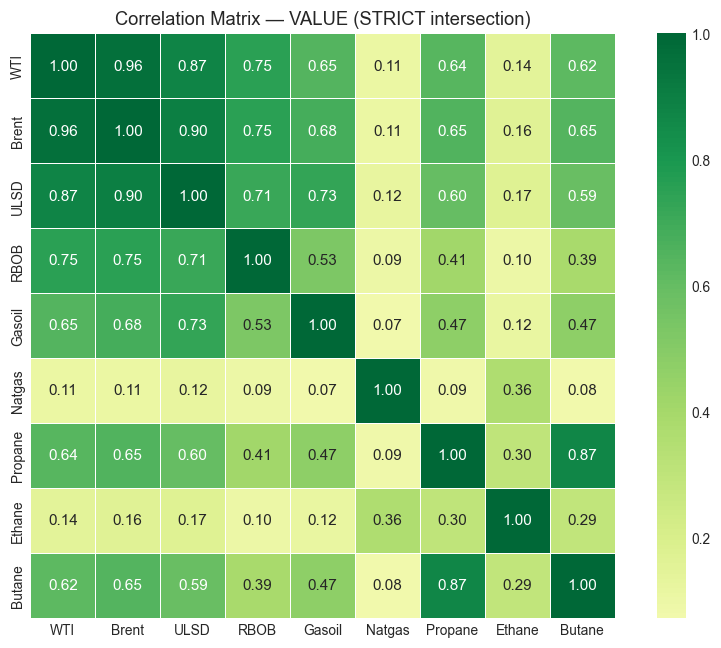

,WTI,Brent,ULSD,RBOB,Gasoil,Natgas,Propane,Ethane,Butane
WTI,1.0000,0.9610,0.8740,0.7510,0.6450,0.1120,0.6400,0.1440,0.6220
Brent,0.9610,1.0000,0.9030,0.7510,0.6820,0.1070,0.6530,0.1620,0.6450
ULSD,0.8740,0.9030,1.0000,0.7130,0.7270,0.1230,0.6000,0.1670,0.5900
RBOB,0.7510,0.7510,0.7130,1.0000,0.5260,0.0940,0.4090,0.1050,0.3890
Gasoil,0.6450,0.6820,0.7270,0.5260,1.0000,0.0720,0.4740,0.1170,0.4720
Natgas,0.1120,0.1070,0.1230,0.0940,0.0720,1.0000,0.0850,0.3590,0.0750
Propane,0.6400,0.6530,0.6000,0.4090,0.4740,0.0850,1.0000,0.3000,0.8700
Ethane,0.1440,0.1620,0.1670,0.1050,0.1170,0.3590,0.3000,1.0000,0.2950
Butane,0.6220,0.6450,0.5900,0.3890,0.4720,0.0750,0.8700,0.2950,1.0000


Sample        Full Sample                         2015-2022                 \
Metric         Ann_Return Ann_Vol Sharpe  Max_DD Ann_Return Ann_Vol Sharpe   
NGL_Value          0.0201  0.0855 0.2356 -0.2061     0.0302  0.0824 0.3672   
SixPack_Value      0.0369  0.2796 0.1321 -0.5990     0.0285  0.2758 0.1032   
EW_All9_Value      0.0313  0.2050 0.1528 -0.4812     0.0291  0.2028 0.1433   

Sample                 2022-2025                         
Metric         Max_DD Ann_Return Ann_Vol Sharpe  Max_DD  
NGL_Value     -0.1988     0.0021  0.0908 0.0226 -0.1864  
SixPack_Value -0.5990     0.0521  0.2861 0.1821 -0.4797  
EW_All9_Value -0.4812     0.0354  0.2089 0.1695 -0.3959

Saved to value_M12_13_STRICT_portfolio_returns.xlsx


In [ ]:
# ==============================================================
# VALUE Strategy — Roll M12-13, MA(2520), epsilon-band
# INTERSECTION-CALENDAR VERSION
#
# CLEAN + CONSISTENT (NO INIT_CAPITAL):
#   - Per-commodity equity_line from value()
#   - STRICT intersection calendar across all commodities
#   - Global wealth-proxy shift K chosen on intersection
#   - log_ret = log(w_t) - log(w_{t-1})
#   - EW portfolios built on intersection (no ffill, no union)
#   - Stats: annualized mean LOG return + vol + Sharpe
#   - Corr order fixed
# ==============================================================


# ---------------- Config ----------------
VALUE_MA_WINDOW  = 252 * 10
VALUE_VOL_WINDOW = 252
VALUE_EPS_BAND   = 0.10

HIST_START   = "2010-01-01"
TRADE_START  = START_DATE
TRADING_DAYS = 252

NGL_NAMES = ["Propane", "Ethane", "Butane"]
SIX_PACK  = ["WTI", "Brent", "ULSD", "RBOB", "Natgas", "Gasoil"]
ALL_NAMES = sorted(set(NGL_NAMES + SIX_PACK))

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def ann_stats_from_logret(lr: pd.Series):
    lr = lr.replace([np.inf, -np.inf], np.nan).dropna()
    if len(lr) < 2:
        return np.nan, np.nan, np.nan
    ann_ret = lr.mean() * TRADING_DAYS
    ann_vol = lr.std(ddof=0) * np.sqrt(TRADING_DAYS)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    return ann_ret, ann_vol, sharpe


def slice_period(s: pd.Series, start=None, end=None):
    if start is not None:
        s = s.loc[s.index >= start]
    if end is not None:
        s = s.loc[s.index <= end]
    return s


# -------------------------------------------------
# 1) Build per-commodity VALUE equity_line (trade window only)
# -------------------------------------------------
VAL_RAW = {}   # commodity -> equity_line (Series)

for commodity, cfg in BASE_ROLL_STYLES.items():
    if commodity not in COMMODITIES:
        continue

    ticker, contracts, units, t_cost = COMMODITIES[commodity]

    prices_full = load_prices(commodity, ticker, normalize=True).loc[HIST_START:].sort_index()
    if prices_full.empty:
        continue

    expiry_cal = load_expiry(ticker)
    cols = prices_full.columns

    # force M12/M13 anchor
    if "F12" in cols and "F13" in cols:
        roll_front, roll_next = "F12", "F13"
        anchor = 0.5 * prices_full["F12"] + 0.5 * prices_full["F13"]
    elif "F12" in cols:
        roll_front = roll_next = "F12"
        anchor = prices_full["F12"]
    elif "F13" in cols:
        roll_front = roll_next = "F13"
        anchor = prices_full["F13"]
    else:
        roll_front = cfg.get("front_col", "F1")
        roll_next  = cfg.get("next_col", "F2")
        anchor = prices_full[roll_front]

    rs = RollingStrategy(
        prices=prices_full,
        expiry_calendar=expiry_cal,
        front_col=roll_front,
        next_col=roll_next,
    )

    rolled = rs.equity(style="eom_mid", t_cost=t_cost).sort_index()
    if not all(c in rolled.columns for c in ["daily_pnl", "t_cost", "roll_day_flag"]):
        continue

    anchor = anchor.reindex(rolled.index).ffill()
    if anchor.dropna().empty:
        continue

    val_df = value(
        prices=pd.DataFrame({"VAL_ANCHOR": anchor}),
        rolled_df=rolled,
        front_col="VAL_ANCHOR",
        long_ma=VALUE_MA_WINDOW,
        vol_window=VALUE_VOL_WINDOW,
        epsilon_factor=VALUE_EPS_BAND,
        t_cost=t_cost,
    )

    if val_df is None or val_df.empty:
        continue

    if "equity_line" in val_df.columns:
        eq = val_df["equity_line"].astype(float)
    elif "net_pnl" in val_df.columns:
        eq = val_df["net_pnl"].astype(float).cumsum()
    else:
        continue

    eq = eq.loc[TRADE_START:].dropna()
    if len(eq) < 2:
        continue

    VAL_RAW[commodity] = eq


if not VAL_RAW:
    raise RuntimeError("No VALUE series constructed.")

# -------------------------------------------------
# 2) STRICT INTERSECTION CALENDAR + GLOBAL K + STRICT LOGRET
# -------------------------------------------------
# Convert to leg_dict like the other strategies: {commodity: DataFrame('equity_line')}
VAL_LEGS = {c: pd.DataFrame({"equity_line": s.astype(float)}) for c, s in VAL_RAW.items()}

def apply_global_K_and_logret_strict(leg_dict: dict, tag: str):
    if not leg_dict:
        raise ValueError(f"[{tag}] empty dict.")

    # strict intersection calendar across legs
    common_idx = None
    for df in leg_dict.values():
        idx = df.index.dropna()
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    common_idx = common_idx.sort_values()

    if len(common_idx) < 2:
        raise ValueError(f"[{tag}] common_idx too short after intersection.")

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx].copy()

    global_min = min(float(df["equity_line"].min()) for df in leg_dict.values())
    K = 1.10 * (-global_min) if global_min < 0 else 1.0

    print(f"[{tag}] intersection: {common_idx.min().date()} → {common_idx.max().date()} (n={len(common_idx):,})")
    print(f"[{tag}] global min equity_line: {global_min:,.6f}")
    print(f"[{tag}] shift K: {K:,.6f}")

    for name, df in leg_dict.items():
        w = df["equity_line"].astype(float) + K
        if (w <= 0).any():
            raise ValueError(f"[{tag}] {name}: wealth proxy <= 0 even after K")
        df["log_ret"] = np.log(w).diff()
        df["equity_index"] = np.exp(df["log_ret"].cumsum())

    # STRICT: drop first NaN everywhere (NO fillna(0))
    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].dropna(subset=["log_ret"])

    # STRICT: re-intersect after diff drop
    common_idx2 = None
    for df in leg_dict.values():
        common_idx2 = df.index if common_idx2 is None else common_idx2.intersection(df.index)
    common_idx2 = common_idx2.sort_values()

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx2].copy()

    return leg_dict, K, common_idx2

VAL_LEGS, K, common_idx = apply_global_K_and_logret_strict(VAL_LEGS, tag="VALUE_M12_13")


# -------------------------------------------------
# 3) EW portfolios (STRICT overlap, subset-specific inner join)
# -------------------------------------------------
def build_portfolio_strict(name: str, commodities: list[str], leg_dict: dict):
    cols = [c for c in commodities if c in leg_dict]
    if not cols:
        return None

    lr_df = pd.concat(
        {c: leg_dict[c]["log_ret"].astype(float) for c in cols},
        axis=1,
        join="inner",
    ).dropna(how="any").sort_index()

    if lr_df.shape[0] < 2:
        return None

    port_lr = lr_df.mean(axis=1)
    port_lr.name = name

    port_eq = np.exp(port_lr.cumsum())
    port_eq.name = name

    ann_ret, ann_vol, sharpe = ann_stats_from_logret(port_lr)

    eq_curve = port_eq / port_eq.iloc[0]
    dd = eq_curve / eq_curve.cummax() - 1.0
    max_dd = float(dd.min()) if len(dd) else np.nan

    return {
        "name": name,
        "log_ret": port_lr,
        "equity": port_eq,
        "Ann_Return": ann_ret,
        "Ann_Vol": ann_vol,
        "Ann_Sharpe": sharpe,
        "Max_DD": max_dd,
    }

ngl_port = build_portfolio_strict("NGL_Value", NGL_NAMES, VAL_LEGS)
six_port = build_portfolio_strict("SixPack_Value", SIX_PACK, VAL_LEGS)
all_port = build_portfolio_strict("EW_All9_Value", ALL_NAMES, VAL_LEGS)

ports = [p for p in [ngl_port, six_port, all_port] if p is not None]
if len(ports) != 3:
    raise RuntimeError("One of the three requested VALUE portfolios could not be built (overlap too small).")


# -------------------------------------------------
# 4) Plot portfolios
# -------------------------------------------------
plt.figure(figsize=(10, 5))
for p in ports:
    plt.plot(p["equity"].index, p["equity"], label=p["name"])
plt.title(f"VALUE (M12-13, MA(2520), ε={VALUE_EPS_BAND:.0%}) — STRICT intersection")
plt.xlabel("Date")
plt.ylabel("Equity (start = 1.0)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 5) Metrics table
# -------------------------------------------------
metrics_df = pd.DataFrame(
    {
        p["name"]: {
            "Ann_Sharpe": p["Ann_Sharpe"],
            "Ann_Return": p["Ann_Return"],
            "Ann_Vol":    p["Ann_Vol"],
            "Max_DD":     p["Max_DD"],
        }
        for p in ports
    }
).T
display(metrics_df.round(4))


# -------------------------------------------------
# 6) Correlation matrix (STRICT, strict order)
# -------------------------------------------------
corr_order = [
    "WTI",
    "Brent",
    "ULSD",
    "RBOB",
    "Gasoil",
    "Natgas",
    "Propane",
    "Ethane",
    "Butane",
]
corr_names = [c for c in corr_order if c in VAL_LEGS]

logret_corr = pd.concat(
    {c: VAL_LEGS[c]["log_ret"].astype(float) for c in corr_names},
    axis=1,
    join="inner",
).dropna(how="any").sort_index()

corr_mat = logret_corr.corr()
corr_mat = corr_mat.reindex(index=corr_names, columns=corr_names)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_mat,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
)
plt.title("Correlation Matrix — VALUE (STRICT intersection)")
plt.tight_layout()
plt.show()
display(corr_mat.round(3))

SUB_PERIODS = {
    "Full Sample": (None, None),
    "2015-2022":   (pd.Timestamp("2015-01-01"), pd.Timestamp("2021-12-31")),
    "2022-2025":   (pd.Timestamp("2022-01-01"), None),
}

def time_split_metrics_from_ports(ports, sub_periods=SUB_PERIODS):
    metric_labels = ["Ann_Return", "Ann_Vol", "Sharpe", "Max_DD"]
    cols = pd.MultiIndex.from_product([list(sub_periods.keys()), metric_labels],
                                      names=["Sample", "Metric"])
    out = pd.DataFrame(index=[p["name"] for p in ports], columns=cols, dtype=float)

    for p in ports:
        lr = p["log_ret"].astype(float).replace([np.inf, -np.inf], np.nan)

        for per_label, (start, end) in sub_periods.items():
            sub = lr
            if start is not None:
                sub = sub.loc[sub.index >= start]
            if end is not None:
                sub = sub.loc[sub.index <= end]
            sub = sub.dropna()

            ann_ret, ann_vol, sharpe = ann_stats_from_logret(sub)

            if len(sub) < 2:
                max_dd = np.nan
            else:
                eq = np.exp(sub.cumsum())
                eq = eq / eq.iloc[0]
                dd = eq / eq.cummax() - 1.0
                max_dd = float(dd.min()) if len(dd) else np.nan

            out.loc[p["name"], (per_label, "Ann_Return")] = ann_ret
            out.loc[p["name"], (per_label, "Ann_Vol")]    = ann_vol
            out.loc[p["name"], (per_label, "Sharpe")]     = sharpe
            out.loc[p["name"], (per_label, "Max_DD")]     = max_dd

    return out

split_stats_df = time_split_metrics_from_ports(ports, SUB_PERIODS)
display(split_stats_df.round(4))



# -------------------------------------------------
# 7) Export: ONLY plotted portfolio returns + equity (+ metrics/corr)
# -------------------------------------------------
ret_df = pd.concat({p["name"]: p["log_ret"].astype(float) for p in ports}, axis=1).sort_index()
ret_df.index.name = "Date"

equity_df = pd.concat({p["name"]: p["equity"].astype(float) for p in ports}, axis=1).sort_index()
equity_df.index.name = "Date"

out_path = "value_M12_13_STRICT_portfolio_returns.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    ret_df.to_excel(writer, sheet_name="Portfolio_LogRet")
    equity_df.to_excel(writer, sheet_name="Portfolio_Equity")
    metrics_df.to_excel(writer, sheet_name="Portfolio_Metrics")
    split_stats_df.to_excel(writer, sheet_name="TimeSplit_Stats")
    corr_mat.to_excel(writer, sheet_name="Corr_Matrix")

print(f"Saved to {out_path}")




## 50% Momentum, 50% Value

[MA] n_series=9
[MA] common_idx: 2015-01-02 -> 2025-12-01 (n=2746)
[MA] global min equity_line on common calendar: -82.756800
[MA] using shift K: 91.032480
[VAL] n_series=9
[VAL] common_idx: 2015-01-02 -> 2025-12-01 (n=2746)
[VAL] global min equity_line on common calendar: -72.516779
[VAL] using shift K: 79.768456


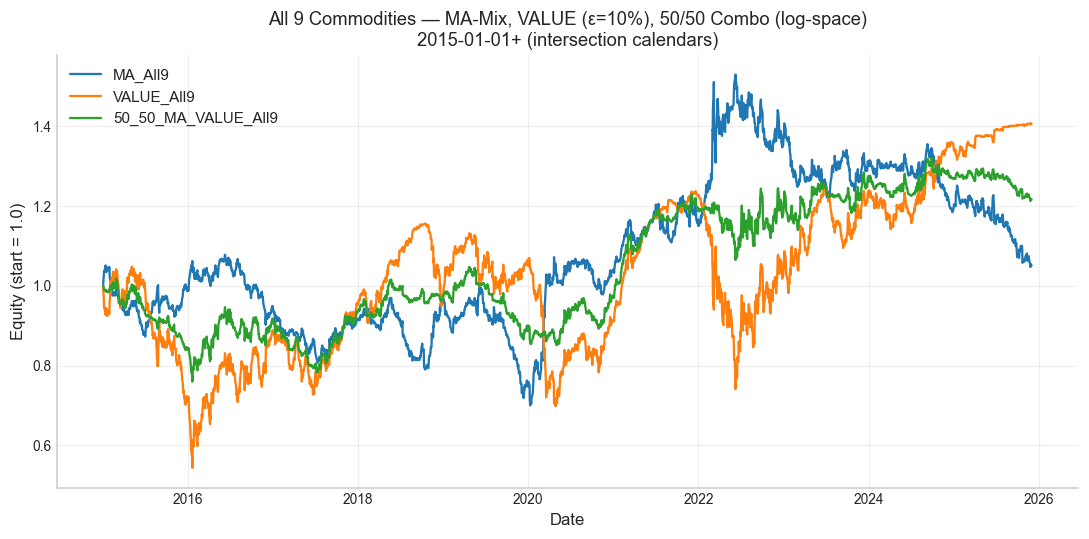

,Ann_Sharpe,Ann_Return,Ann_Vol,Max_DD
MA_All9,0.0343,0.0046,0.1330,-0.3502
VALUE_All9,0.1528,0.0313,0.2050,-0.4812
50_50_MA_VALUE_All9,0.1611,0.0179,0.1113,-0.2534


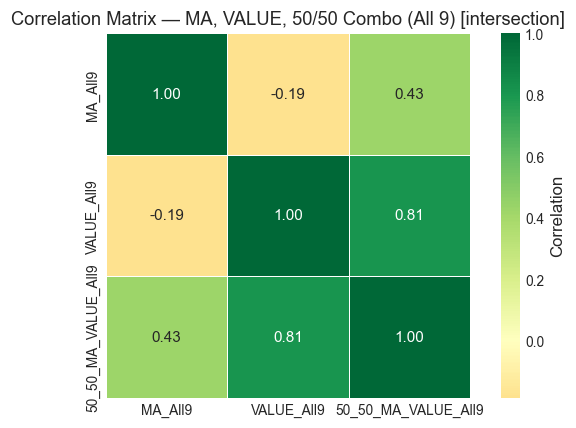

,MA_All9,VALUE_All9,50_50_MA_VALUE_All9
MA_All9,1.0000,-0.1850,0.4270
VALUE_All9,-0.1850,1.0000,0.8100
50_50_MA_VALUE_All9,0.4270,0.8100,1.0000


Sample              Full Sample                         2015-2022          \
Metric               Ann_Return Ann_Vol Sharpe  Max_DD Ann_Return Ann_Vol   
MA_All9                  0.0046  0.1330 0.0343 -0.3502     0.0200  0.1295   
VALUE_All9               0.0313  0.2050 0.1528 -0.4812     0.0290  0.2027   
50_50_MA_VALUE_All9      0.0179  0.1113 0.1611 -0.2534     0.0245  0.1061   

Sample                              2022-2025                          
Metric              Sharpe  Max_DD Ann_Return Ann_Vol  Sharpe  Max_DD  
MA_All9             0.1544 -0.3502    -0.0231  0.1390 -0.1662 -0.3155  
VALUE_All9          0.1432 -0.4812     0.0354  0.2089  0.1695 -0.3959  
50_50_MA_VALUE_All9 0.2310 -0.2534     0.0062  0.1202  0.0512 -0.1190

Saved (intersection) equity curves, log-returns, stats, and correlation matrix to ma_value_50_50_all9_INTERSECTION.xlsx


In [ ]:
# ==============================================================
# 50/50 MA-Mix + VALUE Combo — All 9 Commodities (NO INIT_CAPITAL)
# INTERSECTION EVERYWHERE (STRICT OVERLAP, NO CASH FILL)
#   - Per-commodity equity_line (or cum net_pnl)
#   - Global wealth-proxy shift K chosen on INTERSECTION calendar per leg
#   - Per-leg All-9 portfolios computed on that INTERSECTION calendar (no fillna)
#   - 50/50 combo computed on INTERSECTION of MA_All9 and VALUE_All9 (should match)
#   - Correlations + stats computed on strict overlap (dropna)
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Config ----------
WARMUP_MA_START  = "2010-01-01"
WARMUP_VAL_START = "2010-01-01"
START_DATE       = pd.Timestamp("2015-01-01")
TRADING_DAYS     = 252

# MA leg
MA_PAIRS   = [(1, 5), (5, 20), (10, 60)]
MA_WEIGHTS = None  # equal weights inside momentum()

# VALUE leg
VALUE_MA_WINDOW  = 2520      # 10y
VALUE_VOL_WINDOW = 252       # 1y (kept for signature compat)
VALUE_EPS_BAND   = 0.10      # 10% band

# Universe
NGL_NAMES = ["Propane", "Ethane", "Butane"]
SIX_PACK  = ["WTI", "Brent", "ULSD", "RBOB", "Natgas", "Gasoil"]
ALL_NAMES = sorted(set(NGL_NAMES + SIX_PACK))


def ann_stats_from_logret(lr: pd.Series):
    lr = lr.replace([np.inf, -np.inf], np.nan).dropna()
    if len(lr) < 2:
        return np.nan, np.nan, np.nan
    ann_ret = lr.mean() * TRADING_DAYS                 # annualized mean LOG return
    ann_vol = lr.std(ddof=0) * np.sqrt(TRADING_DAYS)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    return ann_ret, ann_vol, sharpe


def slice_period(s: pd.Series, start=None, end=None):
    if start is not None:
        s = s.loc[s.index >= start]
    if end is not None:
        s = s.loc[s.index <= end]
    return s


def _extract_equity_line(df: pd.DataFrame) -> pd.Series:
    """Prefer equity_line; else cum(net_pnl)."""
    if df is None or df.empty:
        return pd.Series(dtype=float)
    if "equity_line" in df.columns:
        return df["equity_line"].astype(float)
    if "net_pnl" in df.columns:
        return df["net_pnl"].astype(float).cumsum()
    return pd.Series(dtype=float)


def apply_global_K_and_logret(series_dict: dict, tag: str):
    """
    series_dict: {name: DataFrame with 'equity_line' on trade window}
    STRICT INTERSECTION across series:
      - aligns all to common_idx
      - chooses global K on common_idx
      - computes log_ret and equity_index on common_idx
    Returns: (K, common_idx)
    """
    if not series_dict:
        raise ValueError(f"[{tag}] empty dict; nothing to compute.")

    # intersection calendar (trade window)
    common_idx = None
    for df in series_dict.values():
        common_idx = df.index if common_idx is None else common_idx.intersection(df.index)
    common_idx = common_idx.sort_values()

    # align all series to intersection
    for k in list(series_dict.keys()):
        series_dict[k] = series_dict[k].loc[common_idx].copy()

    global_min = min(df["equity_line"].min() for df in series_dict.values())
    K = 1.10 * (-float(global_min)) if global_min < 0 else 1.0

    print(f"[{tag}] n_series={len(series_dict)}")
    print(f"[{tag}] common_idx: {common_idx.min().date()} -> {common_idx.max().date()} (n={len(common_idx)})")
    print(f"[{tag}] global min equity_line on common calendar: {global_min:,.6f}")
    print(f"[{tag}] using shift K: {K:,.6f}")

    for name, df in series_dict.items():
        w = df["equity_line"].astype(float) + K
        if (w <= 0).any():
            raise ValueError(f"[{tag}] {name}: wealth proxy <= 0 even after K; increase buffer")
        df["log_ret"] = np.log(w).diff().fillna(0.0)
        df["equity_index"] = np.exp(df["log_ret"].cumsum())

    return K, common_idx


def build_all9_portfolio_from_leg_intersection(name: str, leg_dict: dict, common_idx: pd.DatetimeIndex):
    """
    leg_dict: {commodity: df with 'log_ret'} already aligned to common_idx
    STRICT INTERSECTION portfolio:
      - NO union calendar
      - NO fillna(0)
      - requires all legs present on all days in common_idx (after leg intersection)
    """
    cols = [c for c in ALL_NAMES if c in leg_dict]
    if not cols:
        return None

    lr_df = pd.concat(
        {c: leg_dict[c]["log_ret"].astype(float).reindex(common_idx) for c in cols},
        axis=1
    ).sort_index()

    # strict: must be fully populated
    if lr_df.isna().any().any():
        bad_cols = lr_df.columns[lr_df.isna().any()].tolist()
        raise ValueError(f"[{name}] NaNs remain on intersection for: {bad_cols}")

    port_lr = lr_df.mean(axis=1)
    port_lr.name = name

    port_eq = np.exp(port_lr.cumsum())
    port_eq.name = name

    ann_ret, ann_vol, sharpe = ann_stats_from_logret(port_lr)
    eq_curve = port_eq / port_eq.iloc[0]
    dd = eq_curve / eq_curve.cummax() - 1.0
    max_dd = float(dd.min()) if len(dd) else np.nan

    return {
        "name": name,
        "equity": port_eq,
        "log_ret": port_lr,
        "Ann_Return": ann_ret,     # annualized mean LOG return (not CAGR)
        "Ann_Vol": ann_vol,
        "Ann_Sharpe": sharpe,
        "Max_DD": max_dd,
        "lr_df": lr_df,
    }


# ==============================================================
# 1) Build MA leg per commodity (ALL_MA)
# ==============================================================
ALL_MA = {}

for commodity, cfg in BASE_ROLL_STYLES.items():
    if commodity not in COMMODITIES or commodity not in ALL_NAMES:
        continue

    ticker, contracts, units, t_cost = COMMODITIES[commodity]

    prices = load_prices(commodity, ticker, normalize=True).loc[WARMUP_MA_START:].sort_index()
    if prices.empty:
        continue

    expiry_cal = load_expiry(ticker)
    style      = cfg["style"]
    front_col  = cfg.get("front_col", "F1")
    next_col   = cfg.get("next_col", "F2")

    rs = RollingStrategy(prices=prices, expiry_calendar=expiry_cal, front_col=front_col, next_col=next_col)

    if style == "eom_ngl":
        rolled_df = rs.equity(style="eom_ngl", t_cost=t_cost,
                              mid_col=cfg.get("mid_col", "F3"),
                              far_col=cfg.get("far_col", "F4"))
    elif style == "eom_mid":
        rolled_df = rs.equity(style="eom_mid", t_cost=t_cost)
    elif style == "eom_dynamic":
        rolled_df = rs.equity(style="eom_dynamic", t_cost=t_cost,
                              third_col=cfg.get("third_col", "F3"))
    elif style == "eom_eom":
        rolled_df = rs.equity(style="eom_eom", t_cost=t_cost,
                              third_col=cfg.get("third_col", "F3"))
    else:
        continue

    rolled_df = rolled_df.sort_index()
    if not all(c in rolled_df.columns for c in ["daily_pnl", "t_cost", "roll_day_flag"]):
        continue

    mom_df = momentum(
        prices=prices,
        rolled_df=rolled_df,
        front_col=front_col,
        ma_pairs=MA_PAIRS,
        weights=MA_WEIGHTS,
        t_cost=t_cost,
        epsilon=0.0,
    )
    if mom_df is None or mom_df.empty:
        continue

    eq = _extract_equity_line(mom_df.sort_index()).loc[START_DATE:].dropna()
    if len(eq) < 2:
        continue

    ALL_MA[commodity] = pd.DataFrame({"equity_line": eq})

K_MA, IDX_MA = apply_global_K_and_logret(ALL_MA, tag="MA")


# ==============================================================
# 2) Build VALUE leg per commodity (ALL_VAL)
# ==============================================================
ALL_VAL = {}

for commodity, cfg in BASE_ROLL_STYLES.items():
    if commodity not in COMMODITIES or commodity not in ALL_NAMES:
        continue

    ticker, contracts, units, t_cost = COMMODITIES[commodity]

    prices_full = load_prices(commodity, ticker, normalize=True).loc[WARMUP_VAL_START:].sort_index()
    if prices_full.empty:
        continue

    expiry_cal = load_expiry(ticker)
    cols = prices_full.columns

    # Force long roll on M12/M13 (fallbacks)
    if "F12" in cols and "F13" in cols:
        roll_front, roll_next = "F12", "F13"
    elif "F12" in cols:
        roll_front = roll_next = "F12"
    elif "F13" in cols:
        roll_front = roll_next = "F13"
    else:
        roll_front = cfg.get("front_col", "F1")
        roll_next  = cfg.get("next_col", "F2")

    rs = RollingStrategy(prices=prices_full, expiry_calendar=expiry_cal, front_col=roll_front, next_col=roll_next)
    rolled_full = rs.equity(style="eom_mid", t_cost=t_cost).sort_index()
    if not all(c in rolled_full.columns for c in ["daily_pnl", "t_cost", "roll_day_flag"]):
        continue

    # VAL_ANCHOR
    if "F12" in cols and "F13" in cols:
        anchor = 0.5 * prices_full["F12"].astype(float) + 0.5 * prices_full["F13"].astype(float)
    elif "F12" in cols:
        anchor = prices_full["F12"].astype(float)
    elif "F13" in cols:
        anchor = prices_full["F13"].astype(float)
    else:
        anchor = prices_full[roll_front].astype(float)

    anchor = anchor.reindex(rolled_full.index).ffill()
    if anchor.dropna().empty:
        continue

    prices_val = pd.DataFrame({"VAL_ANCHOR": anchor})

    val_df = value(
        prices=prices_val,
        rolled_df=rolled_full,
        front_col="VAL_ANCHOR",
        long_ma=VALUE_MA_WINDOW,
        vol_window=VALUE_VOL_WINDOW,
        epsilon_factor=VALUE_EPS_BAND,
        t_cost=t_cost,
    )
    if val_df is None or val_df.empty:
        continue

    eq = _extract_equity_line(val_df.sort_index()).loc[START_DATE:].dropna()
    if len(eq) < 2:
        continue

    ALL_VAL[commodity] = pd.DataFrame({"equity_line": eq})

K_VAL, IDX_VAL = apply_global_K_and_logret(ALL_VAL, tag="VAL")


# ==============================================================
# 3) Build All-9 MA portfolio, All-9 VALUE portfolio, 50/50 combo (LOG)
#    STRICT INTERSECTION (NO fillna(0))
# ==============================================================
ma_port  = build_all9_portfolio_from_leg_intersection("MA_All9", ALL_MA, IDX_MA)
val_port = build_all9_portfolio_from_leg_intersection("VALUE_All9", ALL_VAL, IDX_VAL)
if (ma_port is None) or (val_port is None):
    raise RuntimeError("Missing MA or VALUE portfolio for All 9 commodities.")

# Align and combine in LOG space (strict overlap between MA_All9 and VALUE_All9)
idx = ma_port["log_ret"].index.intersection(val_port["log_ret"].index).sort_values()
ma_lr  = ma_port["log_ret"].reindex(idx)
val_lr = val_port["log_ret"].reindex(idx)

if ma_lr.isna().any() or val_lr.isna().any():
    raise ValueError("[COMBO] NaNs found on intersection between MA_All9 and VALUE_All9; check calendars.")

combo_lr = 0.5 * ma_lr + 0.5 * val_lr
combo_lr.name = "50_50_MA_VALUE_All9"
combo_eq = np.exp(combo_lr.cumsum())
combo_eq.name = combo_lr.name

ann_ret_c, ann_vol_c, sharpe_c = ann_stats_from_logret(combo_lr)
eq_curve_c = combo_eq / combo_eq.iloc[0]
dd_c = eq_curve_c / eq_curve_c.cummax() - 1.0
max_dd_c = float(dd_c.min()) if len(dd_c) else np.nan

combo_port = {
    "name": combo_lr.name,
    "equity": combo_eq,
    "log_ret": combo_lr,
    "Ann_Return": ann_ret_c,
    "Ann_Vol": ann_vol_c,
    "Ann_Sharpe": sharpe_c,
    "Max_DD": max_dd_c,
}


# ==============================================================
# 4) Plot MA, VALUE, COMBO
# ==============================================================
plt.figure(figsize=(10, 5))
common_idx = ma_port["equity"].index.intersection(val_port["equity"].index).intersection(combo_eq.index)

plt.plot(common_idx, ma_port["equity"].reindex(common_idx),  label=ma_port["name"])
plt.plot(common_idx, val_port["equity"].reindex(common_idx), label=val_port["name"])
plt.plot(common_idx, combo_eq.reindex(common_idx),           label=combo_port["name"])

plt.title(
    f"All 9 Commodities — MA-Mix, VALUE (ε={VALUE_EPS_BAND:.0%}), 50/50 Combo (log-space)\n"
    f"{START_DATE.date()}+ (intersection calendars)"
)
plt.xlabel("Date")
plt.ylabel("Equity (start = 1.0)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Metrics table
metrics_df = pd.DataFrame({
    ma_port["name"]: {
        "Ann_Sharpe": ma_port["Ann_Sharpe"],
        "Ann_Return": ma_port["Ann_Return"],
        "Ann_Vol":    ma_port["Ann_Vol"],
        "Max_DD":     ma_port["Max_DD"],
    },
    val_port["name"]: {
        "Ann_Sharpe": val_port["Ann_Sharpe"],
        "Ann_Return": val_port["Ann_Return"],
        "Ann_Vol":    val_port["Ann_Vol"],
        "Max_DD":     val_port["Max_DD"],
    },
    combo_port["name"]: {
        "Ann_Sharpe": combo_port["Ann_Sharpe"],
        "Ann_Return": combo_port["Ann_Return"],
        "Ann_Vol":    combo_port["Ann_Vol"],
        "Max_DD":     combo_port["Max_DD"],
    },
}).T
display(metrics_df.round(4))


# ==============================================================
# 5) Correlation matrix of portfolio log-returns (STRICT OVERLAP)
# ==============================================================
logret_portfolios = pd.DataFrame({
    ma_port["name"]:     ma_port["log_ret"],
    val_port["name"]:    val_port["log_ret"],
    combo_port["name"]:  combo_port["log_ret"],
}).dropna(how="any")  # strict overlap

corr_mat = logret_portfolios.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_mat,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Correlation"},
    square=True,
    linewidths=0.5,
)
plt.title("Correlation Matrix — MA, VALUE, 50/50 Combo (All 9) [intersection]")
plt.tight_layout()
plt.show()
display(corr_mat.round(3))


# ==============================================================
# 6) Multi-period stats + Excel export (LOG-space, STRICT)
# ==============================================================
equity_df = pd.concat(
    {
        ma_port["name"]:    ma_port["equity"].astype(float),
        val_port["name"]:   val_port["equity"].astype(float),
        combo_port["name"]: combo_port["equity"].astype(float),
    },
    axis=1
).sort_index()
equity_df.index.name = "Date"

SUB_PERIODS = {
    "Full Sample": (None, None),
    "2015-2022":   (pd.Timestamp("2015-01-01"), pd.Timestamp("2021-12-31")),
    "2022-2025":   (pd.Timestamp("2022-01-01"), None),
}

def stats_for_period_from_lr(lr: pd.Series, start, end):
    sub = slice_period(lr, start, end).replace([np.inf, -np.inf], np.nan).dropna()
    ann_ret, ann_vol, sharpe = ann_stats_from_logret(sub)
    if sub.empty:
        return np.nan, np.nan, np.nan, np.nan
    eq = np.exp(sub.cumsum())
    eq = eq / eq.iloc[0]
    dd = eq / eq.cummax() - 1.0
    max_dd = float(dd.min()) if len(dd) else np.nan
    return ann_ret, ann_vol, sharpe, max_dd

cols = pd.MultiIndex.from_product(
    [list(SUB_PERIODS.keys()), ["Ann_Return", "Ann_Vol", "Sharpe", "Max_DD"]],
    names=["Sample", "Metric"]
)

portfolio_stats = pd.DataFrame(index=list(logret_portfolios.columns), columns=cols, dtype=float)

for name in logret_portfolios.columns:
    lr = logret_portfolios[name].astype(float)
    for per_label, (start, end) in SUB_PERIODS.items():
        ann_ret, ann_vol, sharpe, max_dd = stats_for_period_from_lr(lr, start, end)
        portfolio_stats.loc[name, (per_label, "Ann_Return")] = ann_ret
        portfolio_stats.loc[name, (per_label, "Ann_Vol")]    = ann_vol
        portfolio_stats.loc[name, (per_label, "Sharpe")]     = sharpe
        portfolio_stats.loc[name, (per_label, "Max_DD")]     = max_dd

display(portfolio_stats.round(4))

out_path = "ma_value_50_50_all9_INTERSECTION.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    logret_portfolios.to_excel(writer, sheet_name="LogReturns")
    equity_df.to_excel(writer, sheet_name="Equity_Curves")
    portfolio_stats.to_excel(writer, sheet_name="Portfolio_Stats")
    corr_mat.to_excel(writer, sheet_name="Corr_Matrix")

print(f"Saved (intersection) equity curves, log-returns, stats, and correlation matrix to {out_path}")


## Stat-arb

[StatArb] roll=M12_13, pairs=8


,Spread,Leg_i,Leg_j,Start,End,N_Obs,Beta_(log_j_on_log_i),Coint_tstat,Coint_pval,Coint_Reject_5pct
0,RBOB-Brent,RBOB,Brent,2015-01-02,2025-12-01,2747,0.889670,-4.748018,0.000466,True
1,Butane-RBOB,Butane,RBOB,2015-01-02,2025-12-01,2747,0.721848,-4.519703,0.001136,True
2,Propane-Ethane,Propane,Ethane,2015-01-02,2025-12-01,2746,0.618086,-3.849790,0.011619,True
3,Propane-Butane,Propane,Butane,2015-01-02,2025-12-01,2747,0.959161,-3.336498,0.049909,True
4,ULSD-WTI,ULSD,WTI,2015-01-02,2025-12-01,2747,0.871119,-3.019157,0.105722,False
5,WTI-Brent,WTI,Brent,2015-01-02,2025-12-01,2747,0.990408,-2.714594,0.194374,False
6,Brent-ULSD,Brent,ULSD,2015-01-02,2025-12-01,2747,1.106013,-2.617619,0.229792,False
7,Ethane-Natgas,Ethane,Natgas,2015-01-02,2025-12-01,2746,0.635404,-2.384610,0.332178,False


[STATARB_SPREADS] intersection: 2015-01-02 → 2025-12-01 (n=2,746)
[STATARB_SPREADS] global min pnl_pct on common calendar: -0.584089
[STATARB_SPREADS] common shift K (on pct scale): 0.642498
[STATARB_SPREADS] FINAL strict intersection after diff-drop: n_dates=2,745


,Type,Name,Ann_Return,Ann_Vol,Sharpe
0,Portfolio,EW_Selected_Spreads,0.0693,0.0775,0.8951
1,Spread,RBOB-Brent,0.0624,0.0824,0.7566
2,Spread,WTI-Brent,0.0599,0.0914,0.6548
3,Spread,Ethane-Natgas,0.1030,0.2021,0.5098
4,Spread,Butane-RBOB,0.1394,0.3081,0.4525
5,Spread,Propane-Ethane,0.1459,0.4365,0.3343
6,Spread,ULSD-WTI,0.0381,0.1303,0.2925
7,Spread,Propane-Butane,0.0105,0.1965,0.0534
8,Spread,Brent-ULSD,-0.0046,0.1010,-0.0452


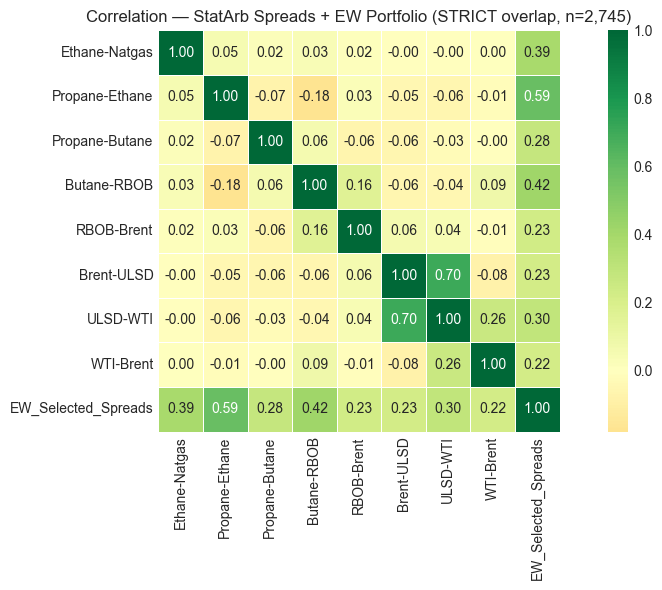

,Ethane-Natgas,Propane-Ethane,Propane-Butane,Butane-RBOB,RBOB-Brent,Brent-ULSD,ULSD-WTI,WTI-Brent,EW_Selected_Spreads
Ethane-Natgas,1.000,0.050,0.018,0.035,0.015,-0.001,-0.000,0.004,0.387
Propane-Ethane,0.050,1.000,-0.073,-0.178,0.026,-0.045,-0.060,-0.014,0.591
Propane-Butane,0.018,-0.073,1.000,0.059,-0.064,-0.058,-0.030,-0.001,0.277
Butane-RBOB,0.035,-0.178,0.059,1.000,0.159,-0.057,-0.044,0.086,0.417
RBOB-Brent,0.015,0.026,-0.064,0.159,1.000,0.060,0.044,-0.011,0.232
Brent-ULSD,-0.001,-0.045,-0.058,-0.057,0.060,1.000,0.701,-0.085,0.227
ULSD-WTI,-0.000,-0.060,-0.030,-0.044,0.044,0.701,1.000,0.263,0.295
WTI-Brent,0.004,-0.014,-0.001,0.086,-0.011,-0.085,0.263,1.000,0.221
EW_Selected_Spreads,0.387,0.591,0.277,0.417,0.232,0.227,0.295,0.221,1.000


Sample              Full Sample                          2015-2022          \
Metric               Ann_Return Ann_Vol  Sharpe  Max_DD Ann_Return Ann_Vol   
Ethane-Natgas            0.1030  0.2021  0.5098 -0.4444     0.0846  0.2309   
Propane-Ethane           0.1459  0.4365  0.3343 -0.5674     0.1550  0.5303   
Propane-Butane           0.0105  0.1965  0.0534 -0.3826    -0.0011  0.2337   
Butane-RBOB              0.1394  0.3081  0.4525 -0.3265     0.1704  0.3735   
RBOB-Brent               0.0624  0.0824  0.7566 -0.1722     0.0829  0.0938   
Brent-ULSD              -0.0046  0.1010 -0.0452 -0.2606     0.0241  0.0864   
ULSD-WTI                 0.0381  0.1303  0.2925 -0.2478     0.0732  0.1359   
WTI-Brent                0.0599  0.0914  0.6548 -0.2457     0.0777  0.1095   
EW_Selected_Spreads      0.0693  0.0775  0.8951 -0.1056     0.0834  0.0903   

Sample                               2022-2025                          
Metric               Sharpe  Max_DD Ann_Return Ann_Vol  Sharpe  Max_DD  
Ethane-Natgas        0.3664 -0.4444     0.1360  0.1358  1.0019 -0.0816  
Propane-Ethane       0.2923 -0.5674     0.1296  0.1667  0.7774 -0.1955  
Propane-Butane      -0.0048 -0.3826     0.0313  0.0995  0.3144 -0.2194  
Butane-RBOB          0.4563 -0.3265     0.0838  0.1224  0.6844 -0.1509  
RBOB-Brent           0.8840 -0.1722     0.0256  0.0566  0.4518 -0.0435  
Brent-ULSD           0.2792 -0.1203    -0.0560  0.1229 -0.4556 -0.2509  
ULSD-WTI             0.5387 -0.2478    -0.0248  0.1196 -0.2069 -0.2015  
WTI-Brent            0.7093 -0.2457     0.0279  0.0428  0.6522 -0.0537  
EW_Selected_Spreads  0.9235 -0.1056     0.0442  0.0463  0.9541 -0.0537

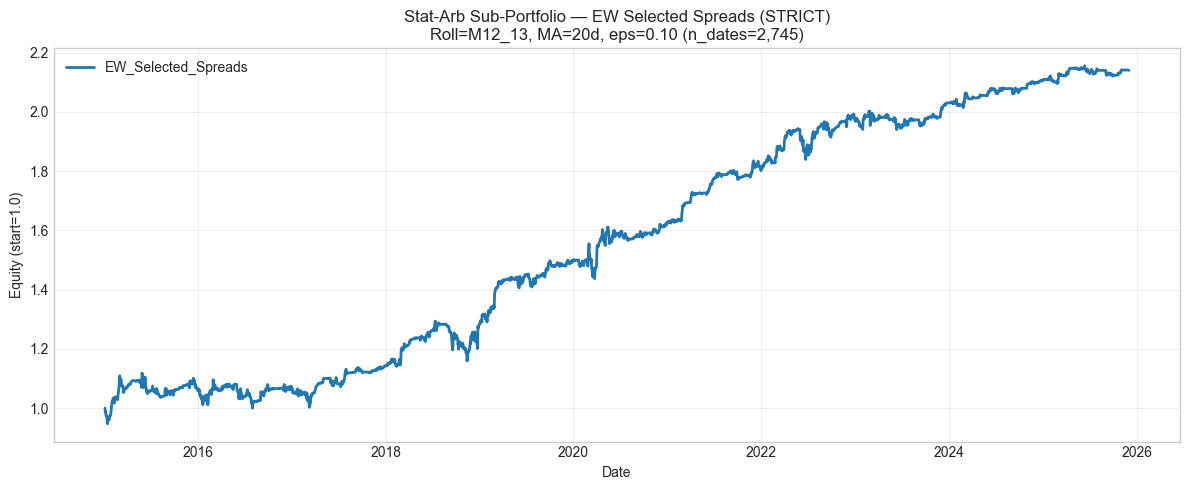

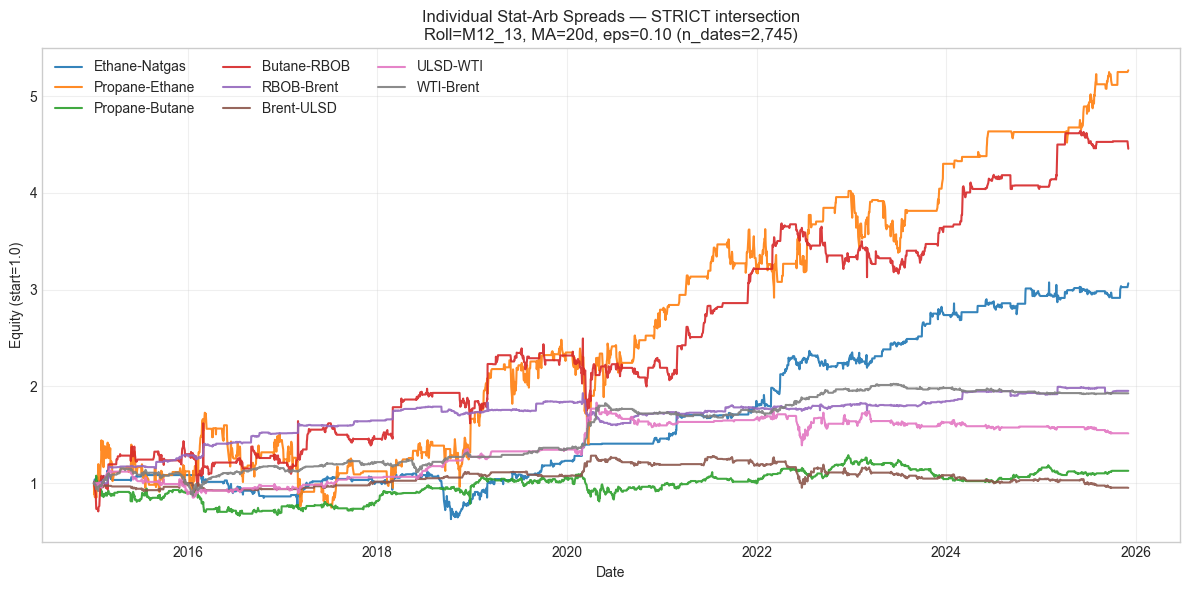

Saved: stat_arb_selected_spreads_STRICT_M12_13.xlsx
[CHECK] FINAL n_dates (strict intersection, logret calendar) = 2,745
[CHECK] wrote scooted sheet: EquityIdx_StartAt1_Scoot (prior bday all 1s)


In [17]:
# =====================================================================
# Stat-Arb Sub-Portfolio: Selected Spreads (EW), STRICT + LOG-REPORTED
# - spreads/signals/PNL come from statistical_arbitrage(prices=..., pure_spread_prices=...)
# - reporting is in log-return space via wealth proxy on normalized PnL (% of capital)
# - STRICT intersection calendar across ALL spreads (after diff)
# - NO fillna(0) anywhere in wrapper (except signal warmup inside stat-arb)
# - Exports include equity curves that START AT 1.0 AND are "scooted back"
#   so prior business day is all 1s (e.g., 2015-01-02=1, 2015-01-05 is first move)
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# 1) Config
# -------------------------------------------------
SELECTED_ROLL_SETUP = "M12_13"   # "Base_short", "M6_7", "M9_10", "M12_13"

SELECTED_PARAMS = {
    "long_ma": 20,
    "vol_window": 20,
    "epsilon_factor": 0.1,
    "t_cost": 0.00,
}

HIST_START  = "2010-01-01"
START_DATE  = pd.Timestamp("2015-01-01")
TRADE_START = START_DATE

TRADING_DAYS = 252

SUB_PERIODS = {
    "Full Sample": (None, None),
    "2015-2022":   (pd.Timestamp("2015-01-01"), pd.Timestamp("2021-12-31")),
    "2022-2025":   (pd.Timestamp("2022-01-01"), None),
}

ROLL_SETUPS = {
    "Base_short": {"kind": "base"},
    "M6_7":       {"kind": "tenor", "front": "F6",  "next": "F7"},
    "M9_10":      {"kind": "tenor", "front": "F9",  "next": "F10"},
    "M12_13":     {"kind": "tenor", "front": "F12", "next": "F13"},
}

if SELECTED_ROLL_SETUP not in ROLL_SETUPS:
    raise ValueError(f"Unknown roll setup '{SELECTED_ROLL_SETUP}'")
setup_cfg = ROLL_SETUPS[SELECTED_ROLL_SETUP]

raw_pairs = [
    ("Ethane", "Natgas"),
    ("Propane", "Ethane"),
    ("Propane", "Butane"),
    ("Butane", "RBOB"),
    ("RBOB", "Brent"),
    ("Brent", "ULSD"),
    ("ULSD", "WTI"),
    ("WTI", "Brent"),
]

# -------------------------------------------------
# 2) Helpers
# -------------------------------------------------
def _safe_sheet(name: str) -> str:
    bad = [":", "\\", "/", "?", "*", "[", "]"]
    for ch in bad:
        name = name.replace(ch, "_")
    return name[:31]

def _strict_intersection_index(dfs: dict[str, pd.DataFrame], col: str) -> pd.DatetimeIndex:
    common = None
    for df in dfs.values():
        if col not in df.columns:
            raise KeyError(f"Missing '{col}' in one of the legs.")
        idx = df.index.dropna()
        common = idx if common is None else common.intersection(idx)
    if common is None:
        return pd.DatetimeIndex([])
    return common.sort_values()

def ann_stats_from_logret(lr: pd.Series):
    lr = lr.replace([np.inf, -np.inf], np.nan).dropna()
    if len(lr) < 2:
        return np.nan, np.nan, np.nan
    ann_ret = lr.mean() * TRADING_DAYS
    ann_vol = lr.std(ddof=0) * np.sqrt(TRADING_DAYS)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    return ann_ret, ann_vol, sharpe

def slice_period(s: pd.Series, start=None, end=None):
    if start is not None:
        s = s.loc[s.index >= start]
    if end is not None:
        s = s.loc[s.index <= end]
    return s

def max_dd_from_logret(lr: pd.Series):
    lr = lr.replace([np.inf, -np.inf], np.nan).dropna()
    if len(lr) < 2:
        return np.nan
    eq = np.exp(lr.cumsum())
    eq = eq / eq.iloc[0]
    dd = eq / eq.cummax() - 1.0
    return float(dd.min())

def time_split_metrics_from_series_dict(series_dict, sub_periods=SUB_PERIODS):
    metric_labels = ["Ann_Return", "Ann_Vol", "Sharpe", "Max_DD"]
    cols = pd.MultiIndex.from_product(
        [list(sub_periods.keys()), metric_labels],
        names=["Sample", "Metric"],
    )
    out = pd.DataFrame(index=list(series_dict.keys()), columns=cols, dtype=float)

    for name, lr in series_dict.items():
        lr = lr.astype(float).replace([np.inf, -np.inf], np.nan)
        for per_label, (start, end) in sub_periods.items():
            sub = slice_period(lr, start, end).dropna()
            ann_ret, ann_vol, sharpe = ann_stats_from_logret(sub)
            mdd = max_dd_from_logret(sub)
            out.loc[name, (per_label, "Ann_Return")] = ann_ret
            out.loc[name, (per_label, "Ann_Vol")]    = ann_vol
            out.loc[name, (per_label, "Sharpe")]     = sharpe
            out.loc[name, (per_label, "Max_DD")]     = mdd
    return out

def _extract_equity_line(df: pd.DataFrame) -> pd.Series:
    """Prefer equity_line; else cum(net_pnl)."""
    if df is None or df.empty:
        return pd.Series(dtype=float)
    if "equity_line" in df.columns:
        return df["equity_line"].astype(float)
    if "net_pnl" in df.columns:
        return df["net_pnl"].astype(float).cumsum()
    return pd.Series(dtype=float)

def _prev_business_day(ts: pd.Timestamp) -> pd.Timestamp:
    # robust: if ts is Monday, prev is Friday
    return pd.bdate_range(end=ts, periods=2)[0]

def _start1_from_logret_and_scoot(lr: pd.Series) -> pd.Series:
    """
    Build equity index from log returns, normalize to 1.0 at the FIRST lr date,
    then prepend prior business day as 1.0.

    After this:
      prev_bday = 1.0
      first lr date = 1.0
      next dates reflect realized returns
    """
    lr = lr.astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    if lr.empty:
        return lr

    eq = np.exp(lr.cumsum())
    eq = eq / eq.iloc[0]  # first lr date becomes 1.0

    first_date = eq.index[0]
    prev_bday = _prev_business_day(first_date)

    # prepend base row
    eq2 = pd.concat([pd.Series([1.0], index=pd.DatetimeIndex([prev_bday])), eq]).sort_index()
    return eq2

def _start1_wide_from_logret_wide_and_scoot(logret_wide: pd.DataFrame) -> pd.DataFrame:
    """
    Column-wise _start1_from_logret_and_scoot, then strict inner-join intersection
    so the sheet is perfectly rectangular.
    """
    pieces = {}
    for c in logret_wide.columns:
        pieces[c] = _start1_from_logret_and_scoot(logret_wide[c])
    out = pd.concat(pieces, axis=1, join="inner").sort_index()
    return out

def apply_common_K_on_normalized_pnl_strict(
    leg_dict: dict[str, pd.DataFrame],
    tag: str,
    capital_per_spread: float,
    buffer: float = 1.10,
):
    """
    Common-K log reporting but on NORMALIZED cumPnL:
      pnl_pct = equity_line / capital_per_spread
      wealth  = 1 + K + pnl_pct
      log_ret = log(wealth).diff()

    STRICT:
      - intersect calendar on equity_line first
      - compute single K from global min of pnl_pct on that calendar
      - compute log_ret/equity_index
      - drop first diff NaN everywhere
      - re-intersect after diff-drop
    """
    if not leg_dict:
        raise ValueError(f"[{tag}] empty dict.")
    if capital_per_spread <= 0:
        raise ValueError("capital_per_spread must be positive.")

    common_idx = _strict_intersection_index(leg_dict, "equity_line")
    if len(common_idx) < 2:
        raise RuntimeError(f"[{tag}] common_idx too short after intersection.")

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx].copy()

    # normalize cumPnL into "pct of spread capital"
    for name, df in leg_dict.items():
        df["pnl_pct"] = df["equity_line"].astype(float) / float(capital_per_spread)

    global_min = min(float(df["pnl_pct"].min()) for df in leg_dict.values())
    K = buffer * (-global_min) if global_min < 0 else 0.0

    print(f"[{tag}] intersection: {common_idx.min().date()} → {common_idx.max().date()} (n={len(common_idx):,})")
    print(f"[{tag}] global min pnl_pct on common calendar: {global_min:,.6f}")
    print(f"[{tag}] common shift K (on pct scale): {K:,.6f}")

    for name, df in leg_dict.items():
        wealth = 1.0 + K + df["pnl_pct"].astype(float)
        if (wealth <= 0).any():
            raise ValueError(f"[{tag}] {name}: wealth <= 0; increase buffer or check pnl scale.")
        lr = np.log(wealth).diff()
        df["log_ret"] = lr

        eq = np.exp(lr.cumsum())
        df["equity_index"] = eq / eq.iloc[0]   # starts at 1 (on first lr date)

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].dropna(subset=["log_ret"])

    common_idx2 = _strict_intersection_index(leg_dict, "log_ret")
    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx2].copy()

    print(f"[{tag}] FINAL strict intersection after diff-drop: n_dates={len(common_idx2):,}")
    return leg_dict, K, common_idx2

def _format_dates_no_time_in_excel(writer, sheet_name: str, date_col: int = 1):
    """
    Format the first column as YYYY-MM-DD in Excel.
    date_col is 1-indexed (A=1).
    """
    from openpyxl.styles import numbers
    ws = writer.book[sheet_name]
    # skip header row
    for r in range(2, ws.max_row + 1):
        cell = ws.cell(row=r, column=date_col)
        cell.number_format = "yyyy-mm-dd"

# -------------------------------------------------
# 3) Build rolled legs + PURE prices for signals
# -------------------------------------------------
if "_build_legs_for_roll_setup" not in globals():
    raise NameError(
        "Missing _build_legs_for_roll_setup(). "
        "Run/Import the cell that defines it (the one that uses BASE_ROLL_STYLES / COMMODITIES / RollingStrategy)."
    )

rolled_legs, prices_all = _build_legs_for_roll_setup(SELECTED_ROLL_SETUP, setup_cfg)

selected_pairs = [(i, j) for (i, j) in raw_pairs if (i in rolled_legs) and (j in rolled_legs)]
if not selected_pairs:
    raise RuntimeError("No valid pairs from selection found in rolled_legs.")
print(f"[StatArb] roll={SELECTED_ROLL_SETUP}, pairs={len(selected_pairs)}")

# -------------------------------------------------
# 3B) Cointegration test per spread (2015-01-01 → end)
#     Engle–Granger test on log prices
# -------------------------------------------------
try:
    from statsmodels.tsa.stattools import coint
    import statsmodels.api as sm
except Exception as e:
    raise ImportError(
        "Cointegration block requires statsmodels. "
        "Install via: pip install statsmodels"
    ) from e

COINT_START = pd.Timestamp("2015-01-01")

def _coint_test_pair(prices_df: pd.DataFrame, x_name: str, y_name: str, start=COINT_START):
    """
    Engle–Granger cointegration test between log(y) and log(x):
      y = alpha + beta * x + eps
    Returns: beta, pval, tstat, nobs, start/end
    """
    tmp = prices_df[[x_name, y_name]].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    tmp = tmp.loc[tmp.index >= start].dropna()
    if tmp.shape[0] < 100:
        return {"nobs": int(tmp.shape[0]), "beta": np.nan, "tstat": np.nan, "pval": np.nan,
                "start": tmp.index.min() if len(tmp) else pd.NaT,
                "end": tmp.index.max() if len(tmp) else pd.NaT}

    lx = np.log(tmp[x_name])
    ly = np.log(tmp[y_name])

    # OLS to get hedge ratio beta (ly ~ alpha + beta*lx)
    X = sm.add_constant(lx.values)
    res = sm.OLS(ly.values, X).fit()
    beta = float(res.params[1])

    # Engle–Granger cointegration test (includes intercept by default: trend="c")
    tstat, pval, _ = coint(ly.values, lx.values, trend="c")

    return {
        "nobs": int(tmp.shape[0]),
        "beta": beta,
        "tstat": float(tstat),
        "pval": float(pval),
        "start": tmp.index.min(),
        "end": tmp.index.max(),
    }

cointegration_rows = []
for (c_i, c_j) in selected_pairs:
    spread_name = f"{c_i}-{c_j}"

    # Use the same "pure" price panel you feed into stat-arb (prices_all is already built above)
    # We test log(c_i) vs log(c_j). Choice of which is x/y affects beta sign/scale but not p-value materially.
    stats_ij = _coint_test_pair(prices_all[[c_i, c_j]].copy(), x_name=c_i, y_name=c_j, start=COINT_START)

    cointegration_rows.append({
        "Spread": spread_name,
        "Leg_i": c_i,
        "Leg_j": c_j,
        "Start": stats_ij["start"],
        "End": stats_ij["end"],
        "N_Obs": stats_ij["nobs"],
        "Beta_(log_j_on_log_i)": stats_ij["beta"],   # log(leg_j) ~ alpha + beta*log(leg_i)
        "Coint_tstat": stats_ij["tstat"],
        "Coint_pval": stats_ij["pval"],
        "Coint_Reject_5pct": (stats_ij["pval"] < 0.05) if np.isfinite(stats_ij["pval"]) else False,
    })

cointegration_df = (
    pd.DataFrame(cointegration_rows)
      .sort_values(["Coint_pval", "Coint_tstat"], ascending=[True, True])
      .reset_index(drop=True)
)

display(cointegration_df)


# -------------------------------------------------
# 4) Run stat-arb per spread, collect equity_line per spread
# -------------------------------------------------
SPREAD_LEGS = {}
spread_meta = []

for (c_i, c_j) in selected_pairs:
    spread_name = f"{c_i}-{c_j}"

    sub_rolled = {c_i: rolled_legs[c_i], c_j: rolled_legs[c_j]}
    pure_prices_2   = prices_all[[c_i, c_j]].astype(float).copy()
    prices_for_exec = prices_all[[c_i, c_j]].astype(float).copy()

    sa_df = statistical_arbitrage(
        rolled_legs=sub_rolled,
        prices=prices_for_exec,
        pairs=[(c_i, c_j)],
        long_ma=SELECTED_PARAMS["long_ma"],
        vol_window=SELECTED_PARAMS["vol_window"],
        epsilon_factor=SELECTED_PARAMS["epsilon_factor"],
        t_cost=SELECTED_PARAMS["t_cost"],
        pure_spread_prices=pure_prices_2,
    ).sort_index()

    sa_df = sa_df.loc[sa_df.index >= TRADE_START].copy()
    if sa_df.empty:
        print(f"[SKIP] {spread_name}: empty after TRADE_START")
        continue

    eq_line = _extract_equity_line(sa_df).replace([np.inf, -np.inf], np.nan).dropna()
    if eq_line.size < 3:
        print(f"[SKIP] {spread_name}: too short equity_line")
        continue

    SPREAD_LEGS[spread_name] = pd.DataFrame({"equity_line": eq_line})
    spread_meta.append({
        "Spread": spread_name,
        "Leg_i": c_i,
        "Leg_j": c_j,
        "n_raw_dates": int(eq_line.shape[0]),
        "start": eq_line.index.min(),
        "end": eq_line.index.max(),
    })

if len(SPREAD_LEGS) < 2:
    raise RuntimeError("Need at least 2 valid spreads to form sub-portfolio.")

# -------------------------------------------------
# 5) STRICT reporting transform (common K on normalized pnl_pct)
# -------------------------------------------------
CAPITAL_PER_SPREAD = 10_000_000.0 / len(SPREAD_LEGS)

SPREAD_LEGS, K_SPREAD, common_idx = apply_common_K_on_normalized_pnl_strict(
    SPREAD_LEGS,
    tag="STATARB_SPREADS",
    capital_per_spread=CAPITAL_PER_SPREAD,
    buffer=1.10,
)

# -------------------------------------------------
# 6) EW portfolio on STRICT intersection
# -------------------------------------------------
spread_lr = pd.concat(
    {n: df["log_ret"].astype(float) for n, df in SPREAD_LEGS.items()},
    axis=1, join="inner"
).dropna(how="any").sort_index()

if spread_lr.isna().any().any():
    raise ValueError("NaNs remain in spread logret after strict intersection (should not happen).")

ew_port_lr = spread_lr.mean(axis=1)
ew_port_lr.name = "EW_Selected_Spreads"

ew_port_eq = np.exp(ew_port_lr.cumsum())
ew_port_eq = ew_port_eq / ew_port_eq.iloc[0]
ew_port_eq.name = ew_port_lr.name

# -------------------------------------------------
# 7) Metrics
# -------------------------------------------------
rows = []
for name in spread_lr.columns:
    ann_ret, ann_vol, sharpe = ann_stats_from_logret(spread_lr[name])
    rows.append({"Type": "Spread", "Name": name, "Ann_Return": ann_ret, "Ann_Vol": ann_vol, "Sharpe": sharpe})

ann_ret_p, ann_vol_p, sharpe_p = ann_stats_from_logret(ew_port_lr)
rows.append({"Type": "Portfolio", "Name": ew_port_lr.name, "Ann_Return": ann_ret_p, "Ann_Vol": ann_vol_p, "Sharpe": sharpe_p})

metrics_df = pd.DataFrame(rows).sort_values(["Type", "Sharpe"], ascending=[True, False]).reset_index(drop=True)
display(metrics_df.round(4))

# -------------------------------------------------
# 8) Correlation matrix
# -------------------------------------------------
corr_df = spread_lr.copy()
corr_df[ew_port_lr.name] = ew_port_lr
corr_mat = corr_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_mat, annot=True, fmt=".2f", center=0, cmap="RdYlGn", square=True, linewidths=0.5)
plt.title(f"Correlation — StatArb Spreads + EW Portfolio (STRICT overlap, n={len(corr_df):,})")
plt.tight_layout()
plt.show()
display(corr_mat.round(3))

# -------------------------------------------------
# 9) Time-split stats
# -------------------------------------------------
series_for_stats = {n: spread_lr[n] for n in spread_lr.columns}
series_for_stats[ew_port_lr.name] = ew_port_lr
time_stats = time_split_metrics_from_series_dict(series_for_stats, sub_periods=SUB_PERIODS)
display(time_stats.round(4))

# -------------------------------------------------
# 10) Plots (unchanged)
# -------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(ew_port_eq.index, ew_port_eq.values, linewidth=2, label=ew_port_lr.name)
plt.title(
    f"Stat-Arb Sub-Portfolio — EW Selected Spreads (STRICT)\n"
    f"Roll={SELECTED_ROLL_SETUP}, MA={SELECTED_PARAMS['long_ma']}d, eps={SELECTED_PARAMS['epsilon_factor']:.2f} "
    f"(n_dates={len(ew_port_lr):,})"
)
plt.xlabel("Date"); plt.ylabel("Equity (start=1.0)"); plt.grid(alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 6))
for n in spread_lr.columns:
    eq = np.exp(spread_lr[n].cumsum())
    eq = eq / eq.iloc[0]
    plt.plot(eq.index, eq.values, label=n, alpha=0.9)
plt.title(
    f"Individual Stat-Arb Spreads — STRICT intersection\n"
    f"Roll={SELECTED_ROLL_SETUP}, MA={SELECTED_PARAMS['long_ma']}d, eps={SELECTED_PARAMS['epsilon_factor']:.2f} "
    f"(n_dates={len(spread_lr):,})"
)
plt.xlabel("Date"); plt.ylabel("Equity (start=1.0)"); plt.grid(alpha=0.3); plt.legend(ncol=3)
plt.tight_layout(); plt.show()

# -------------------------------------------------
# 11) Excel export (TRUE StartAt1 + Scooted + Date format)
# -------------------------------------------------
out_path = f"stat_arb_selected_spreads_STRICT_{SELECTED_ROLL_SETUP}.xlsx"

equity_line_wide = pd.concat(
    {n: df["equity_line"].astype(float) for n, df in SPREAD_LEGS.items()},
    axis=1, join="inner"
).sort_index()

pnl_pct_wide = pd.concat(
    {n: df["pnl_pct"].astype(float) for n, df in SPREAD_LEGS.items()},
    axis=1, join="inner"
).sort_index()

logret_wide = pd.concat(
    {n: df["log_ret"].astype(float) for n, df in SPREAD_LEGS.items()},
    axis=1, join="inner"
).sort_index()

eqidx_wide = pd.concat(
    {n: df["equity_index"].astype(float) for n, df in SPREAD_LEGS.items()},
    axis=1, join="inner"
).sort_index()

# --- THE SHEET YOU WANT ---
# Build equity index from log_ret and SCOOT back one business day so prior bday is all 1s.
eqidx_start1_scoot_wide = _start1_wide_from_logret_wide_and_scoot(logret_wide)

# Portfolio: same convention
portfolio_eq_start1_scoot = _start1_from_logret_and_scoot(ew_port_lr)
portfolio_eq_start1_scoot.name = ew_port_lr.name

logret_ports = logret_wide.copy()
logret_ports[ew_port_lr.name] = ew_port_lr

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    pd.DataFrame(spread_meta).to_excel(writer, sheet_name="Spread_Meta", index=False)

    # Raw accounting curves
    equity_line_wide.to_excel(writer, sheet_name="EquityLine_Wide_PnL$")
    pnl_pct_wide.to_excel(writer, sheet_name="PnL_Pct_Wide")

    # Reporting curves
    logret_wide.to_excel(writer, sheet_name="LogRet_Wide")

    # Original (starts at first lr date, e.g. 1/5)
    eqidx_wide.to_excel(writer, sheet_name="EquityIdx_Wide_StartAt1")

    # NEW: scooted so prior business day is base 1.0 row (e.g. 1/2 all 1s)
    eqidx_start1_scoot_wide.to_excel(writer, sheet_name="EquityIdx_StartAt1_Scoot")

    # Portfolio
    pd.DataFrame({ew_port_lr.name: ew_port_lr}).to_excel(writer, sheet_name="Portfolio_LogRet")
    pd.DataFrame({portfolio_eq_start1_scoot.name: portfolio_eq_start1_scoot}).to_excel(
        writer, sheet_name="Portfolio_Equity_StartAt1_Scoot"
    )

    # Diagnostics / stats
    metrics_df.to_excel(writer, sheet_name="Summary_Metrics", index=False)
    time_stats.to_excel(writer, sheet_name="TimeSplit_Stats")
    corr_mat.to_excel(writer, sheet_name="Corr_Matrix")

    cointegration_df.to_excel(writer, sheet_name="Cointegration_2015p", index=False)
    _format_dates_no_time_in_excel(writer, "Cointegration_2015p", date_col=1)  # formats "Start" column


    # Per-spread sheets (include scooted equity)
    for n, df in SPREAD_LEGS.items():
        out = df[["equity_line", "pnl_pct", "log_ret", "equity_index"]].copy()
        out["equity_index_start1_scoot"] = _start1_from_logret_and_scoot(out["log_ret"])
        out.index.name = "Date"
        out.to_excel(writer, sheet_name=_safe_sheet(f"Spread_{n}"))

    # Format date columns nicely (no time)
    for sh in [
        "EquityLine_Wide_PnL$",
        "PnL_Pct_Wide",
        "LogRet_Wide",
        "EquityIdx_Wide_StartAt1",
        "EquityIdx_StartAt1_Scoot",
        "Portfolio_LogRet",
        "Portfolio_Equity_StartAt1_Scoot",
        "TimeSplit_Stats",
        "Corr_Matrix",
    ]:
        _format_dates_no_time_in_excel(writer, sh, date_col=1)

print(f"Saved: {out_path}")
print(f"[CHECK] FINAL n_dates (strict intersection, logret calendar) = {len(common_idx):,}")
print("[CHECK] wrote scooted sheet: EquityIdx_StartAt1_Scoot (prior bday all 1s)")


## EW + Correlation Across Portfolios

[STATARB_SPREADS] intersection: 2015-01-02 → 2025-12-01 (n=2,746)
[STATARB_SPREADS] global min pnl_pct on common calendar: -0.584089
[STATARB_SPREADS] common shift K (pct scale): 0.642498
[STATARB_SPREADS] FINAL strict intersection after diff-drop: n_dates=2,745


,Strategy,n_dates,start,end
0,All9_Value,2818,2015-01-02,2025-12-01
1,NGL_Momentum,2747,2015-01-02,2025-12-01
2,SixPack_Carry,2818,2015-01-02,2025-12-01
3,SixPack_Momentum,2818,2015-01-02,2025-12-01
4,StatArb_VirtualBarrels,2745,2015-01-05,2025-12-01


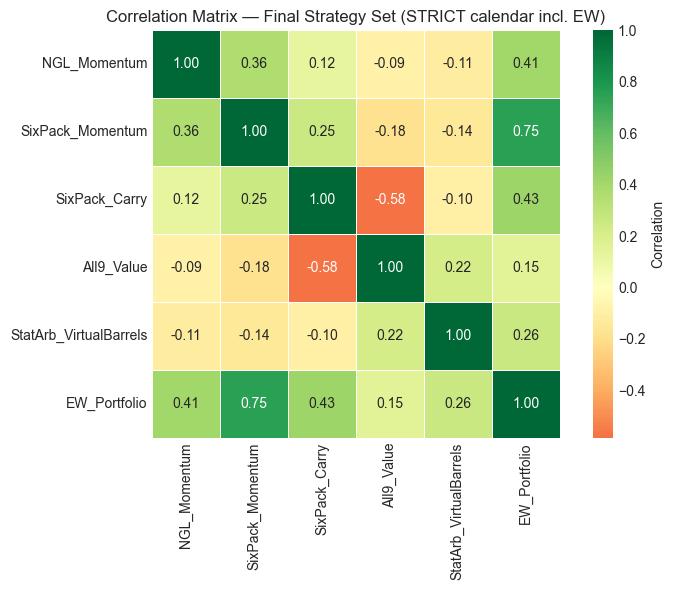

,NGL_Momentum,SixPack_Momentum,SixPack_Carry,All9_Value,StatArb_VirtualBarrels,EW_Portfolio
NGL_Momentum,1.000,0.361,0.122,-0.090,-0.114,0.407
SixPack_Momentum,0.361,1.000,0.254,-0.182,-0.140,0.747
SixPack_Carry,0.122,0.254,1.000,-0.585,-0.097,0.429
All9_Value,-0.090,-0.182,-0.585,1.000,0.217,0.146
StatArb_VirtualBarrels,-0.114,-0.140,-0.097,0.217,1.000,0.261
EW_Portfolio,0.407,0.747,0.429,0.146,0.261,1.000


,Ann_Sharpe,Ann_Return,Ann_Vol,Cum_Return,Max_DD
NGL_Momentum,0.9930,0.0444,0.0437,0.5972,-0.0633
SixPack_Momentum,0.0140,0.0024,0.1688,0.0156,-0.4238
SixPack_Carry,0.4002,0.0615,0.1492,0.8917,-0.2080
All9_Value,0.2634,0.0379,0.1414,0.5216,-0.3260
StatArb_VirtualBarrels,0.9026,0.0724,0.0774,1.1662,-0.1056
EW_Portfolio,0.9852,0.0504,0.0499,0.7073,-0.0786


Sample                 Full Sample                          2015-2022          \
Metric                  Ann_Return Ann_Vol  Sharpe  Max_DD Ann_Return Ann_Vol   
NGL_Momentum                0.0440  0.0437  0.9846 -0.0633     0.0583  0.0464   
SixPack_Momentum            0.0014  0.1688  0.0084 -0.4238     0.0115  0.1595   
SixPack_Carry               0.0603  0.1491  0.3927 -0.2080     0.0652  0.1508   
All9_Value                  0.0393  0.1413  0.2729 -0.3260     0.0375  0.1351   
StatArb_VirtualBarrels      0.0736  0.0774  0.9179 -0.1056     0.0898  0.0902   
EW_Portfolio                0.0504  0.0499  0.9850 -0.0786     0.0588  0.0519   

Sample                                  2022-2025                          
Metric                  Sharpe  Max_DD Ann_Return Ann_Vol  Sharpe  Max_DD  
NGL_Momentum            1.2225 -0.0633     0.0163  0.0381  0.4231 -0.0618  
SixPack_Momentum        0.0716 -0.4238    -0.0159  0.1845 -0.0870 -0.3663  
SixPack_Carry           0.4187 -0.2080     0.0497  0.1460  0.3321 -0.2057  
All9_Value              0.2723 -0.3260     0.0423  0.1518  0.2731 -0.2940  
StatArb_VirtualBarrels  0.9538 -0.1056     0.0432  0.0462  0.9159 -0.0537  
EW_Portfolio            1.1021 -0.0786     0.0342  0.0461  0.7287 -0.0577

Saved STRICT strategy panel + scooted equity curves to strategy_level_correlations_metrics.xlsx
[STRICT] equity calendar: 2015-01-05 → 2025-12-01 (n=2,745)
[STRICT] logret calendar: 2015-01-06 → 2025-12-01 (n=2,744)


In [24]:
# ==============================================================
# Strategy-Level Correlation & Metrics (STRICT calendar + SCOOTED equity)
# Final Strategies:
#  1) NGL Momentum (MA-Mix)
#  2) 6-Pack Momentum (MA-Mix)
#  3) 6-Pack Carry (F4–F15)
#  4) All-9 Value (M12–M13 anchor, 10y MA, eps band)
#  5) Stat-Arb (Virtual Barrel Spreads)  <-- STRICT + common-K wealth log reporting (OLD params + OLD EW)
#  6) EW Portfolio of the above strategies
#
# KEY FIXES (vs your failing versions):
#  - STRICT calendar is built from STRATEGY EQUITY LEVELS (not log-returns).
#  - Portfolio equity construction sets FIRST return = 0 (basepoint) so early dates (1/5, 1/6) are kept.
#  - Equity indices are cleaned: datetime normalized, duplicates removed, sorted.
#  - EW equity is built on the SAME strict equity calendar, then EW log-returns match the strict logret panel.
#  - SCOOTED equity curves prepend prior business day (e.g., 2015-01-02) as 1.0,
#    while keeping the real first trading day (e.g., 2015-01-05) in the sheet.
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except Exception:
    display = print  # script fallback

# ----------- Global Config -----------
INIT_CAPITAL = 10_000_000
START_DATE   = pd.Timestamp("2015-01-01")
TRADING_DAYS = 252
WARMUP_START = "2010-01-01"   # common warmup for all strategies

# Momentum: MA-Mix leg
MA_PAIRS   = [(1, 5), (5, 20), (10, 60)]
MA_WEIGHTS = None  # equal weights inside momentum()

# Carry
CARRY_FRONT_COL = "F4"
CARRY_END_COL   = "F15"

# Value: 10y MA + epsilon band
VALUE_MA_WINDOW   = 2520
VALUE_VOL_WINDOW  = 252
VALUE_EPS_BAND    = 0.10

# --- Stat-arb OLD params (your old stat-arb script) ---
STATARB_PARAMS_OLD = {
    "long_ma": 20,
    "vol_window": 20,
    "epsilon_factor": 0.10,
    "t_cost": 0.0,
}

ROLL_SETUPS = {
    "Base_short": {"kind": "base"},
    "M6_7":       {"kind": "tenor", "front": "F6",  "next": "F7"},
    "M9_10":      {"kind": "tenor", "front": "F9",  "next": "F10"},
    "M12_13":     {"kind": "tenor", "front": "F12", "next": "F13"},
}

# universes
NGL_NAMES = ["Propane", "Ethane", "Butane"]
SIX_PACK  = ["WTI", "Brent", "ULSD", "RBOB", "Natgas", "Gasoil"]
ALL_9     = sorted(set(NGL_NAMES + SIX_PACK))


# ==============================================================
# Helpers
# ==============================================================

def _annualized_sharpe(log_ret: pd.Series, min_obs: int = 60) -> float:
    lr = log_ret.replace([np.inf, -np.inf], np.nan).dropna()
    if lr.size < min_obs:
        return np.nan
    vol = lr.std(ddof=0)
    if vol == 0 or np.isnan(vol):
        return np.nan
    return float((lr.mean() / vol) * np.sqrt(TRADING_DAYS))


def _logret_from_equity(eq: pd.Series) -> pd.Series:
    """Compute log-returns from an equity index (must be positive)."""
    eq = eq.astype(float).replace([np.inf, -np.inf], np.nan)
    rr = eq / eq.shift(1)
    lr = np.log(rr.where((eq > 0) & (eq.shift(1) > 0)))
    return lr


def _clean_dt_index_series(s: pd.Series, name: str = "") -> pd.Series:
    """
    Make sure index is clean trading-date-like:
      - convert to datetime
      - drop NaT
      - drop tz
      - normalize to midnight
      - drop duplicates (keep last)
      - sort
    """
    s = s.copy()
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index, errors="coerce")
    s = s.loc[~s.index.isna()]
    if isinstance(s.index, pd.DatetimeIndex) and s.index.tz is not None:
        s.index = s.index.tz_convert(None)
    s.index = s.index.normalize()

    if s.index.has_duplicates:
        s = s.groupby(s.index).last()

    s = s.sort_index()
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    s.name = name or s.name
    return s


def _prev_business_day(ts: pd.Timestamp) -> pd.Timestamp:
    # robust: if ts is Monday, prev is Friday
    return pd.bdate_range(end=ts, periods=2)[0]


def _equity_scoot(eq: pd.Series) -> pd.Series:
    """
    Equity index already normalized to start at 1 on its first real date.
    Prepend previous business day as 1.0 (so you get 2015-01-02=1.0, 2015-01-05=1.0, ...).
    """
    eq = _clean_dt_index_series(eq, name=getattr(eq, "name", ""))
    if eq.empty:
        return pd.Series(dtype=float)
    first_date = eq.index[0]
    prev_bday  = _prev_business_day(first_date)
    return pd.concat([pd.Series([1.0], index=pd.DatetimeIndex([prev_bday])), eq]).sort_index()


def _ew_portfolio_equity_from_equity_panel(eq_df: pd.DataFrame) -> pd.Series:
    """
    Given per-asset equity indices (columns), build EW portfolio equity:
      - convert each column to simple returns via pct_change()
      - take mean across cols
      - force first return = 0.0 (basepoint) so first date is kept
      - cumprod to equity, normalize to 1.0 at first date
    """
    eq_df = eq_df.astype(float)
    ret_df = eq_df.pct_change()

    # EW return series (skipna True in case some columns have more history; strict calendar handles NaNs later)
    port_ret = ret_df.mean(axis=1, skipna=True)

    # CRITICAL: keep the first date as a valid basepoint
    # (do NOT blanket fillna(0); only set the first element)
    if port_ret.size > 0:
        port_ret.iloc[0] = 0.0

    port_eq = (1.0 + port_ret).cumprod()
    port_eq = (port_eq / port_eq.iloc[0]).astype(float)
    port_eq.name = "EW_Portfolio"
    return port_eq


# ==============================================================
# 1) MA-Mix momentum portfolios
# ==============================================================

def build_mamix_portfolio(name, commodities, warmup_start=WARMUP_START):
    """
    Build EW portfolio of MA-Mix momentum across `commodities`.
    Returns dict with {"name", "equity"} where equity is a normalized equity index (starts at 1).
    """
    per_eq = []

    for c in commodities:
        if c not in BASE_ROLL_STYLES or c not in COMMODITIES:
            continue

        cfg = BASE_ROLL_STYLES[c]
        ticker, contracts, units, t_cost = COMMODITIES[c]

        prices = load_prices(c, ticker, normalize=True).loc[warmup_start:].sort_index()
        if prices.empty:
            continue

        expiry_cal = load_expiry(ticker)
        style      = cfg["style"]
        front_col  = cfg.get("front_col", "F1")
        next_col   = cfg.get("next_col", "F2")

        rs = RollingStrategy(prices=prices, expiry_calendar=expiry_cal, front_col=front_col, next_col=next_col)

        if style == "eom_ngl":
            rolled = rs.equity(style="eom_ngl", t_cost=t_cost,
                               mid_col=cfg.get("mid_col", "F3"),
                               far_col=cfg.get("far_col", "F4"))
        elif style == "eom_mid":
            rolled = rs.equity(style="eom_mid", t_cost=t_cost)
        elif style == "eom_dynamic":
            rolled = rs.equity(style="eom_dynamic", t_cost=t_cost, third_col=cfg.get("third_col", "F3"))
        elif style == "eom_eom":
            rolled = rs.equity(style="eom_eom", t_cost=t_cost, third_col=cfg.get("third_col", "F3"))
        else:
            continue

        rolled = rolled.sort_index()
        if not all(col in rolled.columns for col in ["daily_pnl", "t_cost", "roll_day_flag"]):
            continue

        mom = momentum(
            prices=prices,
            rolled_df=rolled,
            front_col=front_col,
            ma_pairs=MA_PAIRS,
            weights=MA_WEIGHTS,
            t_cost=t_cost,
            epsilon=0.0,
        ).sort_index()

        if "net_pnl" not in mom.columns:
            continue

        exposure = contracts * units
        mom["equity_account"] = INIT_CAPITAL + (mom["net_pnl"].astype(float) * exposure).cumsum()

        tr = mom.loc[mom.index >= START_DATE].copy()
        tr = tr[tr["equity_account"].notna()]
        if tr.empty:
            continue

        E0 = float(tr["equity_account"].iloc[0])
        if not np.isfinite(E0) or E0 <= 0:
            continue

        eq = (tr["equity_account"].astype(float) / E0).replace([np.inf, -np.inf], np.nan).dropna()
        eq = _clean_dt_index_series(eq, name=c)
        if eq.size < 2:
            continue

        per_eq.append(eq)

    if not per_eq:
        return None

    eq_df = pd.concat(per_eq, axis=1).sort_index()

    # EW portfolio equity across commodities with first-return basepoint preserved
    port_eq = _ew_portfolio_equity_from_equity_panel(eq_df)
    port_eq.name = name
    return {"name": name, "equity": port_eq}


# ==============================================================
# 2) Carry F4–F15 portfolios
# ==============================================================

def build_carry_portfolio(name, commodities, warmup_start=WARMUP_START):
    per_eq = []

    for c in commodities:
        if c not in BASE_ROLL_STYLES or c not in COMMODITIES:
            continue

        cfg = BASE_ROLL_STYLES[c]
        ticker, contracts, units, t_cost = COMMODITIES[c]

        prices = load_prices(c, ticker, normalize=True).loc[warmup_start:].sort_index()
        if prices.empty:
            continue

        expiry_cal = load_expiry(ticker)
        style      = cfg["style"]
        front_col  = cfg.get("front_col", "F1")
        next_col   = cfg.get("next_col", "F2")

        rs = RollingStrategy(prices=prices, expiry_calendar=expiry_cal, front_col=front_col, next_col=next_col)

        if style == "eom_ngl":
            rolled = rs.equity(style="eom_ngl", t_cost=t_cost,
                               mid_col=cfg.get("mid_col", "F3"),
                               far_col=cfg.get("far_col", "F4"))
        elif style == "eom_mid":
            rolled = rs.equity(style="eom_mid", t_cost=t_cost)
        elif style == "eom_dynamic":
            rolled = rs.equity(style="eom_dynamic", t_cost=t_cost, third_col=cfg.get("third_col", "F3"))
        elif style == "eom_eom":
            rolled = rs.equity(style="eom_eom", t_cost=t_cost, third_col=cfg.get("third_col", "F3"))
        else:
            continue

        rolled = rolled.sort_index()
        if not all(col in rolled.columns for col in ["daily_pnl", "t_cost", "roll_day_flag"]):
            continue

        cdf = carry(
            prices=prices,
            rolled_df=rolled,
            front_col=CARRY_FRONT_COL,
            end_col=CARRY_END_COL,
            t_cost=t_cost,
            epsilon=0.0,
        ).sort_index()

        if "net_pnl" not in cdf.columns:
            continue

        exposure = contracts * units
        cdf["equity_account"] = INIT_CAPITAL + (cdf["net_pnl"].astype(float) * exposure).cumsum()

        tr = cdf.loc[cdf.index >= START_DATE].copy()
        tr = tr[tr["equity_account"].notna()]
        if tr.empty:
            continue

        E0 = float(tr["equity_account"].iloc[0])
        if not np.isfinite(E0) or E0 <= 0:
            continue

        eq = (tr["equity_account"].astype(float) / E0).replace([np.inf, -np.inf], np.nan).dropna()
        eq = _clean_dt_index_series(eq, name=c)
        if eq.size < 2:
            continue

        per_eq.append(eq)

    if not per_eq:
        return None

    eq_df = pd.concat(per_eq, axis=1).sort_index()
    port_eq = _ew_portfolio_equity_from_equity_panel(eq_df)
    port_eq.name = name
    return {"name": name, "equity": port_eq}


# ==============================================================
# 3) VALUE (M12-13 anchor, MA2520, eps band) on ALL 9
# ==============================================================

def build_value_portfolio(name, commodities, warmup_start=WARMUP_START):
    per_eq = []

    for c in commodities:
        if c not in BASE_ROLL_STYLES or c not in COMMODITIES:
            continue

        cfg = BASE_ROLL_STYLES[c]
        ticker, contracts, units, t_cost = COMMODITIES[c]

        prices_full = load_prices(c, ticker, normalize=True).loc[warmup_start:].sort_index()
        if prices_full.empty:
            continue

        expiry_cal = load_expiry(ticker)
        cols       = prices_full.columns

        # Force M12/M13 anchor when available
        if "F12" in cols and "F13" in cols:
            roll_front, roll_next = "F12", "F13"
            anchor = 0.5 * prices_full["F12"].astype(float) + 0.5 * prices_full["F13"].astype(float)
        elif "F12" in cols:
            roll_front = roll_next = "F12"
            anchor = prices_full["F12"].astype(float)
        elif "F13" in cols:
            roll_front = roll_next = "F13"
            anchor = prices_full["F13"].astype(float)
        else:
            roll_front = cfg.get("front_col", "F1")
            roll_next  = cfg.get("next_col", "F2")
            anchor = prices_full[roll_front].astype(float)

        rs = RollingStrategy(prices=prices_full, expiry_calendar=expiry_cal, front_col=roll_front, next_col=roll_next)
        rolled = rs.equity(style="eom_mid", t_cost=t_cost).sort_index()

        if not all(col in rolled.columns for col in ["daily_pnl", "t_cost", "roll_day_flag"]):
            continue

        anchor = anchor.reindex(rolled.index).ffill()
        if anchor.dropna().empty:
            continue

        prices_val = pd.DataFrame({"VAL_ANCHOR": anchor})

        vdf = value(
            prices=prices_val,
            rolled_df=rolled,
            front_col="VAL_ANCHOR",
            long_ma=VALUE_MA_WINDOW,
            vol_window=VALUE_VOL_WINDOW,
            epsilon_factor=VALUE_EPS_BAND,
            t_cost=t_cost,
        ).sort_index()

        if "net_pnl" not in vdf.columns:
            continue

        exposure = contracts * units
        vdf["equity_account"] = INIT_CAPITAL + (vdf["net_pnl"].astype(float) * exposure).cumsum()

        tr = vdf.loc[vdf.index >= START_DATE].copy()
        tr = tr[tr["equity_account"].notna()]
        if tr.empty:
            continue

        E0 = float(tr["equity_account"].iloc[0])
        if not np.isfinite(E0) or E0 <= 0:
            continue

        eq = (tr["equity_account"].astype(float) / E0).replace([np.inf, -np.inf], np.nan).dropna()
        eq = _clean_dt_index_series(eq, name=c)
        if eq.size < 2:
            continue

        per_eq.append(eq)

    if not per_eq:
        return None

    eq_df = pd.concat(per_eq, axis=1).sort_index()
    port_eq = _ew_portfolio_equity_from_equity_panel(eq_df)
    port_eq.name = name
    return {"name": name, "equity": port_eq}


# ==============================================================
# 4) Stat-Arb (Virtual Barrel Spreads) — STRICT + common-K (OLD params + OLD EW)
# ==============================================================

STAT_ARB_ROLL_SETUP = "M12_13"  # use M12_13
STAT_ARB_RAW_PAIRS = [
    ("Ethane", "Natgas"),
    ("Propane", "Ethane"),
    ("Propane", "Butane"),
    ("Butane", "RBOB"),
    ("RBOB", "Brent"),
    ("Brent", "ULSD"),
    ("ULSD", "WTI"),
    ("WTI", "Brent"),
]

def _strict_intersection_index(dfs: dict[str, pd.DataFrame], col: str) -> pd.DatetimeIndex:
    common = None
    for df in dfs.values():
        if col not in df.columns:
            raise KeyError(f"Missing '{col}' in one of the legs.")
        idx = df.index.dropna()
        common = idx if common is None else common.intersection(idx)
    if common is None:
        return pd.DatetimeIndex([])
    return common.sort_values()

def _extract_equity_line(df: pd.DataFrame) -> pd.Series:
    if df is None or df.empty:
        return pd.Series(dtype=float)
    if "equity_line" in df.columns:
        return df["equity_line"].astype(float)
    if "net_pnl" in df.columns:
        return df["net_pnl"].astype(float).cumsum()
    return pd.Series(dtype=float)

def apply_common_K_on_normalized_pnl_strict(
    leg_dict: dict[str, pd.DataFrame],
    tag: str,
    capital_per_spread: float,
    buffer: float = 1.10,
):
    if not leg_dict:
        raise ValueError(f"[{tag}] empty dict.")
    if capital_per_spread <= 0:
        raise ValueError("capital_per_spread must be positive.")

    common_idx = _strict_intersection_index(leg_dict, "equity_line")
    if len(common_idx) < 2:
        raise RuntimeError(f"[{tag}] common_idx too short after intersection.")

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx].copy()

    for name, df in leg_dict.items():
        df["pnl_pct"] = df["equity_line"].astype(float) / float(capital_per_spread)

    global_min = min(float(df["pnl_pct"].min()) for df in leg_dict.values())
    K = buffer * (-global_min) if global_min < 0 else 0.0

    print(f"[{tag}] intersection: {common_idx.min().date()} → {common_idx.max().date()} (n={len(common_idx):,})")
    print(f"[{tag}] global min pnl_pct on common calendar: {global_min:,.6f}")
    print(f"[{tag}] common shift K (pct scale): {K:,.6f}")

    for name, df in leg_dict.items():
        wealth = 1.0 + K + df["pnl_pct"].astype(float)
        if (wealth <= 0).any():
            raise ValueError(f"[{tag}] {name}: wealth <= 0; increase buffer or check pnl scale.")
        df["log_ret"] = np.log(wealth).diff().replace([np.inf, -np.inf], np.nan)

    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].dropna(subset=["log_ret"])

    common_idx2 = _strict_intersection_index(leg_dict, "log_ret")
    for k in list(leg_dict.keys()):
        leg_dict[k] = leg_dict[k].loc[common_idx2].copy()

    print(f"[{tag}] FINAL strict intersection after diff-drop: n_dates={len(common_idx2):,}")
    return leg_dict, K, common_idx2

def build_statarb(name="StatArb_VirtualBarrels"):
    """
    OLD EW construction:
      - run per spread
      - STRICT + common-K log_ret per spread
      - EW portfolio log_ret = mean(spread log_ret) on strict intersection
    Returns {"name","equity"} as normalized equity index.
    """
    if "_build_legs_for_roll_setup" not in globals():
        raise NameError(
            "Missing _build_legs_for_roll_setup(). "
            "Run/Import the cell that defines it (uses BASE_ROLL_STYLES / COMMODITIES / RollingStrategy)."
        )
    if STAT_ARB_ROLL_SETUP not in ROLL_SETUPS:
        raise ValueError(f"Unknown roll setup '{STAT_ARB_ROLL_SETUP}'")

    setup_cfg = ROLL_SETUPS[STAT_ARB_ROLL_SETUP]

    # old helper returns (rolled_legs, prices_all)
    rolled_legs, prices_all = _build_legs_for_roll_setup(STAT_ARB_ROLL_SETUP, setup_cfg)

    pairs = [(a, b) for (a, b) in STAT_ARB_RAW_PAIRS if a in rolled_legs and b in rolled_legs]
    if not pairs:
        return None

    spread_legs: dict[str, pd.DataFrame] = {}

    for (c_i, c_j) in pairs:
        spread_name = f"{c_i}-{c_j}"
        sub_rolled = {c_i: rolled_legs[c_i], c_j: rolled_legs[c_j]}

        px_exec = prices_all[[c_i, c_j]].astype(float).copy()
        px_pure = prices_all[[c_i, c_j]].astype(float).copy()

        sa_df = statistical_arbitrage(
            rolled_legs=sub_rolled,
            prices=px_exec,
            pairs=[(c_i, c_j)],
            long_ma=STATARB_PARAMS_OLD["long_ma"],
            vol_window=STATARB_PARAMS_OLD["vol_window"],
            epsilon_factor=STATARB_PARAMS_OLD["epsilon_factor"],
            t_cost=STATARB_PARAMS_OLD["t_cost"],
            pure_spread_prices=px_pure,
        ).sort_index()

        sa_df = sa_df.loc[sa_df.index >= START_DATE].copy()
        if sa_df.empty:
            continue

        eq_line = _extract_equity_line(sa_df).replace([np.inf, -np.inf], np.nan).dropna()
        eq_line = _clean_dt_index_series(eq_line, name=spread_name)
        if eq_line.size < 3:
            continue

        spread_legs[spread_name] = pd.DataFrame({"equity_line": eq_line})

    if len(spread_legs) < 2:
        return None

    capital_per_spread = float(INIT_CAPITAL) / float(len(spread_legs))
    spread_legs, _K_used, _common_idx = apply_common_K_on_normalized_pnl_strict(
        spread_legs, tag="STATARB_SPREADS", capital_per_spread=capital_per_spread, buffer=1.10
    )

    lr_df = (
        pd.concat({n: df["log_ret"].astype(float) for n, df in spread_legs.items()}, axis=1, join="inner")
          .dropna(how="any")
          .sort_index()
    )
    if lr_df.empty:
        return None

    port_lr = lr_df.mean(axis=1)  # mean of spread LOG returns
    port_lr.name = name

    port_eq = np.exp(port_lr.cumsum())
    port_eq = (port_eq / port_eq.iloc[0]).astype(float)
    port_eq = _clean_dt_index_series(port_eq, name=name)
    return {"name": name, "equity": port_eq}


# ==============================================================
# 5) Build all final strategy EQUITY series
# ==============================================================

strategies = []

ngl_mom = build_mamix_portfolio("NGL_Momentum", NGL_NAMES)
if ngl_mom is not None:
    strategies.append(ngl_mom)

six_mom = build_mamix_portfolio("SixPack_Momentum", SIX_PACK)
if six_mom is not None:
    strategies.append(six_mom)

six_carry = build_carry_portfolio("SixPack_Carry", SIX_PACK)
if six_carry is not None:
    strategies.append(six_carry)

all9_val = build_value_portfolio("All9_Value", ALL_9)
if all9_val is not None:
    strategies.append(all9_val)

sa = build_statarb()
if sa is not None:
    strategies.append(sa)

if not strategies:
    raise RuntimeError("No strategies constructed; check inputs and functions.")


# ==============================================================
# 6) STRICT common calendar across strategies (built from EQUITY LEVELS)
#    - Kills ICE-only days automatically.
#    - Keeps 2015-01-05/06 as long as equities exist.
# ==============================================================

# Wide panel of equity indices (cleaned)
base_eq_wide = pd.concat(
    {s["name"]: _clean_dt_index_series(s["equity"], name=s["name"]) for s in strategies},
    axis=1
).sort_index()

# Diagnostics: show per-strategy equity coverage before strict drop
diag = []
for c in base_eq_wide.columns:
    tmp = base_eq_wide[c].dropna()
    diag.append({"Strategy": c, "n_dates": int(tmp.size), "start": tmp.index.min(), "end": tmp.index.max()})
display(pd.DataFrame(diag).sort_values("Strategy").reset_index(drop=True))

# STRICT intersection calendar: keep only dates where ALL strategies have equity values
common_eq_idx = base_eq_wide.dropna(how="any").index
if len(common_eq_idx) < 10:
    # Debug who is killing the overlap
    miss = base_eq_wide.isna().mean().sort_values(ascending=False)
    print("Missing-rate by strategy (on union calendar):")
    display(miss)
    # Pairwise overlap debug
    eq_clean = {c: base_eq_wide[c].dropna() for c in base_eq_wide.columns}
    cols = list(eq_clean.keys())
    print("Pairwise overlap counts:")
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            a, b = cols[i], cols[j]
            ov = eq_clean[a].index.intersection(eq_clean[b].index)
            print(f"  {a} ∩ {b}: n={len(ov)}, {ov.min() if len(ov) else None} → {ov.max() if len(ov) else None}")
    raise RuntimeError("Common tradable calendar too short after strict intersection (equity-level).")

base_eq_df = base_eq_wide.loc[common_eq_idx].copy()

# Add EW equity on the SAME strict equity calendar (built from the 5 strategy equities)
ew_eq = _ew_portfolio_equity_from_equity_panel(base_eq_df)
ew_eq = ew_eq.reindex(common_eq_idx)  # ensure same index
base_eq_df["EW_Portfolio"] = ew_eq

# Compute log-returns from the STRICT equity panel
logret_df = base_eq_df.apply(_logret_from_equity)

# Drop the first row (NaN due to shift), then strict drop
logret_df = logret_df.dropna(how="any")
if logret_df.empty:
    raise RuntimeError("No overlapping log-returns after equity-level strict intersection.")

# Correlation on strict panel
corr_mat = logret_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_mat,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Correlation"},
    square=True,
    linewidths=0.5,
)
plt.title("Correlation Matrix — Final Strategy Set (STRICT calendar incl. EW)")
plt.tight_layout()
plt.show()

display(corr_mat.round(3))


# ==============================================================
# 7) Metrics + Equity curves (NORMAL + SCOOTED)
# ==============================================================

metrics = {}

# Equity curves: use strict equity panel (includes EW) and align to logret start
equity_df = base_eq_df.loc[base_eq_df.index >= logret_df.index.min()].copy()
equity_df = equity_df.sort_index()
equity_df.index.name = "Date"

# Scooted equities: prepend previous business day as 1.0
equity_scoot_df = pd.concat({c: _equity_scoot(equity_df[c]) for c in equity_df.columns}, axis=1).sort_index()
equity_scoot_df.index.name = "Date"

# Metrics computed from STRICT log returns
for col in logret_df.columns:
    lr = logret_df[col].replace([np.inf, -np.inf], np.nan).dropna()
    if lr.size < 2:
        continue

    ann_ret = float(np.exp(lr.mean() * TRADING_DAYS) - 1.0)
    ann_vol = float(lr.std(ddof=0) * np.sqrt(TRADING_DAYS))
    sharpe  = _annualized_sharpe(lr)

    eq_tmp = np.exp(lr.cumsum())
    eq_tmp = eq_tmp / eq_tmp.iloc[0]
    dd = eq_tmp / eq_tmp.cummax() - 1.0
    max_dd = float(dd.min()) if len(dd) else np.nan

    metrics[col] = {
        "Ann_Sharpe": sharpe,
        "Ann_Return": ann_ret,
        "Ann_Vol":    ann_vol,
        "Cum_Return": float(eq_tmp.iloc[-1] - 1.0),
        "Max_DD":     max_dd,
    }

metrics_df = pd.DataFrame(metrics).T
display(metrics_df.round(4))


# ==============================================================
# 8) Multi-period stats + Excel export
# ==============================================================

SUB_PERIODS = {
    "Full Sample": (None, None),
    "2015-2022":   (pd.Timestamp("2015-01-01"), pd.Timestamp("2021-12-31")),
    "2022-2025":   (pd.Timestamp("2022-01-01"), None),
}

def portfolio_stats_for_period(eq: pd.Series, start, end):
    s = eq.astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    if start is not None:
        s = s.loc[s.index >= start]
    if end is not None:
        s = s.loc[s.index <= end]
    if s.size < 2:
        return np.nan, np.nan, np.nan, np.nan

    s_norm = s / s.iloc[0]
    lr = _logret_from_equity(s_norm).dropna()
    if lr.size < 2:
        return np.nan, np.nan, np.nan, np.nan

    ann_ret = float(np.exp(lr.mean() * TRADING_DAYS) - 1.0)
    ann_vol = float(lr.std(ddof=0) * np.sqrt(TRADING_DAYS))
    sharpe  = float((lr.mean() / lr.std(ddof=0)) * np.sqrt(TRADING_DAYS)) if ann_vol > 0 else np.nan

    dd = s_norm / s_norm.cummax() - 1.0
    max_dd = float(dd.min()) if len(dd) else np.nan

    return ann_ret, ann_vol, sharpe, max_dd

period_labels = list(SUB_PERIODS.keys())
metric_labels = ["Ann_Return", "Ann_Vol", "Sharpe", "Max_DD"]
cols = pd.MultiIndex.from_product([period_labels, metric_labels], names=["Sample", "Metric"])

multi_stats = pd.DataFrame(index=equity_df.columns, columns=cols, dtype=float)

for name in equity_df.columns:
    eq = equity_df[name].dropna()
    for per_label, (start, end) in SUB_PERIODS.items():
        ann_ret, ann_vol, sharpe, max_dd = portfolio_stats_for_period(eq, start, end)
        multi_stats.loc[name, (per_label, "Ann_Return")] = ann_ret
        multi_stats.loc[name, (per_label, "Ann_Vol")]    = ann_vol
        multi_stats.loc[name, (per_label, "Sharpe")]     = sharpe
        multi_stats.loc[name, (per_label, "Max_DD")]     = max_dd

display(multi_stats.round(4))

# Export
out_path = "strategy_level_correlations_metrics.xlsx"

cumret_df = equity_df - 1.0
cumret_df.index.name = "Date"
logret_df.index.name = "Date"

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    logret_df.to_excel(writer, sheet_name="LogReturns_STRICT")
    equity_df.to_excel(writer, sheet_name="Equity_Curves")
    equity_scoot_df.to_excel(writer, sheet_name="Equity_Curves_Scoot")  # includes 2015-01-02 row = 1.0
    cumret_df.to_excel(writer, sheet_name="Cumulative_Returns")
    corr_mat.to_excel(writer, sheet_name="Corr_Matrix")
    metrics_df.to_excel(writer, sheet_name="FullSample_Metrics")
    multi_stats.to_excel(writer, sheet_name="MultiPeriod_Stats")

print(f"Saved STRICT strategy panel + scooted equity curves to {out_path}")
print(f"[STRICT] equity calendar: {common_eq_idx.min().date()} → {common_eq_idx.max().date()} (n={len(common_eq_idx):,})")
print(f"[STRICT] logret calendar: {logret_df.index.min().date()} → {logret_df.index.max().date()} (n={len(logret_df):,})")


# Portfolio of Portfolios